
# FIT5149 - 2024
# Assessment 1 - Prediction of Used Car Prices
    
#### Eddy_33495068

Date: 08/08/2024

Environment: R 4.3.1  in Jupyter Notebook

Libraries used:
    
* tidyverse
* R0SE
* caTools
* reshape2
* scales
* glmnet
* psych
* lubridate
* e1071
* lmtest
* car
* readxl
* caret
    
</div>

## Table of Contents

1. [Introduction](#sec_1)
3. [Exploratory Data Analysis](#sec_3)
3. [Methodology](#sec_4)
3. [Model Development](#sec_5)
3. [Results and discussion](#sec_6)
3. [Conclusion](#sec_7)
3. [References](#sec_8)

## 1.  Introduction

The count of Indonesian citizens that own a car is steadily rising each years. The survey from BPS shows that every year, there's 1 million more citizen that own a car. Data from 2022 shows that there's a grand total of 17 million cars that are owned by citizens in Indonesia. It is generally seen that having a car is a must to be able to live in Indonesia comfortably which attributed to the following reasons

* Lifestyle
* Cheap taxes
* Public Tranportation is still underdeveloped

Although it is generally accepted that people living in Indonesia do need car for their daily life, the prices of cars are still expensive compared to their annual salary. Therefore, people usually turn their attention to used cars seller, used cars are generally more affordable and still comfortable to be used. But buying used car also comes with its own risk like the prices doesn't match how worn out the car is. By making a prediction model that can accurately predict how much a used car should be priced, this model could help buyer evade fraud and buy car that they can be satisfied with.

### Dataset 

The dataset for this assignment is retrieved from kaggle by accessing this following [URL](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?select=Car+details+v3.csv)

This Vehicle Dataset has 8129 rows and 13 columns. The 3rd column, the selling_price column is the target variable of this model. Attributes of the dataset can be read from the following

|Column | Description | 
| --- | --- | 
|name | Name of the car |
|year | Year in which car was bought |
|selling_price | Selling price of the car |
|km_driven | Number of kilometers the car is driven |
|fuel | Fuel type of the car |
|seller_type | Tells if car is sold by individual or dealer |
|transmission | Gear transmission of the car (Automatic/Manual) |
|owner | Number of previous owners |
|mileage | Mileage of the car |
|engine | Engine capacity of the car |
|max_power | Max power of engine |
|torque | Torque of the car |
|seats | Number of seats in the car |

There are two tasks to complete:

#### 1. Prediction Task: 
<br>

<div style="padding-left: 30px; padding-bottom:8px">
    For the prediction task, the underlying problem is to predict the actual productivity using the collected 14 attributes. The provided data sets are well organised, and it is not needed to wrangle the data. But make sure understand the intuition of these attributes are understood correctly.
</div>
        
<div style="padding-left: 30px; padding-bottom:8px">

To measure the performance of your model(s), it is suggested to shuffle the data and split the data into training and testing sets, fit the model using the training set, do the prediction on the test set and compute some performance metrics.
</div>
    
<div style="padding-left: 30px; padding-bottom:8px">
In this task, you are required to develop models that can accurately predict the actual productivity. To complete the task, you should:
    </div>
<div style="padding-left: 50px; padding-bottom:8px">
    1. develop and compare at least 3 models;
    <br> 
    2. describe and justify the choice of your models;
    <br> 
    3. analyze and interpret your results
</div>

    
#### 2. Description Task:
<br>

<div style="padding-left: 30px; padding-bottom:8px">
    The purpose of the description task is identify the key factors that have strong affect on the actual productivity. In other words, which property contributes the most to your model's performance? Descriptions can be based on variable correlation analysis, regression equations, or any other forms. The description and the accompanying interpretation must be comprehensible, useful and with statistic support whenever it is possible. 
</div>

<div style="padding-left: 30px; padding-bottom:8px">
    To complete this task, proper data analysis techniques should be used to:
</div>
<div style="padding-left: 50px; padding-bottom:8px">
    1. identify a subset of attributes that have a significant impact on the prediction of the actual productivity, and
    <br>    
    2. give statistical reasons of your finding.    
    
</div>


-------------------------------------

## Importing Libraries

In [3]:
#Loading the libraries
options(warn = -1) #hiding the warning from loading the libraries
library(tidyverse)
library(ROSE)
library(caTools)
library(reshape2)
library(scales)
library(glmnet)   
library(psych) 
library(lubridate)
library(gridExtra)
library(e1071)
library(lmtest)
library(car)
library(readxl)
library(caret)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loaded ROSE 0.0-4



Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths



Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor


Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-8


Attaching packag

## 2. Exploratory Data Analysis

This section will focus on exploring the data and analysing its characteristics. The analysis is separated into following sections:

* **Descriptive Statistics:** presents some general statistics and corrects anomalies identified.
* **Distributions:** analyses data distributions using boxplots and histograms.
* **Counts:** investigates counts per category using bar charts.
* **Correlations:** explores correlations between attributes using correlation function and pair plots.

Each section will include relevant graph and analysis for the graph

The csv data can be read by using the read_csv function from tidyverse

In [4]:
#Loading the dataset
dataset <- as.data.frame(read_csv("./Car_details_v3.csv"))


Rows: 8128 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): name, fuel, seller_type, transmission, owner, mileage, engine, max_...
dbl (4): year, selling_price, km_driven, seats

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Descriptive Statistics and Anomaly Correction

This section will focus on general statistics on the data and evaluate the format. Analysis will be given at the end of the section. 

First we take a peek on the data using the head() function

In [5]:
#Taking a peek on the dataset
head(dataset)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5
2,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5
3,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5
4,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5
5,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5
6,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5


We also need to check the null values present in the dataset. This can be done with the colsums() function

In [6]:
colSums(is.na(dataset))

name          year selling_price     km_driven          fuel 
            0             0             0             0             0 
  seller_type  transmission         owner       mileage        engine 
            0             0             0           221           221 
    max_power        torque         seats 
          215           222           221

From here we can see that 5 columns have 5 null values which is
* mileage = 221
* engine = 221
* max_power = 215
* torque = 222
* seats = 221

Next to check the type of each columns, the function str() can be used to do it

In [7]:
str(dataset)

'data.frame':	8128 obs. of  13 variables:
 $ name         : chr  "Maruti Swift Dzire VDI" "Skoda Rapid 1.5 TDI Ambition" "Honda City 2017-2020 EXi" "Hyundai i20 Sportz Diesel" ...
 $ year         : num  2014 2014 2006 2010 2007 ...
 $ selling_price: num  450000 370000 158000 225000 130000 440000 96000 45000 350000 200000 ...
 $ km_driven    : num  145500 120000 140000 127000 120000 ...
 $ fuel         : chr  "Diesel" "Diesel" "Petrol" "Diesel" ...
 $ seller_type  : chr  "Individual" "Individual" "Individual" "Individual" ...
 $ transmission : chr  "Manual" "Manual" "Manual" "Manual" ...
 $ owner        : chr  "First Owner" "Second Owner" "Third Owner" "First Owner" ...
 $ mileage      : chr  "23.4 kmpl" "21.14 kmpl" "17.7 kmpl" "23.0 kmpl" ...
 $ engine       : chr  "1248 CC" "1498 CC" "1497 CC" "1396 CC" ...
 $ max_power    : chr  "74 bhp" "103.52 bhp" "78 bhp" "90 bhp" ...
 $ torque       : chr  "190Nm@ 2000rpm" "250Nm@ 1500-2500rpm" "12.7@ 2,700(kgm@ rpm)" "22.4 kgm at 1750-2750rpm"

Finally we're going to use summary() to show the general statistics for each columns of the dataset. For categorical value it will shows the count of each category and for numerical value it will shows general statistics such as minimum, maximum, median, mean, first and third quartiles.

Problem is as seen from str(), there's column with problematic datatype which is torque, mileage, max_power, and engine. These column still has additional explanatory words and needs to bewrangled Additionally, the categorical column (fuel, seller_type, transmission, owner, mileage, engine, max_power, torque, seats) is still in chr or num datatype so those needs to be converted first. Therefore a little bit of datawrangling needs to be done first

In [8]:
#Specifying the pattern to be removed by regex for torque column
pattern <- "(?<=@ )\\d+(?=[-\\d]*rpm)|(?<=@ )\\d+(?=\\()"
#Wrangling the data
dataset <- dataset %>%
  #Dropping name column
  #subset(., select = -c(name)) %>%
  #Wrangling the problematic column
  mutate(
    mileage = as.numeric(gsub(" kmpl| km/kg", "", mileage)), 
    engine = as.numeric(gsub(" CC", "", engine)), 
    max_power = as.numeric(gsub(" bhp", "", max_power)), 
    torque = as.numeric(str_extract(torque, pattern)), 
    seats = as.factor(seats)
  ) %>% 
  mutate_if(is.character, as.factor)#Converting to proper datatype 

#Showing summary for the dataset
summary(dataset)

                         name           year      selling_price     
 Maruti Swift Dzire VDI    : 129   Min.   :1983   Min.   :   29999  
 Maruti Alto 800 LXI       :  82   1st Qu.:2011   1st Qu.:  254999  
 Maruti Alto LXi           :  71   Median :2015   Median :  450000  
 BMW X4 M Sport X xDrive20d:  62   Mean   :2014   Mean   :  638272  
 Maruti Swift VDI          :  61   3rd Qu.:2017   3rd Qu.:  675000  
 Maruti Swift VDI BSIV     :  59   Max.   :2020   Max.   :10000000  
 (Other)                   :7664                                    
   km_driven           fuel                seller_type      transmission 
 Min.   :      1   CNG   :  57   Dealer          :1126   Automatic:1050  
 1st Qu.:  35000   Diesel:4402   Individual      :6766   Manual   :7078  
 Median :  60000   LPG   :  38   Trustmark Dealer: 236                   
 Mean   :  69820   Petrol:3631                                           
 3rd Qu.:  98000                                                         
 Max

Summary of Observations

* The Dataframe contains 8218 rows and 13 columns
* Of the 13 columns there are 11 predictor with selling_price as the target variable
* The name columns was decided unable to be used as predictor therefore will be dropped. This is because car names often has additional information and as someone not a domain expert in cars, I was unable to decide which part of the name to keep which to delete. To simplify it, therefore the column is dropped
* As mentioned above, 5 column has null values which is mileage, engine, max power, torque, seats
* All the column names matched the description and is not convoluted so no replacing needed
* Dataset contains one date column, so time series analysis can be considered.
* Mileage and km_driven are describing the same thing in different measurement values km/miles. One of them can be deleted
* Engine and max_power can be generally seen as describing the same thing but both of them shows different values. If further EDA shows that they're highly correlated then one of them can be deleted [link](https://carfromjapan.com/article/industry-knowledge/cc-and-horsepower-in-automobile-engine/)
* For Selling price and km driven looks like there's a huge jump from the third quartile to the max value

## Anomaly Correction

From the descriptive analysis, after a simple wrangling we still see some anomalies. Better to correct them before moving to EDA. First we take a peek at the dataset again

In [9]:
head(dataset)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,2000,5
2,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,1500,5
3,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78.00,NA,5
4,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,NA,5
5,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,NA,5
6,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197,81.86,4000,5


Name of a car is decided to be not suitable as a predictor. Since I'm not a domain expert I can't differentiate the specific names of the car. There's a possibility that even though I assume the name is different, it's actually the same and vice versa. For convenience purpose, the name of the car column is deleted

Additionally, km driven and mileage is acctually describing the same thing but in different measurement values. Seeing that km driven has more anomalies (big outlier), it is decided that km driven is deleted and mileage is kept. This is done with the subset function

In [10]:
#Deleting the name column
dataset <- subset(dataset, select = -c(name, km_driven))

Since there's a date column in year, the column can be converted to date type column to do a time series, therefore the column is converted using make_date function from lubridate package

In [11]:
#Converting the year column to date datatype
dataset$year <- make_date(dataset$year)

#Checking if the column is  onverted to date datatype
unique(dataset$year)

[1] "2014-01-01" "2006-01-01" "2010-01-01" "2007-01-01" "2017-01-01"
 [6] "2001-01-01" "2011-01-01" "2013-01-01" "2005-01-01" "2009-01-01"
[11] "2016-01-01" "2012-01-01" "2002-01-01" "2015-01-01" "2018-01-01"
[16] "2003-01-01" "2019-01-01" "2008-01-01" "2020-01-01" "1999-01-01"
[21] "2000-01-01" "1983-01-01" "2004-01-01" "1996-01-01" "1994-01-01"
[26] "1995-01-01" "1998-01-01" "1997-01-01" "1991-01-01"

It is found that there's null value on some of the columns of the dataset, these null values is decided to be deleted using the drop_na() function

In [12]:
#Deleting the null values 
dataset <- dataset %>%
    drop_na()

#Checking how many na is left in the dataset
print(paste('Na left in the dataset= ',sum(is.na(dataset))))

[1] "Na left in the dataset=  0"


We look at the summary again to see what has changed

In [13]:
summary(dataset)

      year            selling_price          fuel                seller_type  
 Min.   :1994-01-01   Min.   :   29999   CNG   :  51   Dealer          :1080  
 1st Qu.:2012-01-01   1st Qu.:  290000   Diesel:3848   Individual      :5909  
 Median :2015-01-01   Median :  480000   LPG   :  27   Trustmark Dealer: 236  
 Mean   :2014-05-28   Mean   :  666434   Petrol:3299                          
 3rd Qu.:2017-01-01   3rd Qu.:  700000                                        
 Max.   :2020-01-01   Max.   :10000000                                        
                                                                              
    transmission                   owner         mileage          engine    
 Automatic: 986   First Owner         :4979   Min.   : 0.00   Min.   : 624  
 Manual   :6239   Fourth & Above Owner: 125   1st Qu.:17.01   1st Qu.:1197  
                  Second Owner        :1726   Median :19.70   Median :1248  
                  Test Drive Car      :   5   Mean   :19.73 

After the anomalies are corrected, the test drive car have only one value. This seems like it could interfere with the prediction and thus deleted. The target variable is also switched to the very end

In [14]:
dataset <- dataset %>%
    filter(owner != 'Test Drive Car') %>%
    select(-selling_price, everything(), selling_price)

After anomaly correction, the information related to all attributes can be summarized as shown in the table:

In [15]:
str(dataset)

'data.frame':	7220 obs. of  11 variables:
 $ year         : Date, format: "2014-01-01" "2014-01-01" ...
 $ fuel         : Factor w/ 4 levels "CNG","Diesel",..: 2 2 4 4 2 2 2 4 2 4 ...
 $ seller_type  : Factor w/ 3 levels "Dealer","Individual",..: 2 2 2 2 2 2 2 2 2 2 ...
 $ transmission : Factor w/ 2 levels "Automatic","Manual": 2 2 2 2 2 2 2 2 2 2 ...
 $ owner        : Factor w/ 5 levels "First Owner",..: 1 3 1 3 1 1 3 3 3 3 ...
 $ mileage      : num  23.4 21.1 20.1 16.1 23.6 ...
 $ engine       : num  1248 1498 1197 796 1364 ...
 $ max_power    : num  74 103.5 81.9 37 67.1 ...
 $ torque       : num  2000 1500 4000 2500 1800 2000 2250 4500 2000 3500 ...
 $ seats        : Factor w/ 9 levels "2","4","5","6",..: 3 3 3 2 3 3 3 3 3 3 ...
 $ selling_price: num  450000 370000 440000 45000 350000 200000 500000 92000 280000 180000 ...


|Column | Type | Sub-type | Description | 
| --- | --- | --- | --- | 
|year | Date | format "YYYY-MM-DD" | Year when the car is sold |
|fuel | Categorical | Factor | Contains 4 unique values (CNG, Diesel, Lpg, Petrol) |
|seller_type| Categorical | Factor | Contains 3 unique values (Dealer, Individual, Trustmark Dealer) |
|transmission| Categorical | Factor | Contains 2 unique values (Manual, Automatic)|
|owner | Categorical | Factor | Values range from 0.07 to 0.80 |
|mileage | Numerical | Continuous | Values range from 10.10 to 33.44 |
|engine | Numerical | Continuous | Values range from 624 to 2999 |
|max_power | Numerical | Continuous | Values range from 32.80 to 198.25 |
|torque | Numerical | Continuous | Values range from 1000 to 5000 |
|seats | Categorical | Factor | Contains 9 unique values (2, 4, 5, 6, 7, 8, 9, 10, 14) |
|selling_price | Numerical | Continuous | Values range from 29,999 to 1,500,000 |

## Distributions

This section will examined the distributions for the numerical column. To make it easier to work with the attributes, two new dataset will be made to segregate the variable based by numerical or categorical variable. It's done with the select() function choosing the numeric variable and the factor variable

In [16]:
#Making dataframe with only numeric variable
dataset_cont <- dataset %>%
    select(where(is.numeric))

#Making dataframe with only categorical variable with the selling_price column
dataset_cat <- dataset %>%
    select(where(is.factor), selling_price)

#Checking if both dataset has the needed column
head(dataset_cont)
head(dataset_cat)

,mileage,engine,max_power,torque,selling_price
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,23.40,1248,74.00,2000,450000
2,21.14,1498,103.52,1500,370000
3,20.14,1197,81.86,4000,440000
4,16.10,796,37.00,2500,45000
5,23.59,1364,67.10,1800,350000
6,20.00,1399,68.10,2000,200000


,fuel,seller_type,transmission,owner,seats,selling_price
,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>
1,Diesel,Individual,Manual,First Owner,5,450000
2,Diesel,Individual,Manual,Second Owner,5,370000
3,Petrol,Individual,Manual,First Owner,5,440000
4,Petrol,Individual,Manual,Second Owner,4,45000
5,Diesel,Individual,Manual,First Owner,5,350000
6,Diesel,Individual,Manual,First Owner,5,200000


# Continuous Variable

First we'll do the EDA for the continuous variable

## Boxplot

Boxplot is used to examine the distributions of all the variables. All the columns will be plotted into boxplot. First we start from the numerical variable. To do that, the long data format is transformed from long into wide using the melt() feature

In [17]:
#Transforming the long continuous dataset into wide format
cont_melt = melt(dataset_cont, variable_name = "Feature")
#Checking if the dataset is transformed successfuly
head(cont_melt)

No id variables; using all as measure variables



,variable,value
,<fct>,<dbl>
1,mileage,23.40
2,mileage,21.14
3,mileage,20.14
4,mileage,16.10
5,mileage,23.59
6,mileage,20.00


Now let's plot the boxplot of the continuous variable, to do that. The ggplot library is used with geom_boxplot() function is used to plot all column into boxplot

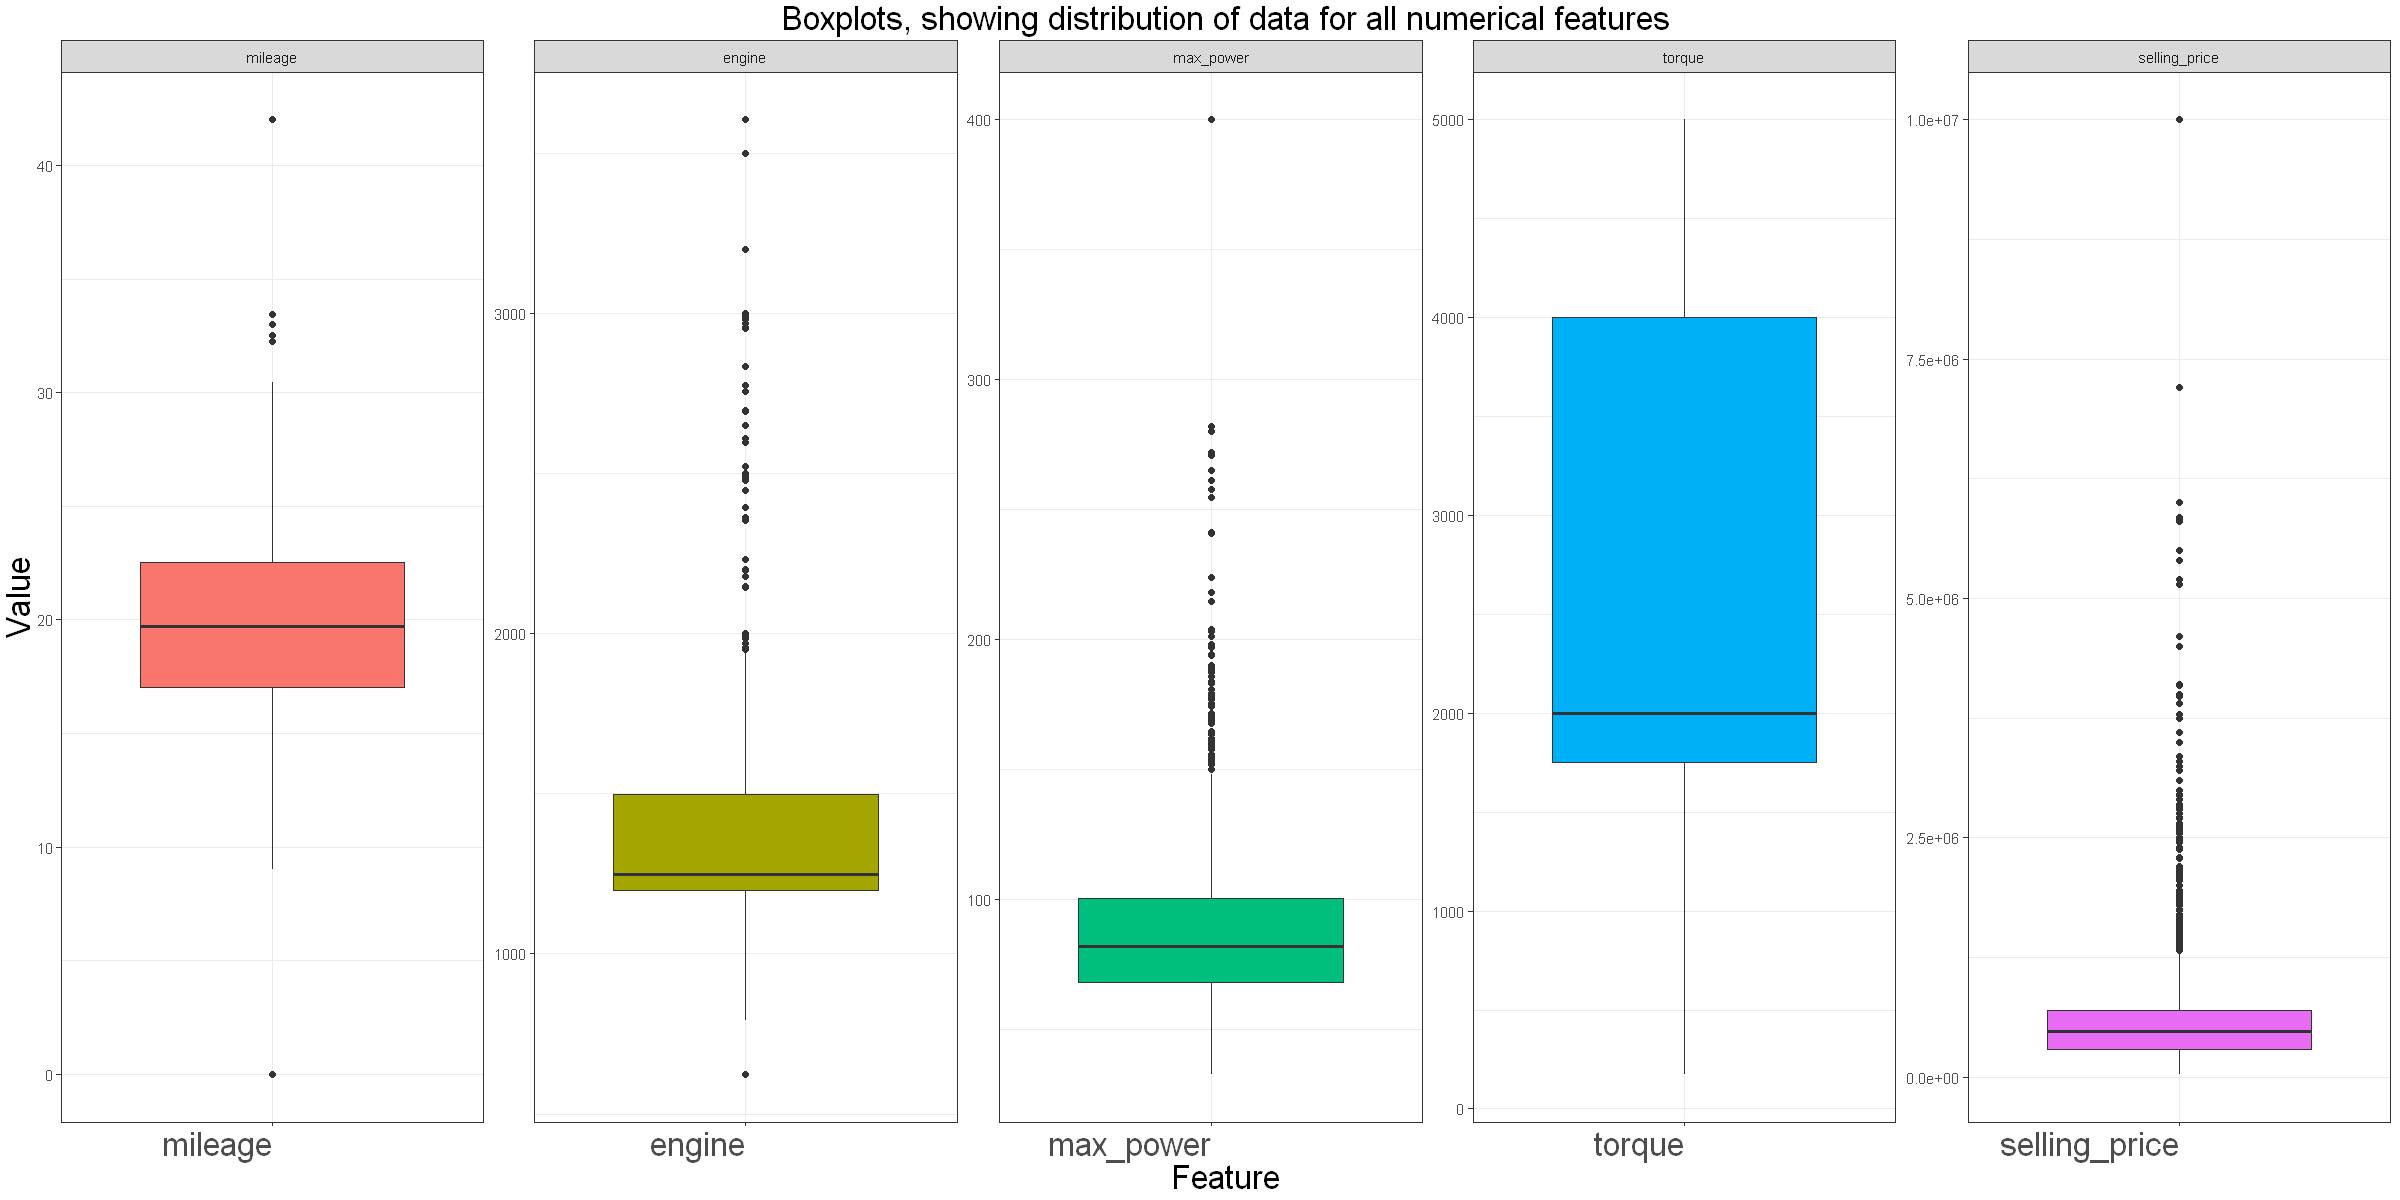

In [18]:
options(repr.plot.width = 20, repr.plot.height = 10)

ggplot(cont_melt, aes(x=variable, y=value, fill=variable)) + 
  geom_boxplot(alpha=1) + ylab("Value") + xlab("Feature" ) +
  theme_bw() + 
  ggtitle("Boxplots, showing distribution of data for all numerical features") + 
  theme(legend.position="none", 
        axis.text.x = element_text(hjust = 1, size = 20),
        plot.title = element_text(hjust = 0.5, size = 20),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20)) +
        facet_wrap(~variable, nrow = 1, scales = "free")


The plot above shows that the range for mileage, engine, max_power, and selling_price is very wide. There's also a huge outlier on those columns so that need to be dealed with. Only torque columns looks fine. The outlier is interfereing with the boxplot analysis so those must be dealt with

For used car prices, it is expected that some car will have overpriced prices and higher value of the predictor due to different car being sold. To deal with the outlier, the IQR method will be used to set up boundaries which calculated from 1.5 times the IQR and then subtract this value from Q1 and add this value to Q3. This gives us the minimum and maximum of the boundaries. Any observation above and below the boundaries is considered outliers.

In [19]:
#Checking the Q1 and Q3 of the columns
summary(dataset_cont)

    mileage          engine       max_power          torque    
 Min.   : 0.00   Min.   : 624   Min.   : 32.80   Min.   : 175  
 1st Qu.:17.01   1st Qu.:1197   1st Qu.: 68.05   1st Qu.:1750  
 Median :19.70   Median :1248   Median : 82.00   Median :2000  
 Mean   :19.74   Mean   :1430   Mean   : 91.40   Mean   :2717  
 3rd Qu.:22.54   3rd Qu.:1498   3rd Qu.:100.60   3rd Qu.:4000  
 Max.   :42.00   Max.   :3604   Max.   :400.00   Max.   :5000  
 selling_price     
 Min.   :   29999  
 1st Qu.:  290000  
 Median :  480000  
 Mean   :  663846  
 3rd Qu.:  700000  
 Max.   :10000000  

In [20]:
#Calculating the IQR for the columns we'll dealt with
print(paste("IQR for mileage column: ", IQR(dataset_cont$mileage)))
print(paste("IQR for engine column: ", IQR(dataset_cont$engine)))
print(paste("IQR for max_power column: ", IQR(dataset_cont$max_power) ))
print(paste("IQR for selling_price column: ", IQR(dataset_cont$selling_price)))

[1] "IQR for mileage column:  5.53"
[1] "IQR for engine column:  301"
[1] "IQR for max_power column:  32.55"
[1] "IQR for selling_price column:  410000"


Upper Boundary = Q3 + IQR

Lower Boundary = Q1 - IQR

In [21]:
#Dealing with the outlier using the IQR method to determine the upper and lower boundary
dataset_cont <- dataset_cont %>%
  filter(selling_price <= 1000000, mileage > 13, mileage <27, max_power <= 125, engine <= 1800,)

Now that we have dealt with the outliers, let's replot the boxplot once more and this time include the distribution of the variables in the boxplot

No id variables; using all as measure variables



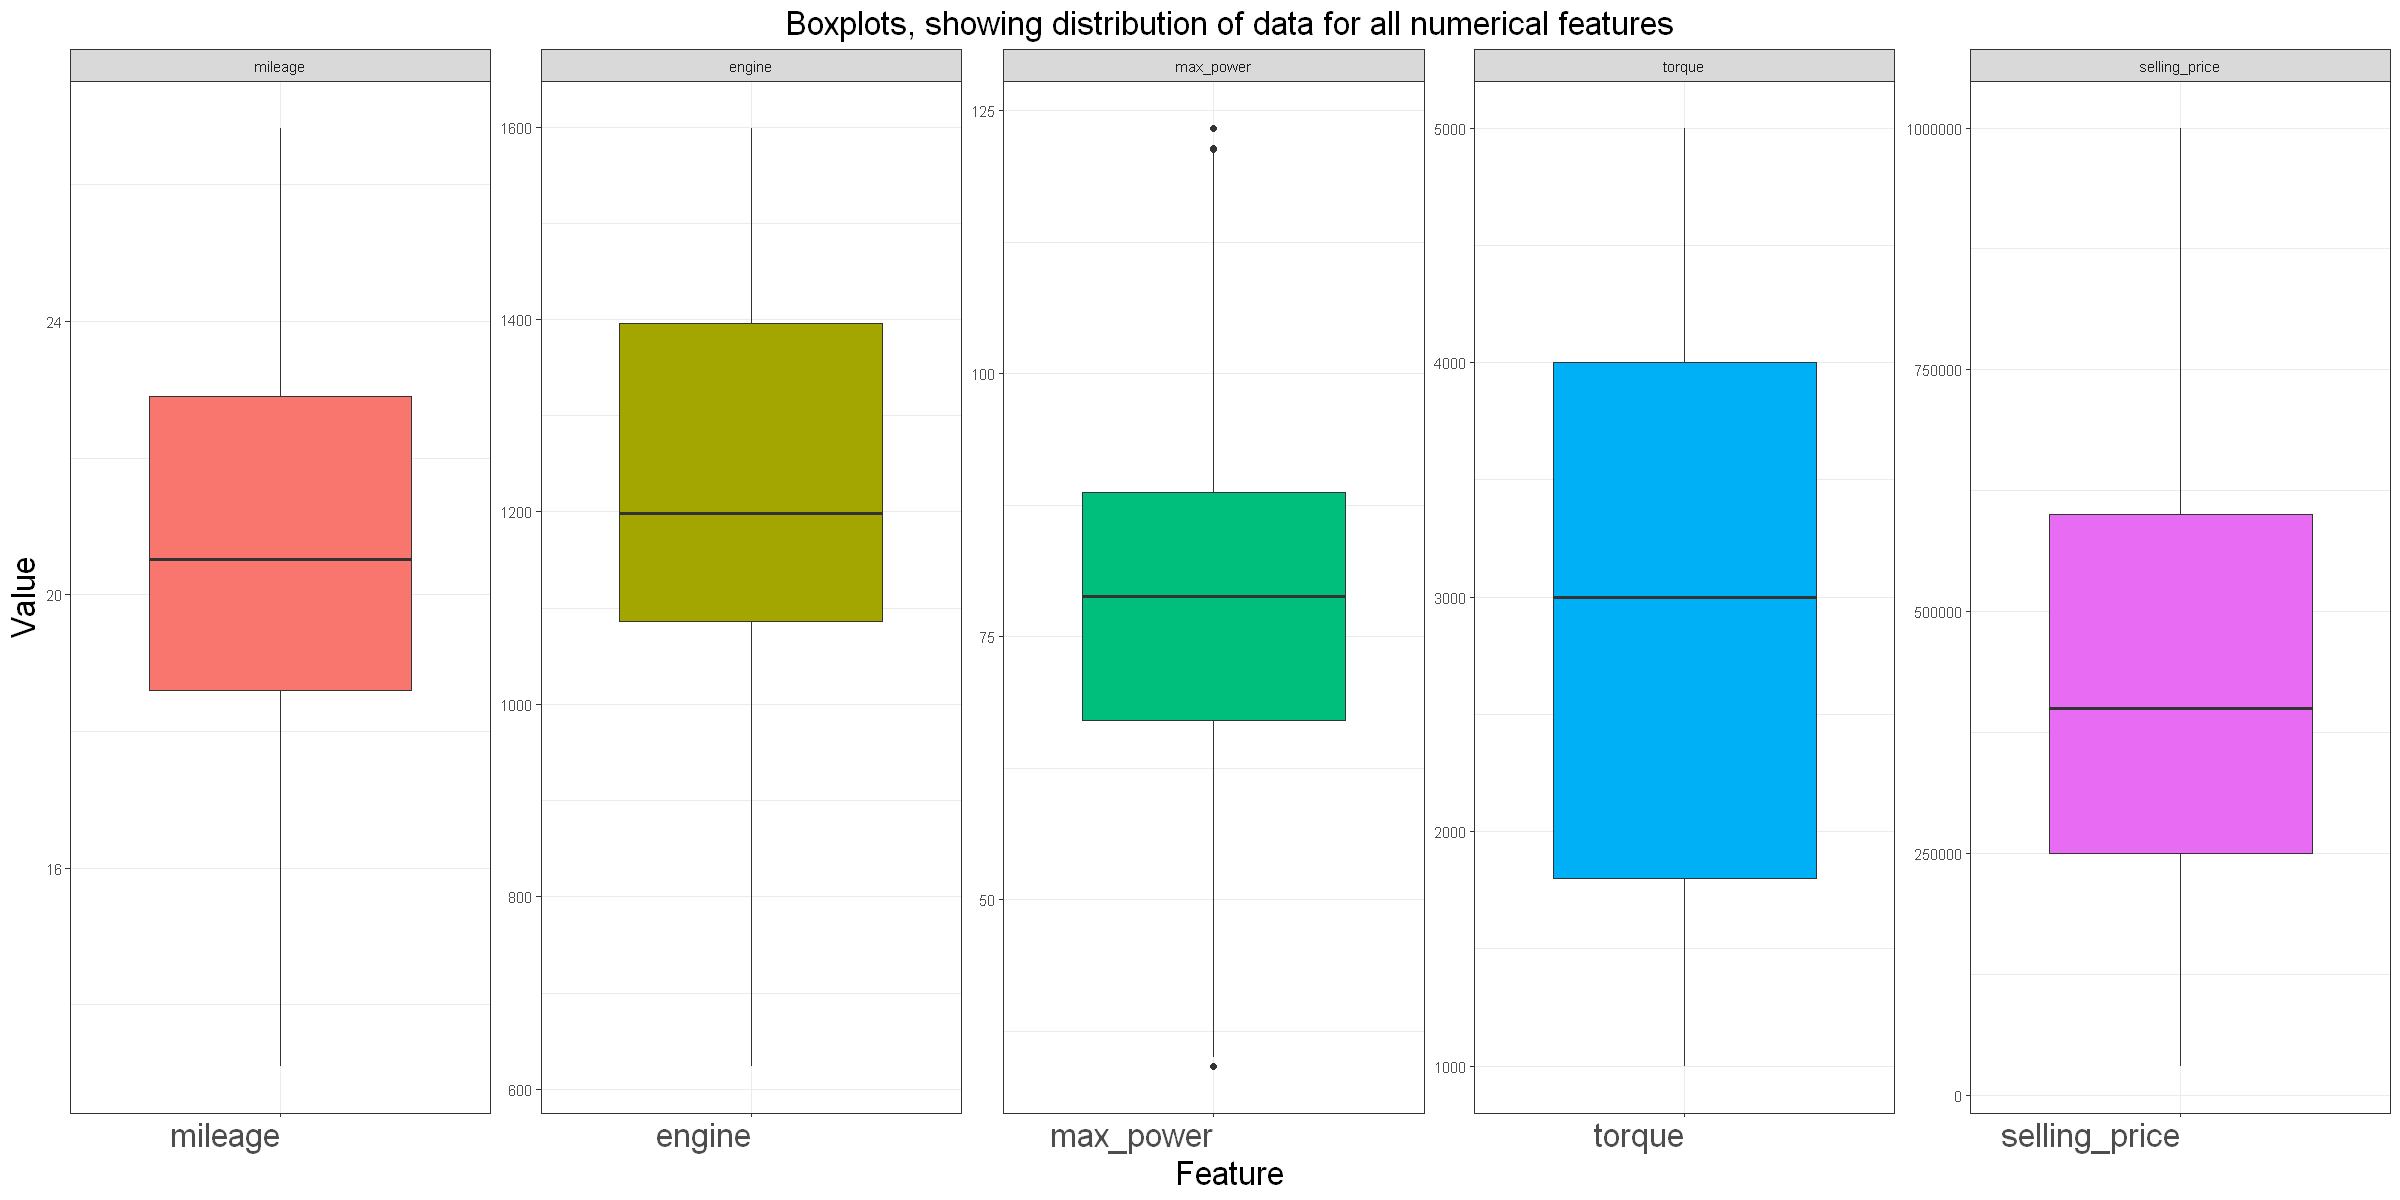

In [22]:
options(repr.plot.width = 20, repr.plot.height = 10)
cont_melt = melt(dataset_cont, variable_name = "Feature")

ggplot(cont_melt, aes(x=variable, y=value, fill=variable)) + 
  geom_boxplot(alpha=1) + ylab("Value") + xlab("Feature" ) +
  theme_bw() + 
  ggtitle("Boxplots, showing distribution of data for all numerical features") + 
  theme(legend.position="none", 
        axis.text.x = element_text(hjust = 1, size = 20),
        plot.title = element_text(hjust = 0.5, size = 20),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20)) +
        facet_wrap(~variable, nrow = 1, scales = "free")

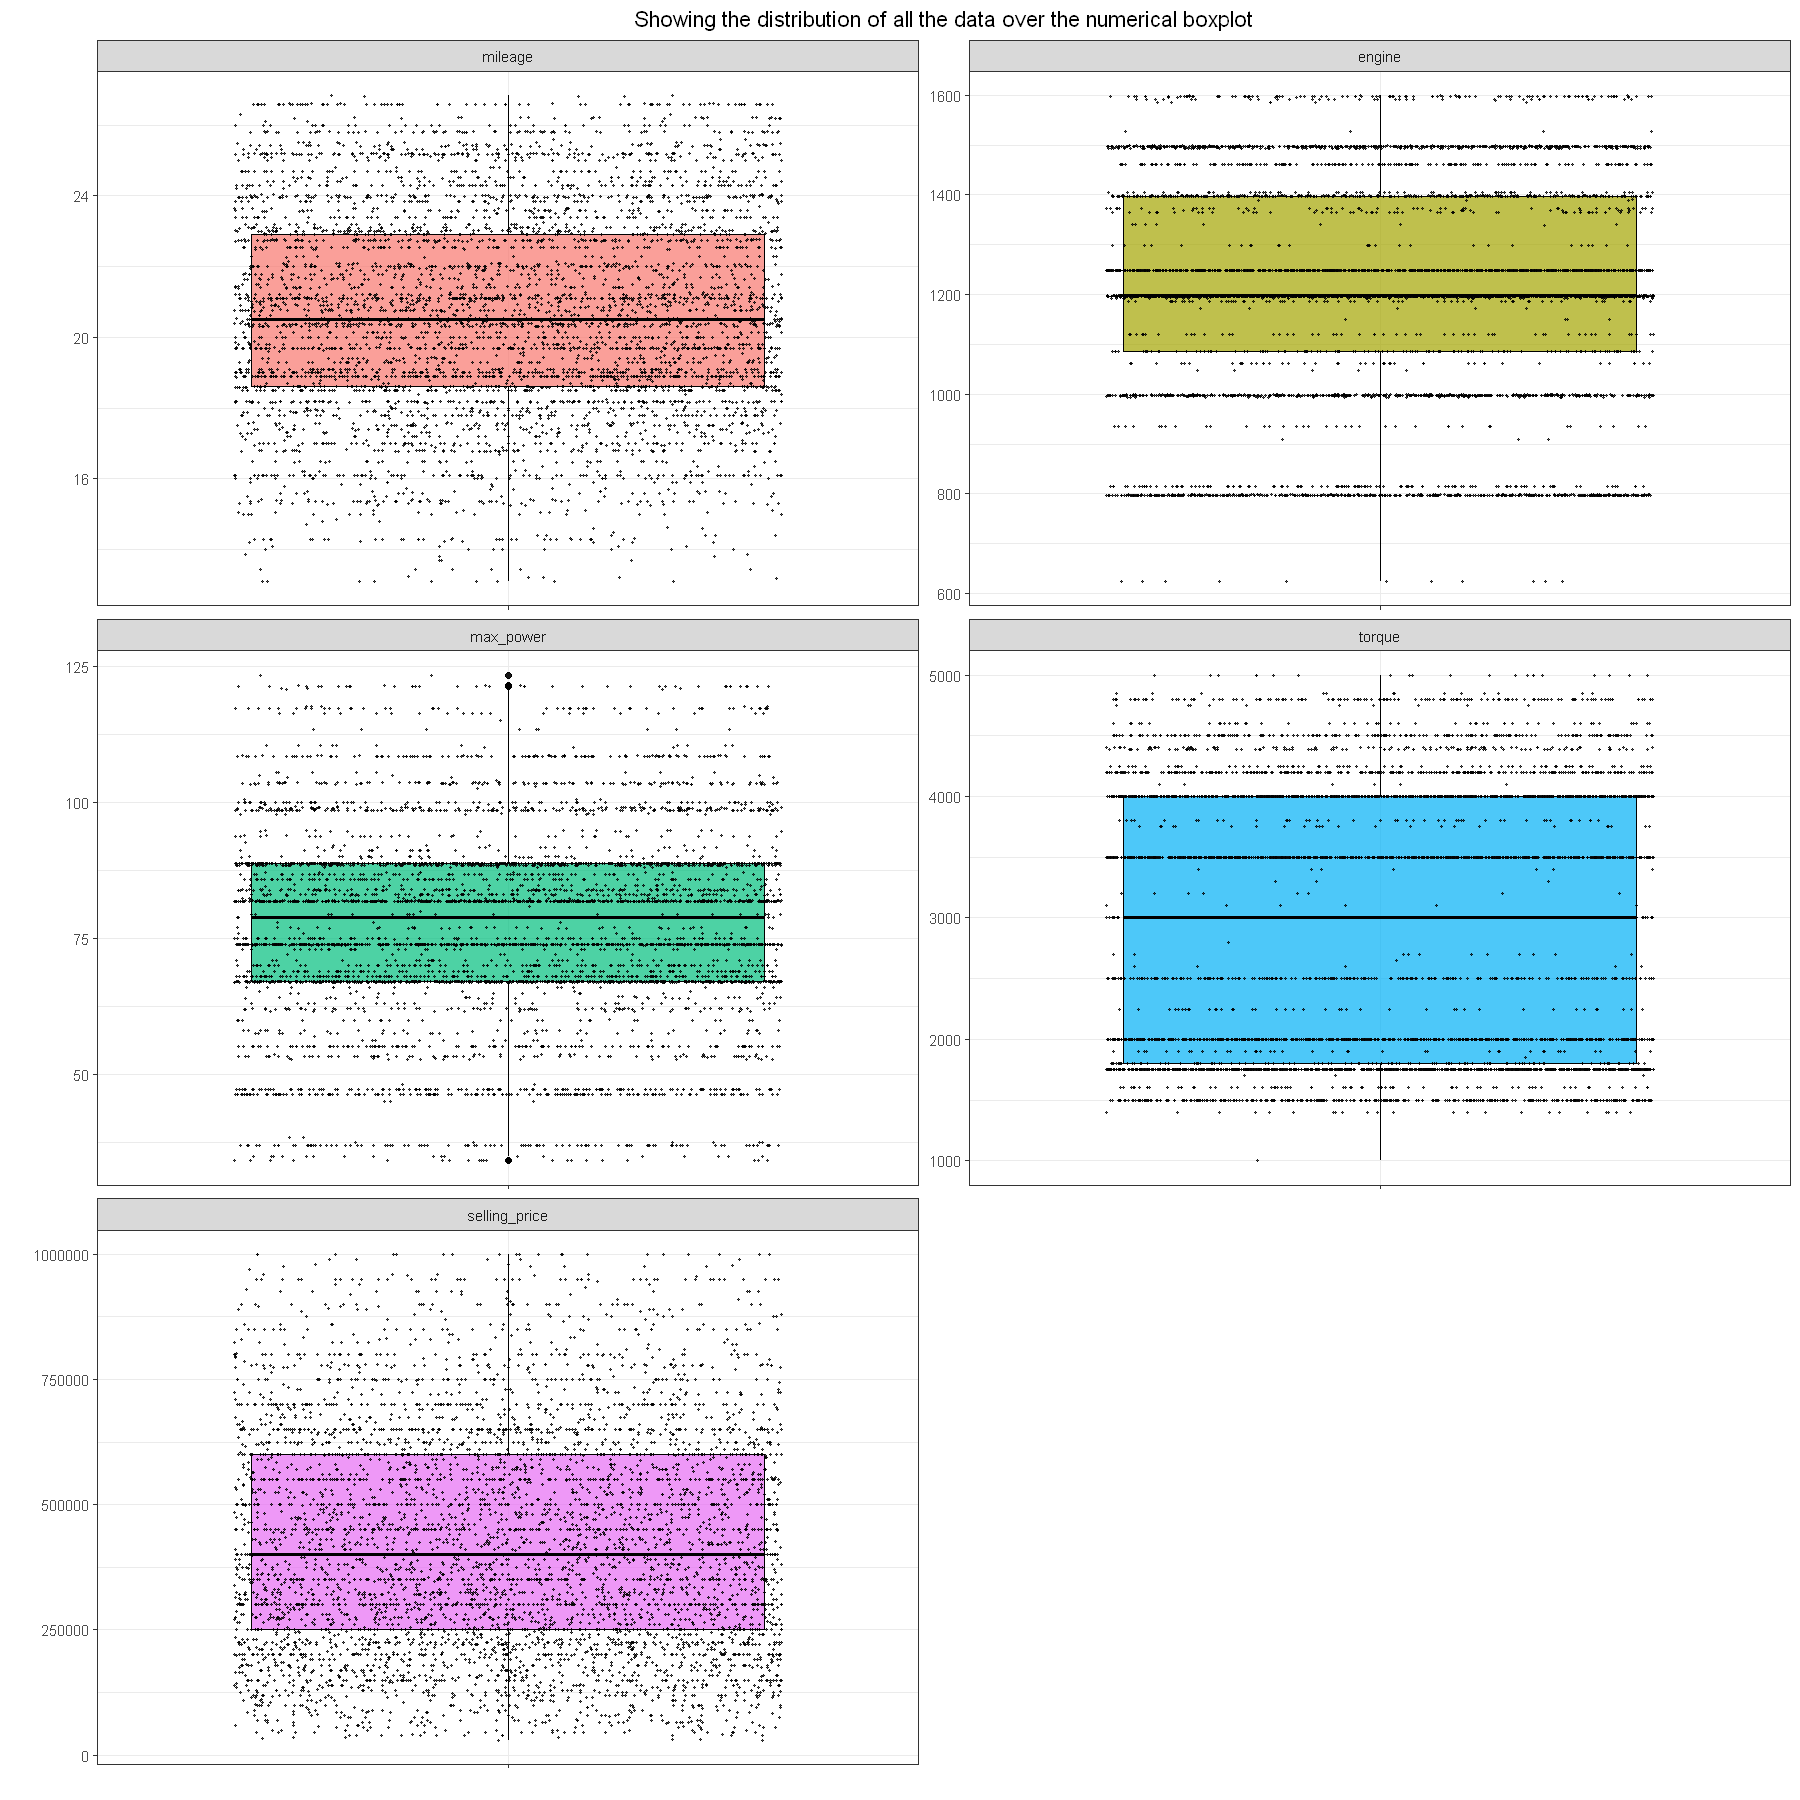

In [23]:
#Setting the width and height of the plot
options(repr.plot.width = 15, repr.plot.height = 15)

#Using the ggplot for to plot the distribution over the boxplot
ggplot(cont_melt, aes(x=variable, y=value)) + 
geom_boxplot(alpha=0.7, color="black", aes(fill=variable)) + 
geom_jitter(color="black", size=0.4, alpha=0.7) +
facet_wrap(~variable, nrow=3, scales = "free") + 
labs(x="", y="", fill='variable') + 
ggtitle("Showing the distribution of all the data over the numerical boxplot") + 
theme_bw() + 
theme(legend.position="none", plot.title = element_text(hjust = 0.5), axis.text.x=element_blank())

From the boxplot after we dealt with the outliers, some observations can be made which is

- After we dealt with the outlier, most of the column didn't show any outlier except max_power but it's only a small amount near the Q1 and Q3 therefore it's left there
- The median looks like to be in the middle column for all the attributes
- Both the upper and lower whisker looks to be equal in length for all attributes except for selling price in which the upper whisker looks longer. It will be analysed more properly later to check for skewness
- The distribution for the selling price, mileage, and max power looks uniform across all range of the data
- Meanwhile the distribution for engine and torque looks concentrated to certain points of the data

The main dataset is also wrangled like the continuous dataset

In [24]:
#Filtering the main dataset according to what have been done to the continuous variable
dataset <- dataset %>% 
  filter(selling_price <= 1000000, mileage > 13, mileage <27, max_power <= 125, engine <= 1800,)

## Histogram

Continuing after boxplot. Histogram is used to visualize the distribution of the data. GGplot is used again to visualize the histogram

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


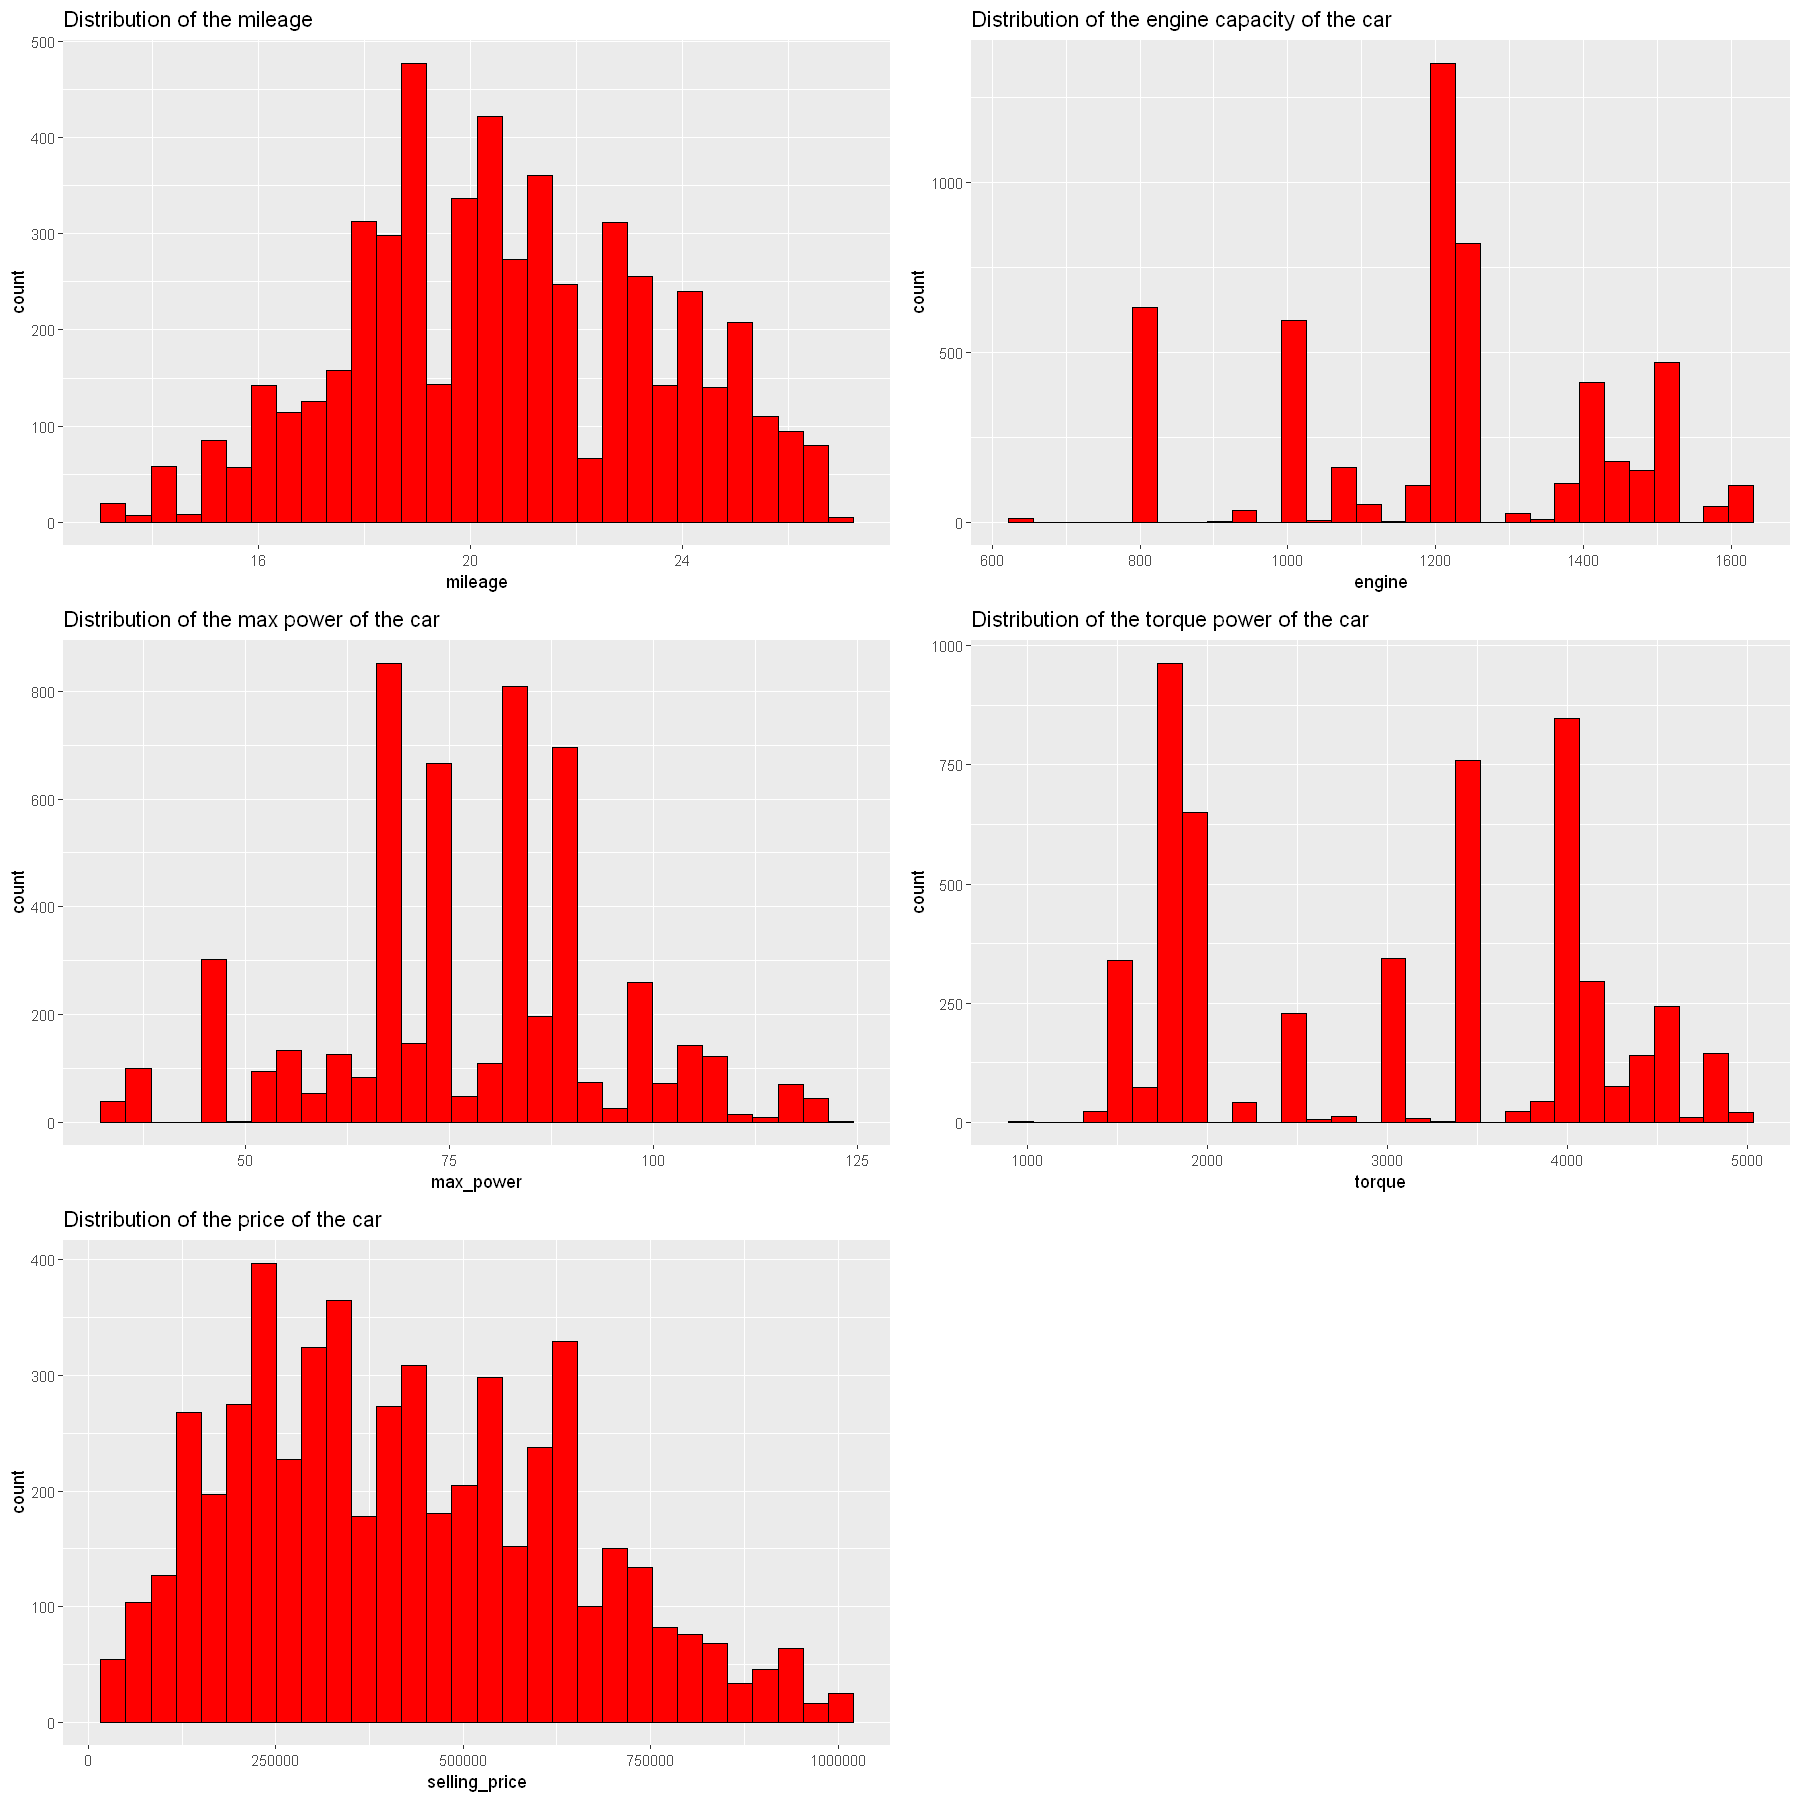

In [25]:
options(repr.plot.width = 15, repr.plot.height = 15)
#Making histogram for mileage
p1<-ggplot(aes(x=mileage), data = dataset_cont) +
    geom_histogram(color = I('black'), fill = "red") +
    ggtitle('Distribution of the mileage')

#Making histogram for engine
p2<-ggplot(aes(x=engine), data = dataset_cont) +
    geom_histogram(color = I('black'), fill = "red") +
    ggtitle('Distribution of the engine capacity of the car')

#Making histogram for max power
p3<-ggplot(aes(x=max_power), data = dataset_cont) +
    geom_histogram(color = I('black'), fill = "red") +
    ggtitle('Distribution of the max power of the car')

#Making histogram for torque
p4<-ggplot(aes(x=torque), data = dataset_cont) +
    geom_histogram(color = I('black'), fill = "red") +
    ggtitle('Distribution of the torque power of the car')

#Making histogram for selling price
p5<-ggplot(aes(x=selling_price), data = dataset_cont) +
    geom_histogram(color = I('black'), fill = "red") +
    ggtitle('Distribution of the price of the car')
# plot all 4, 2 x 2

grid.arrange(p1, p2, p3, p4, p5, ncol = 2)

From the histogram, several observation can be made

- The mileage looks to have a normal distribution
- The selling price, the target variable looks to be a bit skewed to the right
- The rest of the attributes, power, torque, and engine doesn't looks to have a distribution
- Power, torque, and engine also has a gap in the values. This happens because even though those three has a numerical values. There's some values that are skipped
- Looks like for the engine, power, and torque, they have a value that have more count than the rest

Skewness and kurtossis check is done for the target variable to see if more normalization technique is needed

In [26]:
#Checking the skewness and kurtossis of the price using the e1701 library

print("Skewness is: ")
round(skewness(dataset_cont$selling_price),4)
print("Kurtosis is: ")
round(kurtosis(dataset_cont$selling_price),4)

[1] "Skewness is: "


[1] 0.3938

[1] "Kurtosis is: "


[1] -0.5976

From the skewness and kurtosis function, we can see that the value is between -1 to +1 which indicates a good value therefore no more normalization technique is needed.

## QQ Plot

Next up, we plot the QQ plot for all continuous variable to see whether or not the dataset follows the normal distribution

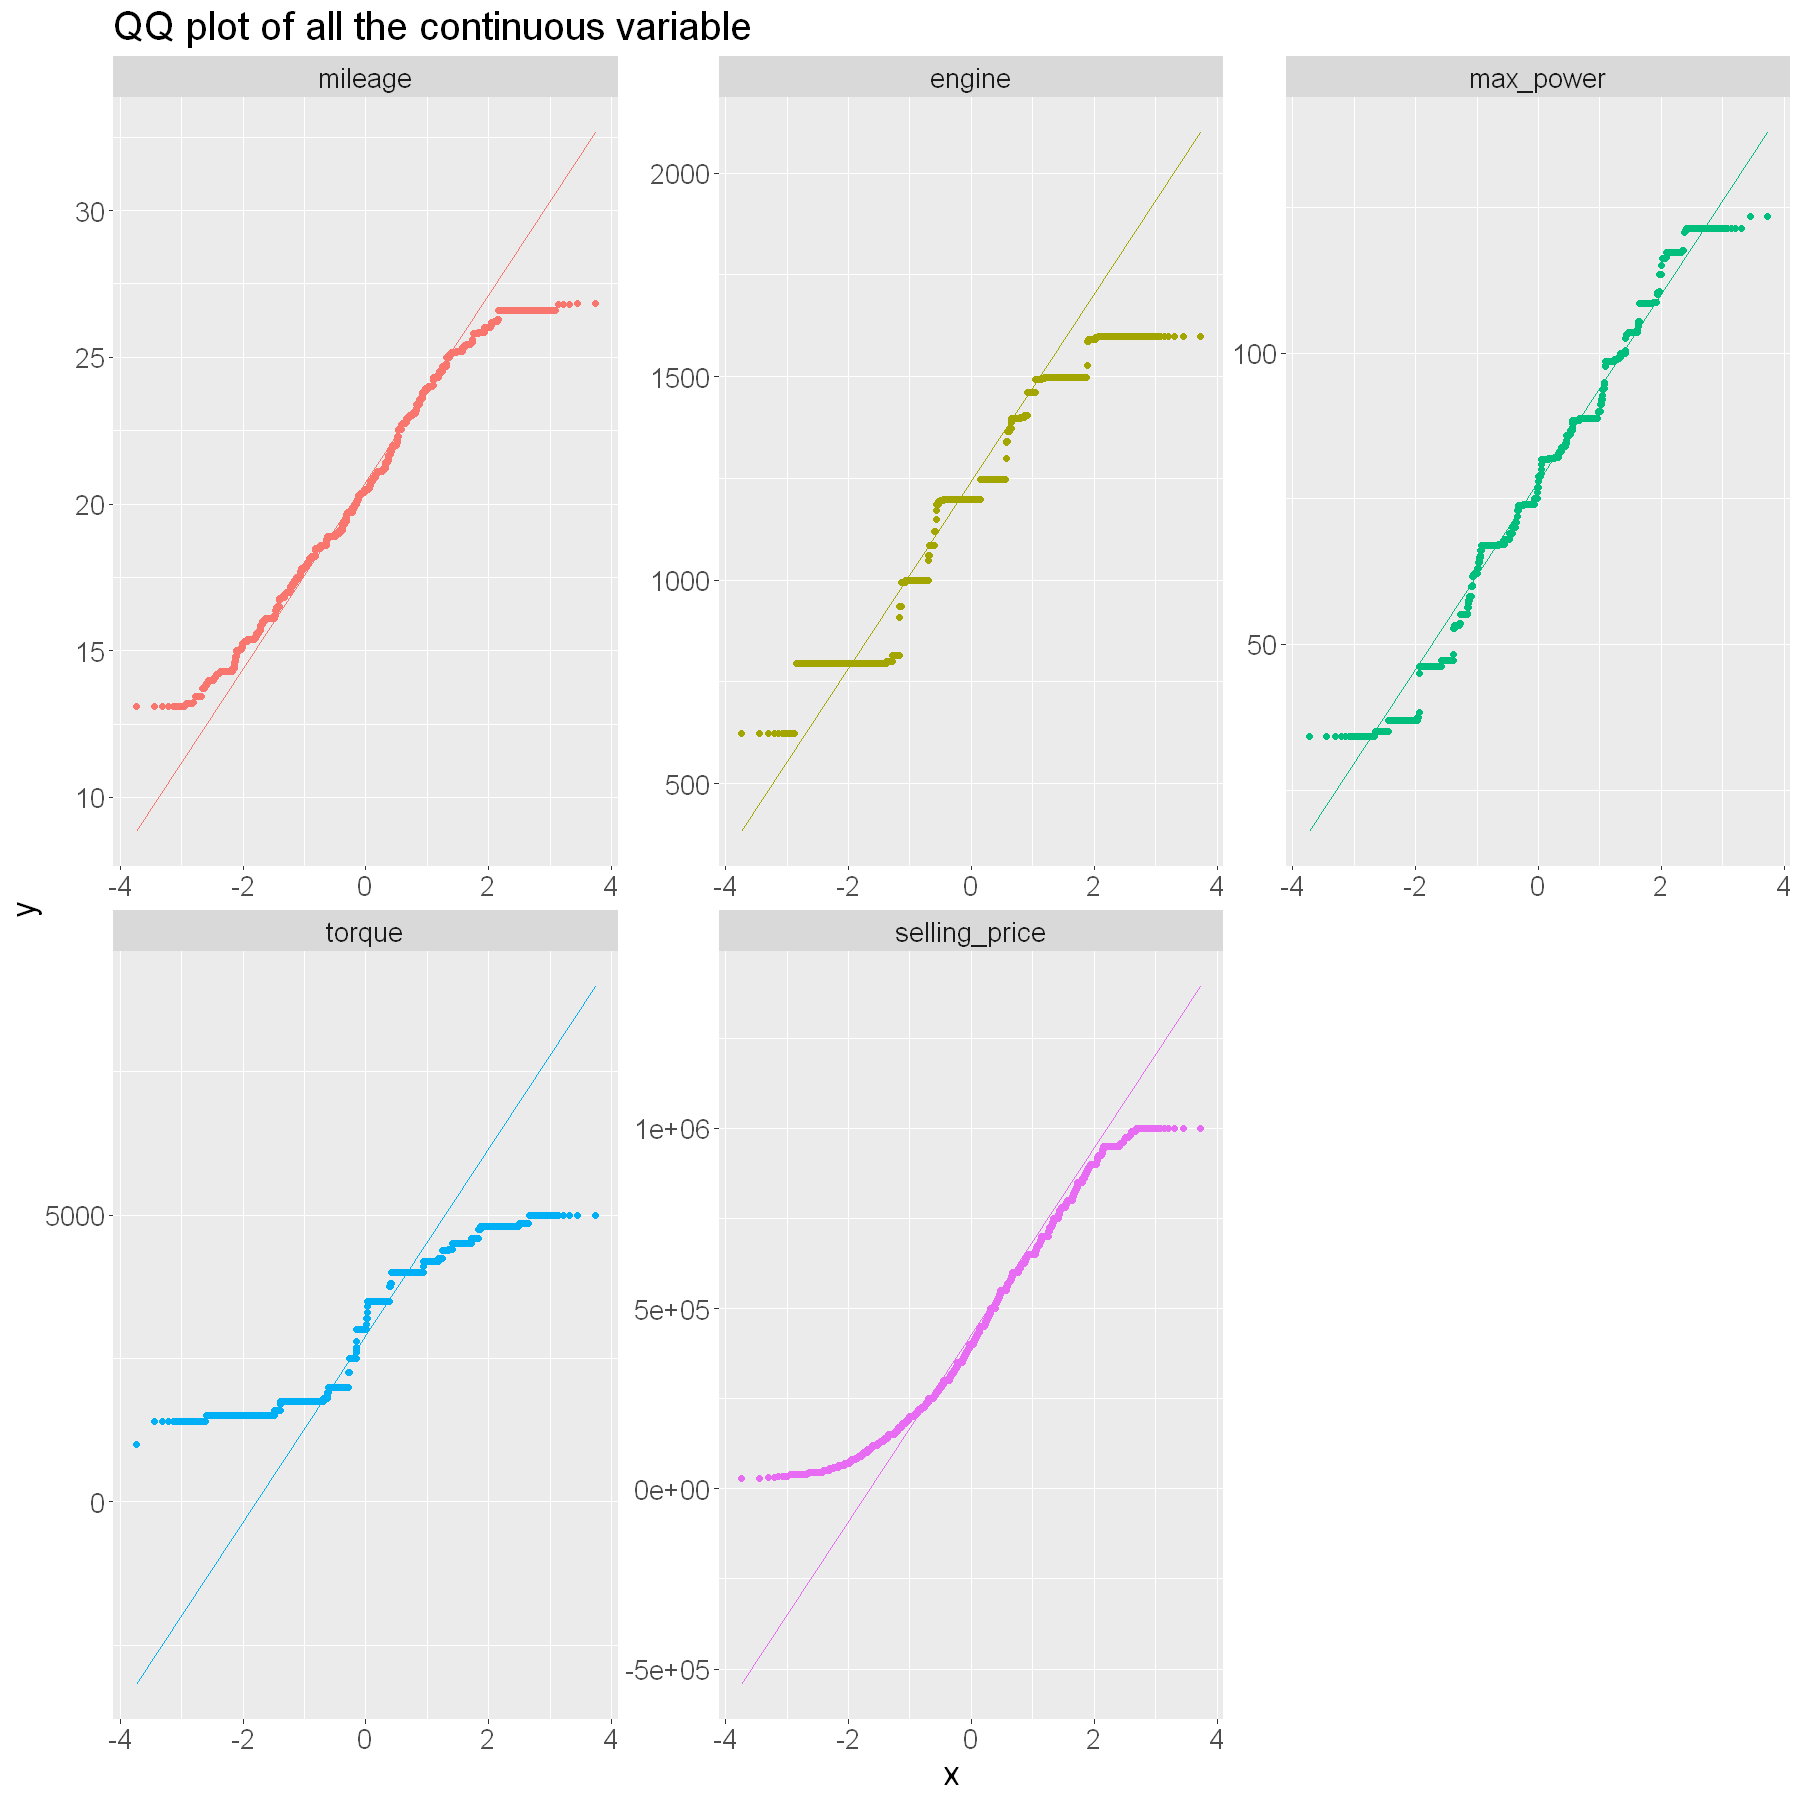

In [27]:
#Using ggplot to plot the QQ plot

qq <- ggplot(cont_melt, aes(sample = value, color= variable)) +
    geom_qq() +
    stat_qq() +
    stat_qq_line() +
    facet_wrap(~ variable, nrow = 2, scales = "free") +
    guides(color = 'none') +
    ggtitle("QQ plot of all the continuous variable") + 
    theme(text = element_text(size = 20))

qq

From the QQ plot we can make some observations such as

- As seen from the histogram, the engine, power, and torque has a gap in the values
- Selling price looks like a normal distribution although it looks to be light tailed
- The mileage plot looks like a normal distribution although it looks to be light tailed
- The torque plot looks to be heavy tailed
- Even though the engine and power plot has a gap in values, from the looks of it, it looks like a normal distribution


## Correlation 

For checking the correlation, we'll make a scatterplot matrix using pairs() then check the correlation coefficient between all the continuous variables using cor()

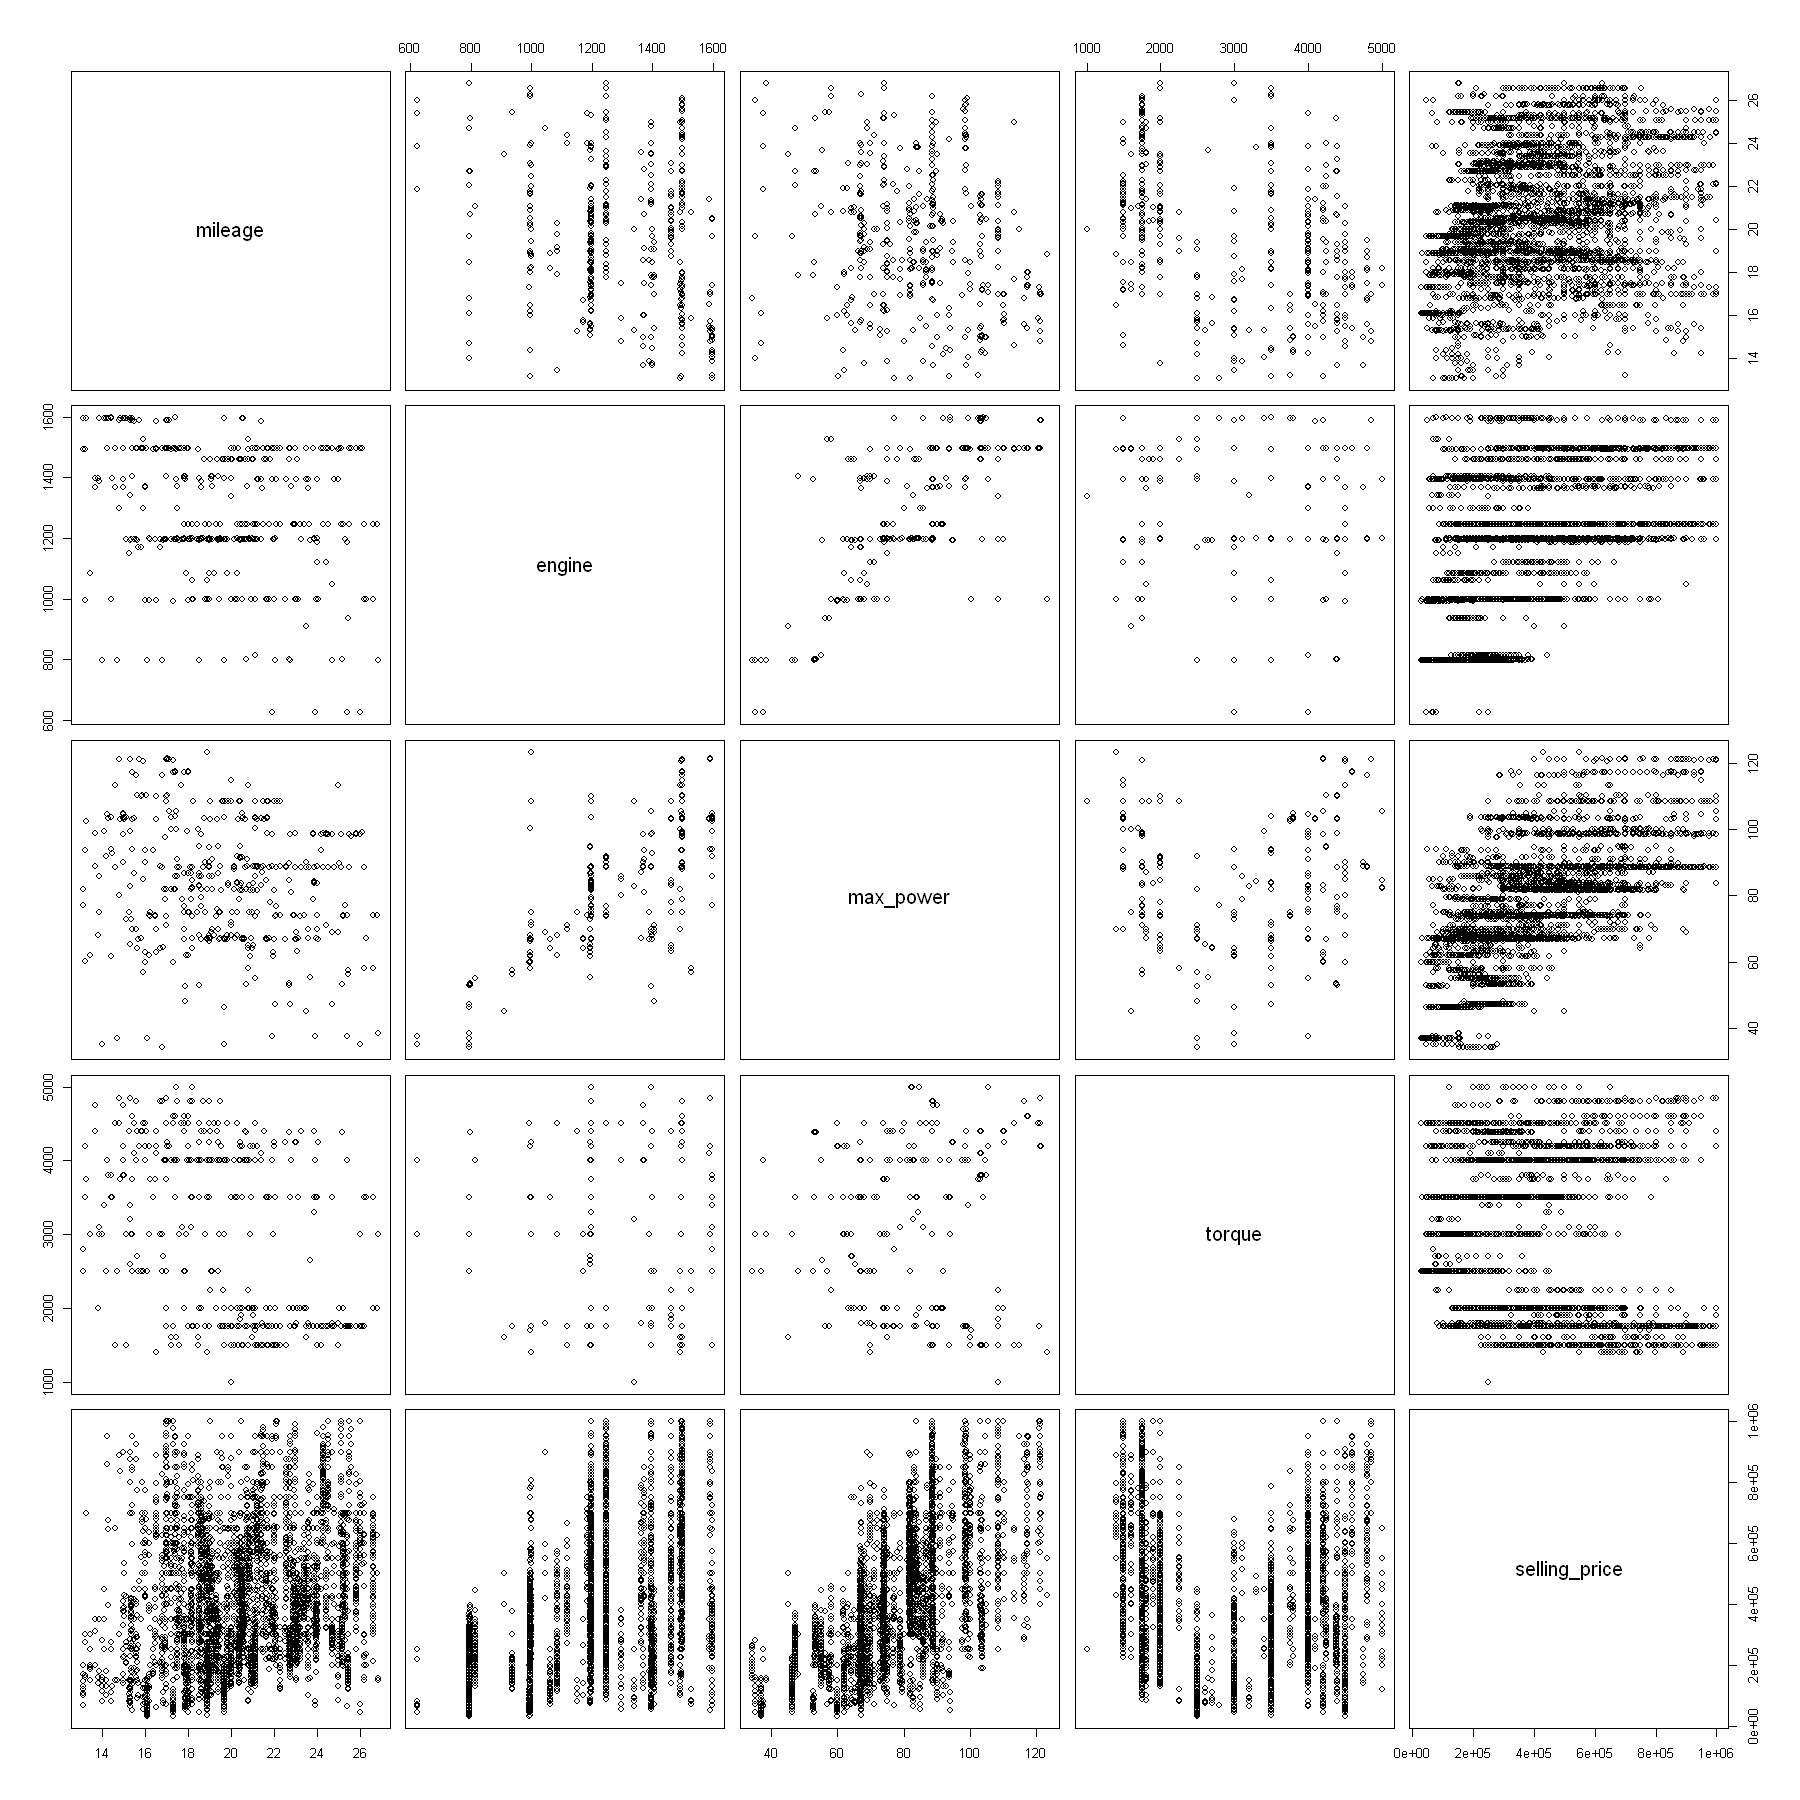

In [28]:
#Making the scatterplot matrix
pairs(dataset_cont)

In [29]:
#Making the correlation coefficient for all variables
round(cor(dataset_cont[1:5]),3)

,mileage,engine,max_power,torque,selling_price
mileage,1.000,-0.077,-0.090,-0.371,0.188
engine,-0.077,1.000,0.824,-0.366,0.504
max_power,-0.090,0.824,1.000,-0.108,0.663
torque,-0.371,-0.366,-0.108,1.000,-0.141
selling_price,0.188,0.504,0.663,-0.141,1.000


From the scatterplot matrix looks like all variables doesn't have any connection which each other except the max_power and engine which looks like it has a linear relationship although the plot is not really clear. For better analysis, we take a look at the correlation coefficient between all variables. From here, the variables that have higher than 0.7 correlation value means that it has a high correlation.

From the correlation coefficient, we can see that indeed, max power and engine does have a high correlation value which is 0.824. This makes sense since the higher the engine capacity is usually the higher the max power. There's situation that engine with lower CC have higher max power so it's not deterministic. It is decided that whether or not one of engine/max_power is deleted is seen from the correlation analysis. Now it is found that both of them have a correlation of 0.8 which is more than 0.7, which means very high. Therefore one of them must be deleted, it is decided that engine which is the CC of the engine is kept based from the sgcarmart article.

Other variables have lower than 0.4 correlation so we can safely use them for predictor towards the selling price.

Deleting the max power column on the main dataset

In [30]:
#Deleting the max_power column
dataset <- subset(dataset, select = -c(max_power))

# Conclusion from EDA for continuous variable

- Deleting the outlier from all the column except torque using the upper and lower boundary from IQR method
- Confirming that the target variable (selling price) even though it looks like it has a right skew, from the skewness and kurtossis analysis, it's value is between -1 to +1 therefore it has a good value
- Discovering that max power and engine capacity does have correlation which each other. This means that both of them could interfere with the prediction for the price. It is decided that the max power column is deleted
- From the boxplot we can see that all value has a good range of boxplot
- From the qq plot and histogram we can see that torque, power, and engine has a gap in the values
- From the distribution box plot, we can see that for mileage and price the data is distributed evenly
- Meanwhile from distribution boxplot, the torque power and engine is not distributed evenly as also confirmed from the qqplot and histogram

# CATEGORICAL EDA

AFter finishing with the continuous variable EDA, we continue with the EDA for categorical variables. First we pivot the dataset to long format using the pivot_longer() function

In [31]:
#Filtering the dataset according what have been done in continuous variables
dataset_cat <- dataset_cat %>%
  filter(selling_price <= 1000000)

#Pivoting the dataset to longer format
cat_pivot <- dataset_cat %>%
    pivot_longer(cols = c('fuel', 'seller_type', 'transmission', 'owner', 'seats'), names_to = 'category', values_to = 'value')

head(cat_pivot)

selling_price,category,value
<dbl>,<chr>,<fct>
450000,fuel,Diesel
450000,seller_type,Individual
450000,transmission,Manual
450000,owner,First Owner
450000,seats,5
370000,fuel,Diesel


Next we used geom bar to count the how many each categorical variables value has

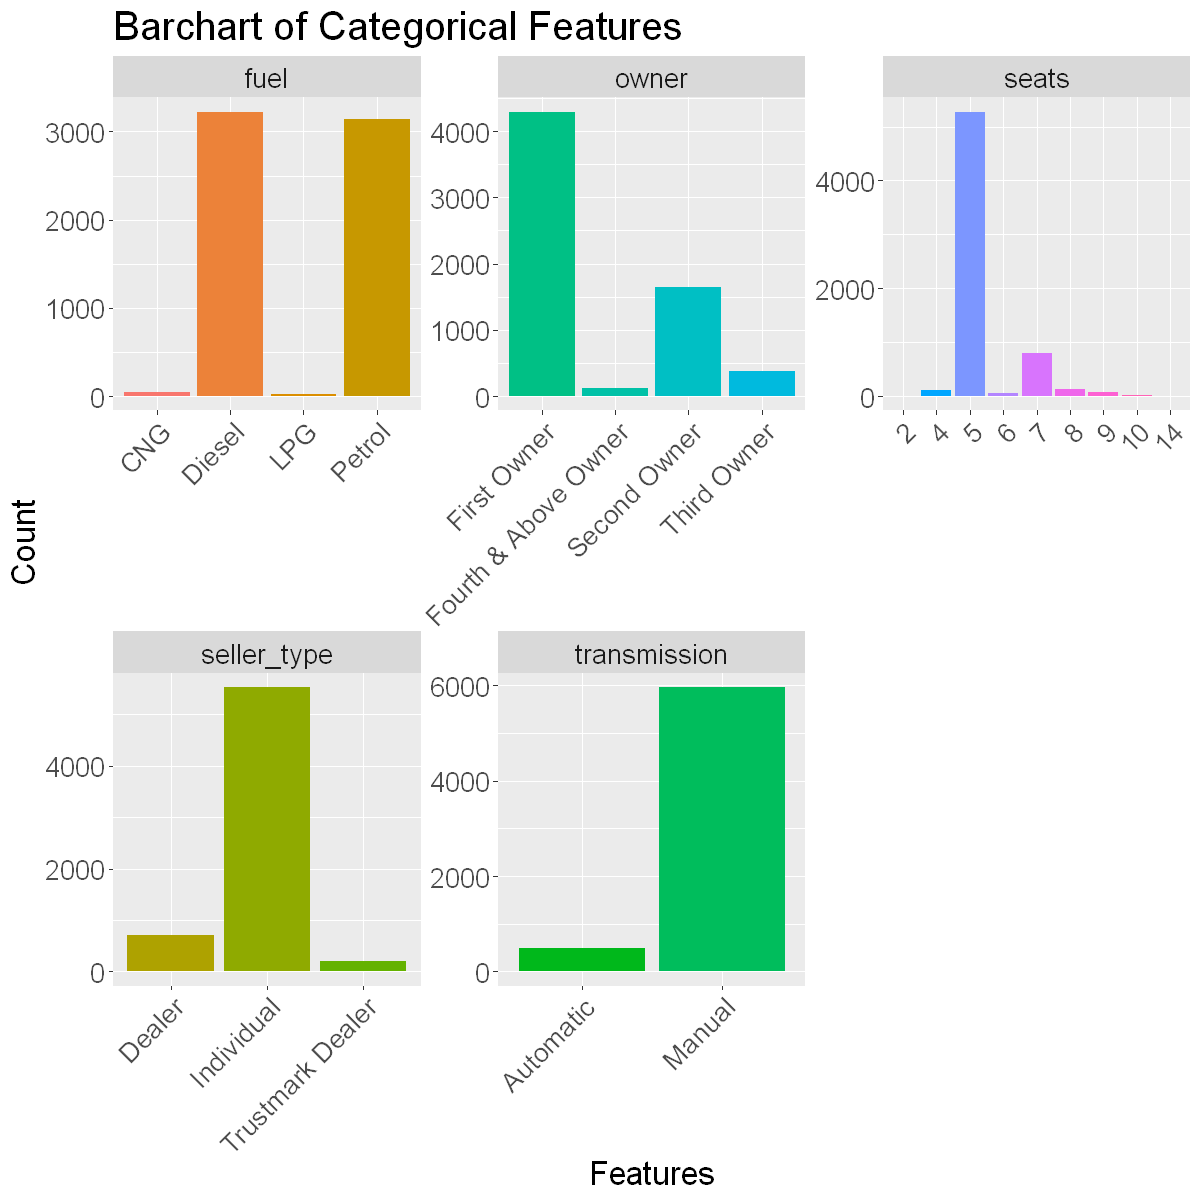

In [32]:
options(repr.plot.width = 10, repr.plot.height = 10)

#Plotting the barchart to count the categorical values
ggplot(cat_pivot, aes(x = value, fill = value)) +
    geom_bar() +
    facet_wrap(~category, scales = 'free') +
    guides(fill = 'none') +
    labs(x = 'Features') +
    labs(y = 'Count') +
    ggtitle('Barchart of Categorical Features')+
    theme(text = element_text(size = 20),
         axis.text.x = element_text(angle = 45, hjust = 1))

Observation

- For the fuel column, both diesel and petrol takes up most of the count while the count for cng and lpg is below 200 it looks like
- For the owner column, most of the seller is the first owner of the car. Interestingly enough, the count between third and fourth owner looks quite the same
- Most of the car sold have 5 seats. The second highest have 7 seat. The other seats number have a low count
- Most of the seller are from individual owner. Not a lot of the car being sold is from dealer
- Most of the car sold are manual cars

Next we'll do a boxplot of the categorical variables then plot the distribution over them

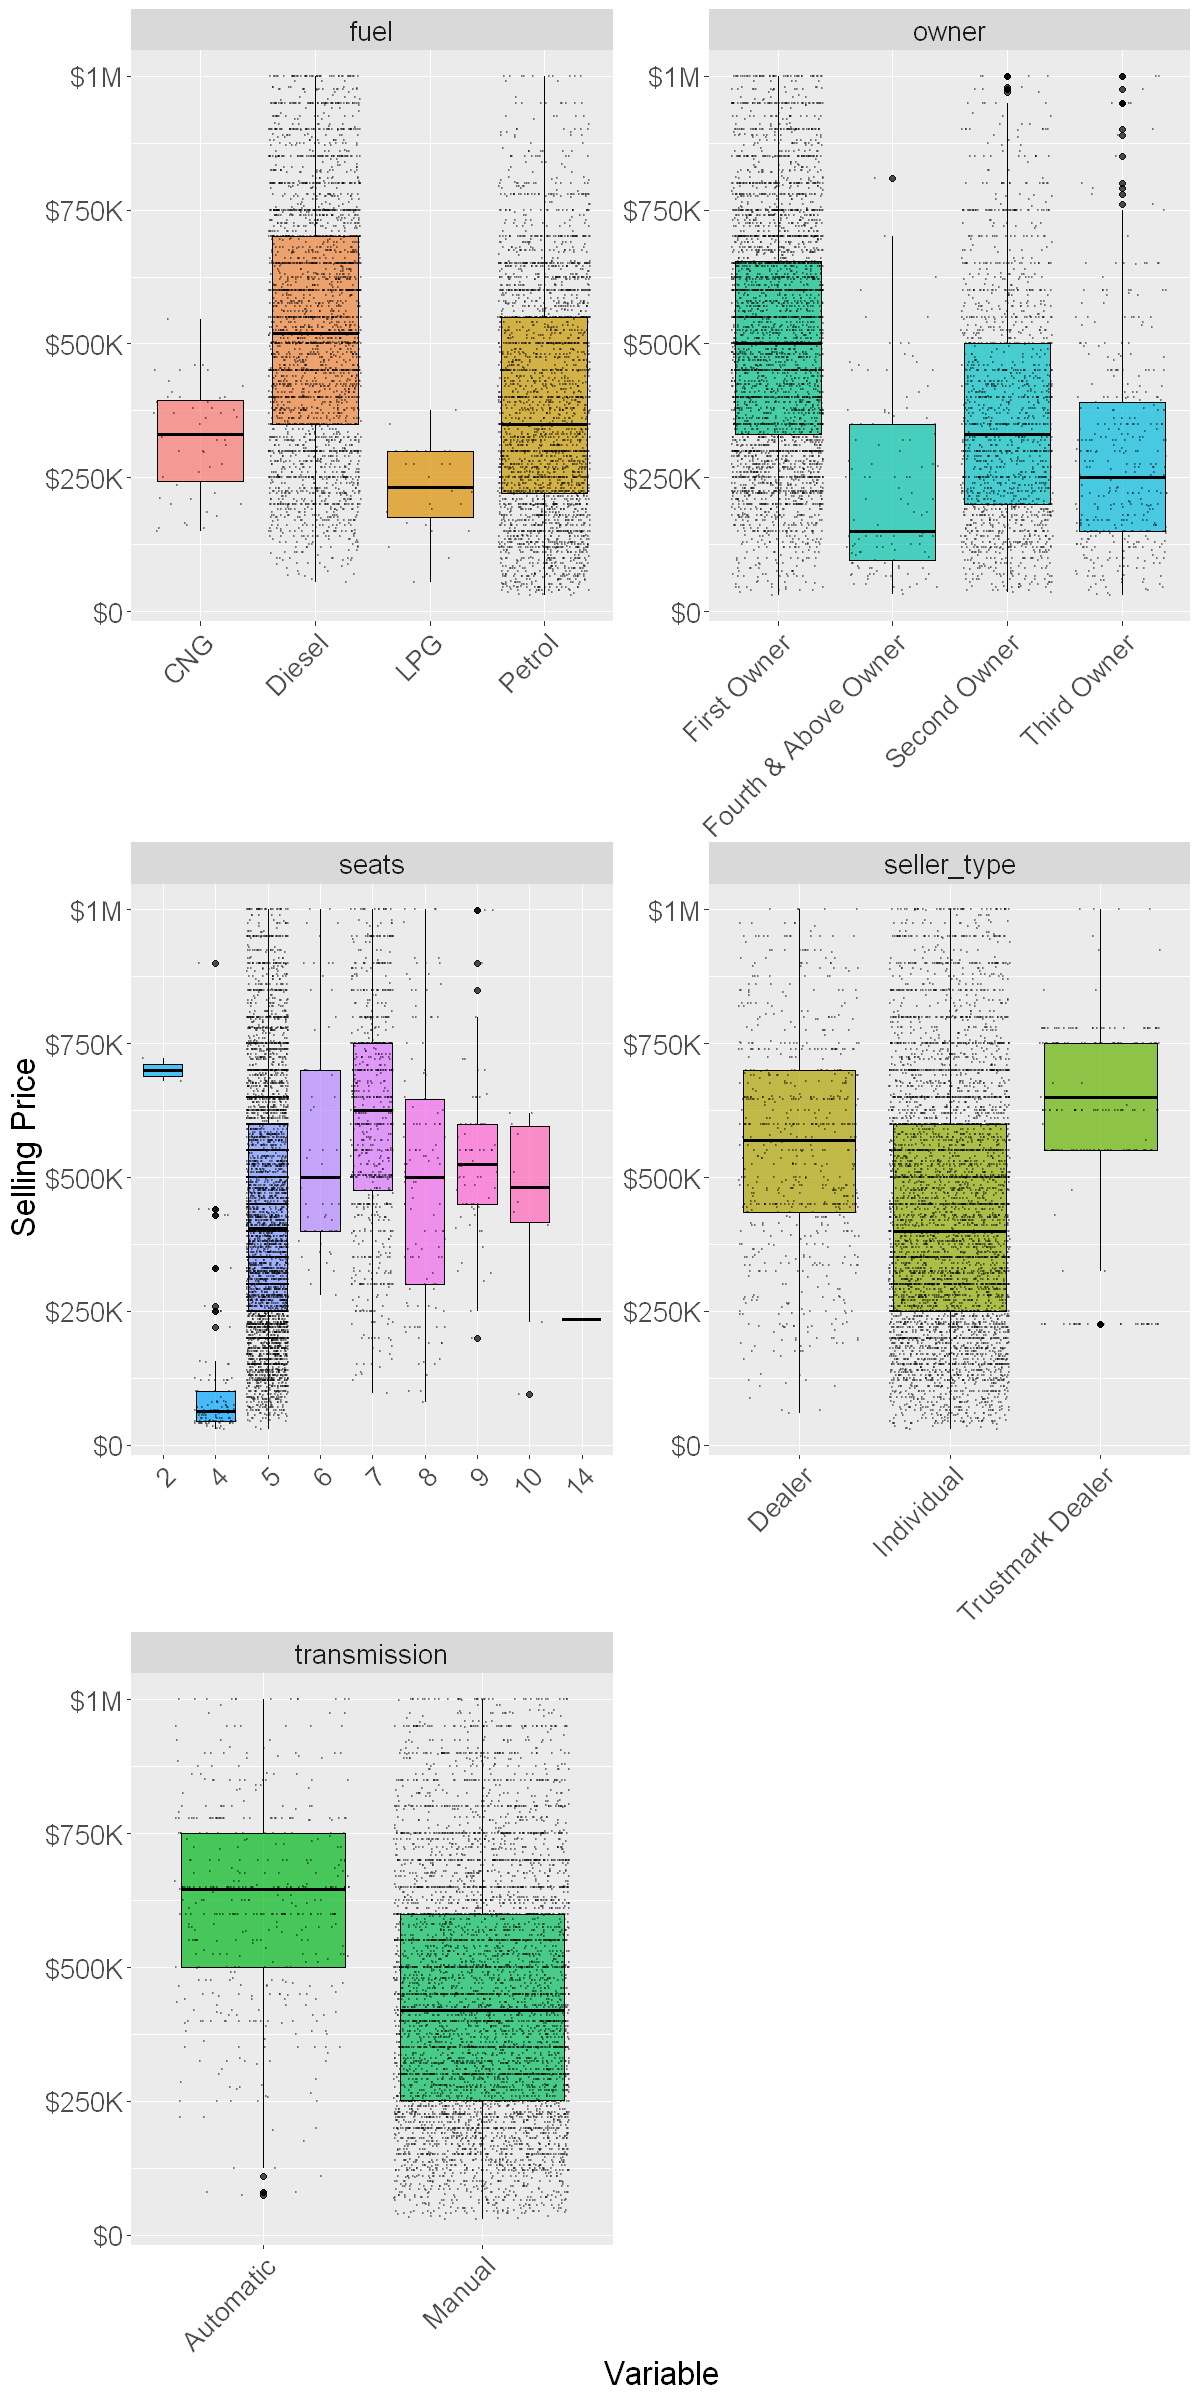

In [33]:
options(repr.plot.width = 10, repr.plot.height = 20)

#Plotting the boxplot with the distribution over it for all categorical variables
ggplot(cat_pivot, aes(x = value, y = selling_price, fill = value)) +
    geom_boxplot(alpha=0.7, color="black", aes(fill=value)) +
    geom_jitter(color="black", size=0.3, alpha=0.3) +
    facet_wrap(~category, nrow = 3, scales = 'free') +
    guides(fill = 'none') +
    scale_y_continuous(labels = label_dollar(scale_cut = cut_short_scale())) +
    labs(x = 'Variable') +
    labs(y = 'Selling Price') +
    theme(text = element_text(size = 20),
        axis.text.x = element_text(angle = 45, hjust = 1))

Observation 

- We can see that there's some outlier for owner, seats, seller type, and transmission
- Like the count observation, some of the values has higher data distribution than the rest like the manual compared to automatic transmission. And 5 seater compared to the rest.
- For the fuel variable, we can see that the median for all the values is quite similar although the cng and the lpg ones have smaller whisker indicating a smaller range. From here we can see that the data are concentrated in petrol and diesel which is supported by the distribution
- For the owner variable, we spy some outliers on second, third, and fourth beyond owner. The median for the three of them are also a lot more closer when compared to the first owner. Which make sense since the first owner has a lot more count (proved by the distribution) so its quartile range is wider
- For the seat variable, the 2, 4, and 14 seats stood out as outlier compared to the rest of the seats value. We can see that there's a lot more outlier on the 5th seat compared to the rest. For the distribution/count it's a lot more concentrated on the 5th and 7th seats which make sense since 5 or 7 seated cars are a lot more common. Considering that the count value for the 2, 4, and 14 seat is really low from the count graph and the range of the data is concentrated. It's expected that these three values will skew the prediction. Therefore it's decided to delete these three variable since seating is not considered an important variable.
- For the dealer variable. The data is a lot more concentrated on the individual dealer. The median and range of all three values are quite similar. There's outlier on the trustmark dealer
- For the transmission variable, we can see that the data is concentrated on the manual transmission. The range of the data is also wider compared to the automatic. Automatic transmission has some outliers

The dataset seat variable, 2,4 and 14 is deleted according to the observation

In [34]:
#Deleting the 2,4,14 variable from seat
dataset <- dataset[!(dataset$seats %in% c('2', '4', '14')),]

## Time Series

Next wer'e going to do Time Series observation based on the year the car being sold. To be able to do this the year column has been changed into date type and added month and day. The month and day are made same for all values which is 1st of January. 

To do the time series first the dataset must be wrangled by summing all the column except the selling price by year. For the selling price it's aggregated by the mean

In [35]:
#Aggregate the continuous variable by sum
dataset_agg_sum <- aggregate(dataset[, c('mileage', 'engine', 'torque')], by=dataset['year'], sum)

#Aggregate the continuous variable by mean
dataset_agg_mean <- aggregate(dataset[, c("selling_price")], by=dataset["year"], mean)

#Both dataset is then merged by the date column
dataset_agg <- merge(dataset_agg_sum, dataset_agg_mean, by="year")

#Renaming the last column
colnames(dataset_agg)[colnames(dataset_agg) == "x"] <- "selling_price"

#Seeing if the dataset is successfully merged
head(dataset_agg)

,year,mileage,engine,torque,selling_price
,<date>,<dbl>,<dbl>,<dbl>,<dbl>
1,1997-01-01,48.0,3589,13500,165000.00
2,1998-01-01,79.0,5373,19300,66200.00
3,1999-01-01,66.4,4582,18000,58750.00
4,2000-01-01,130.7,5966,25000,77987.71
5,2001-01-01,35.8,1789,8000,37500.00
6,2002-01-01,148.3,8089,29750,100625.00


`geom_smooth()` using formula = 'y ~ x'


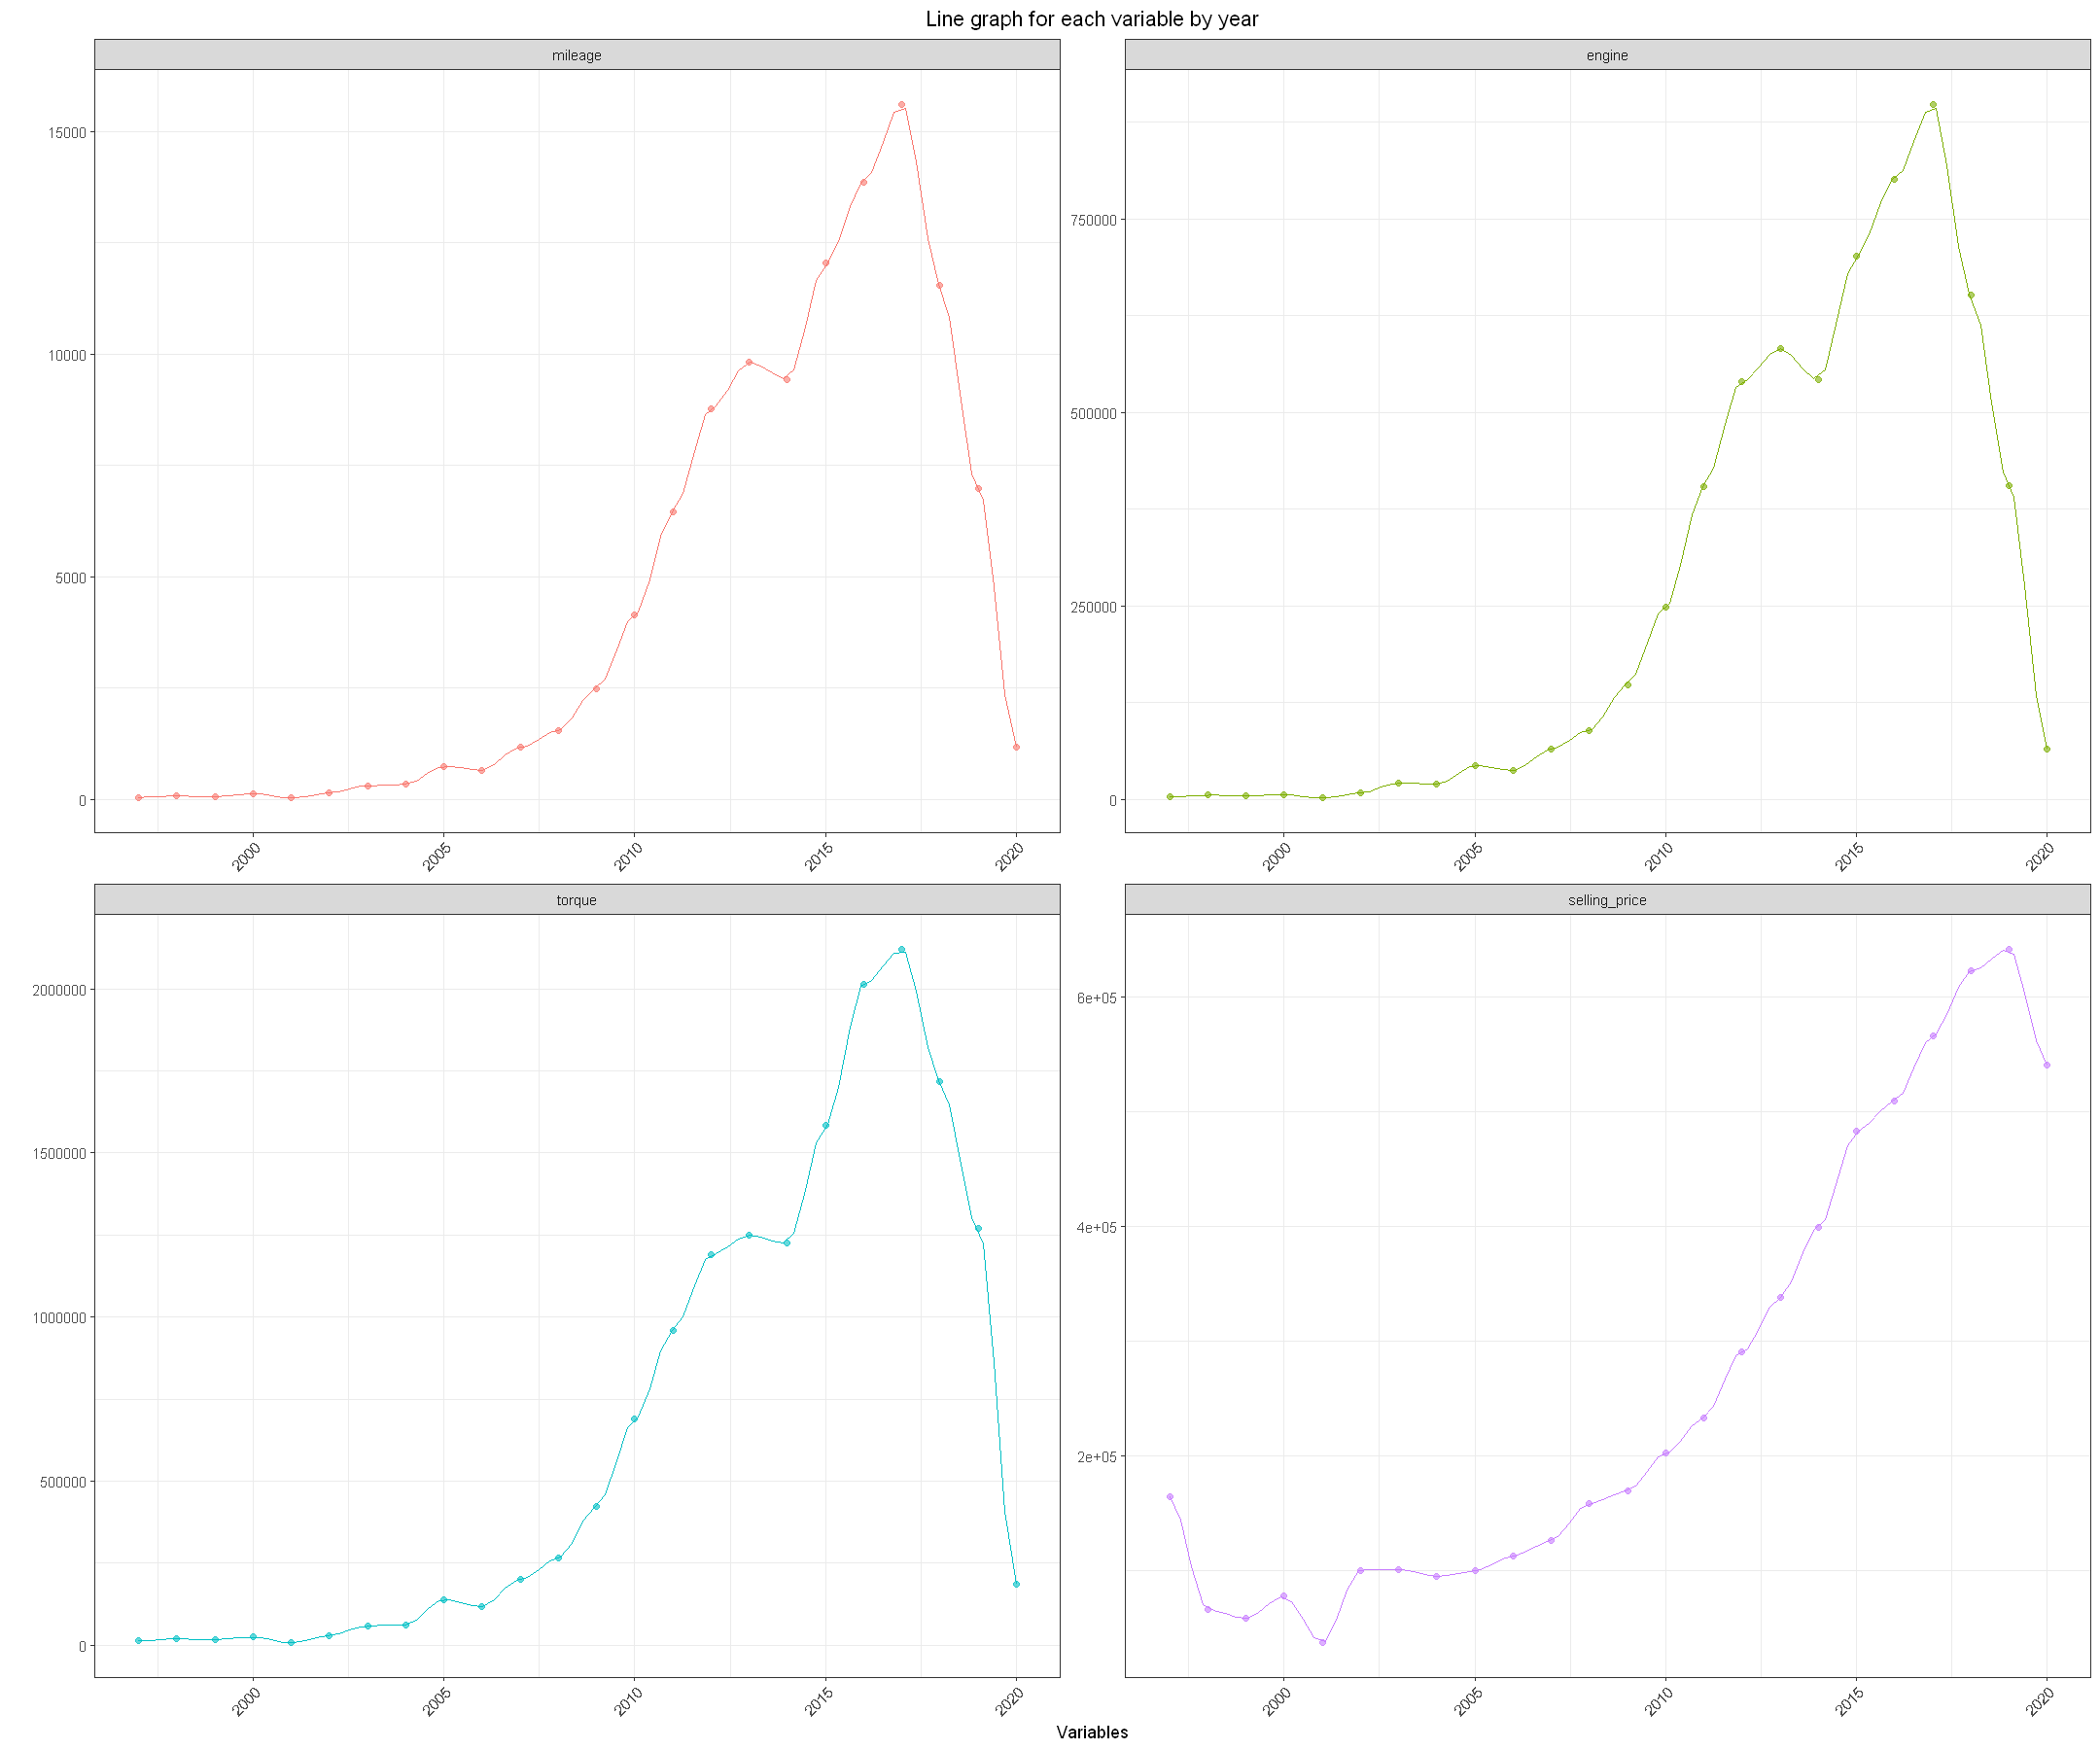

In [36]:
options(repr.plot.width = 18, repr.plot.height = 15)

#Melting the dataset to make the timeseries for continuous variable
dataset_melt = melt(dataset_agg, id = "year", variable_name = "Feature")

#Plotting the timeseries line graph for the continuous ariable
ggplot(dataset_melt, aes(x=year, y=value, color=variable)) + 
geom_point(size = 1.5, alpha = 0.6, aes(fill=variable)) +
stat_smooth(method="loess", span=0.1, size=0.5) +
facet_wrap(~variable, ncol=2, scales = "free") + 
labs(x="Variables", y="", fill='variable') + 
ggtitle("Line graph for each variable by year") + 
theme_bw() + 
theme(legend.position="none", plot.title = element_text(hjust = 0.5), 
      axis.text.x = element_text(angle = 45, hjust = 1))

Observation

- Looking at all the graph, we can see that all variables have the same trend with all of them starting to rise around 2010 and peaked at around 2018
-  At around 2014 all of the variables have a sharp decline then started to rise up again
- Doesn't look like there's any volatility in any of the graph
- All graph shows consistency in their trends

Then after making the continuous variable line graph, then we make the line graph for the categorical variables. This is done with ggplot but just with the categorical variables

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


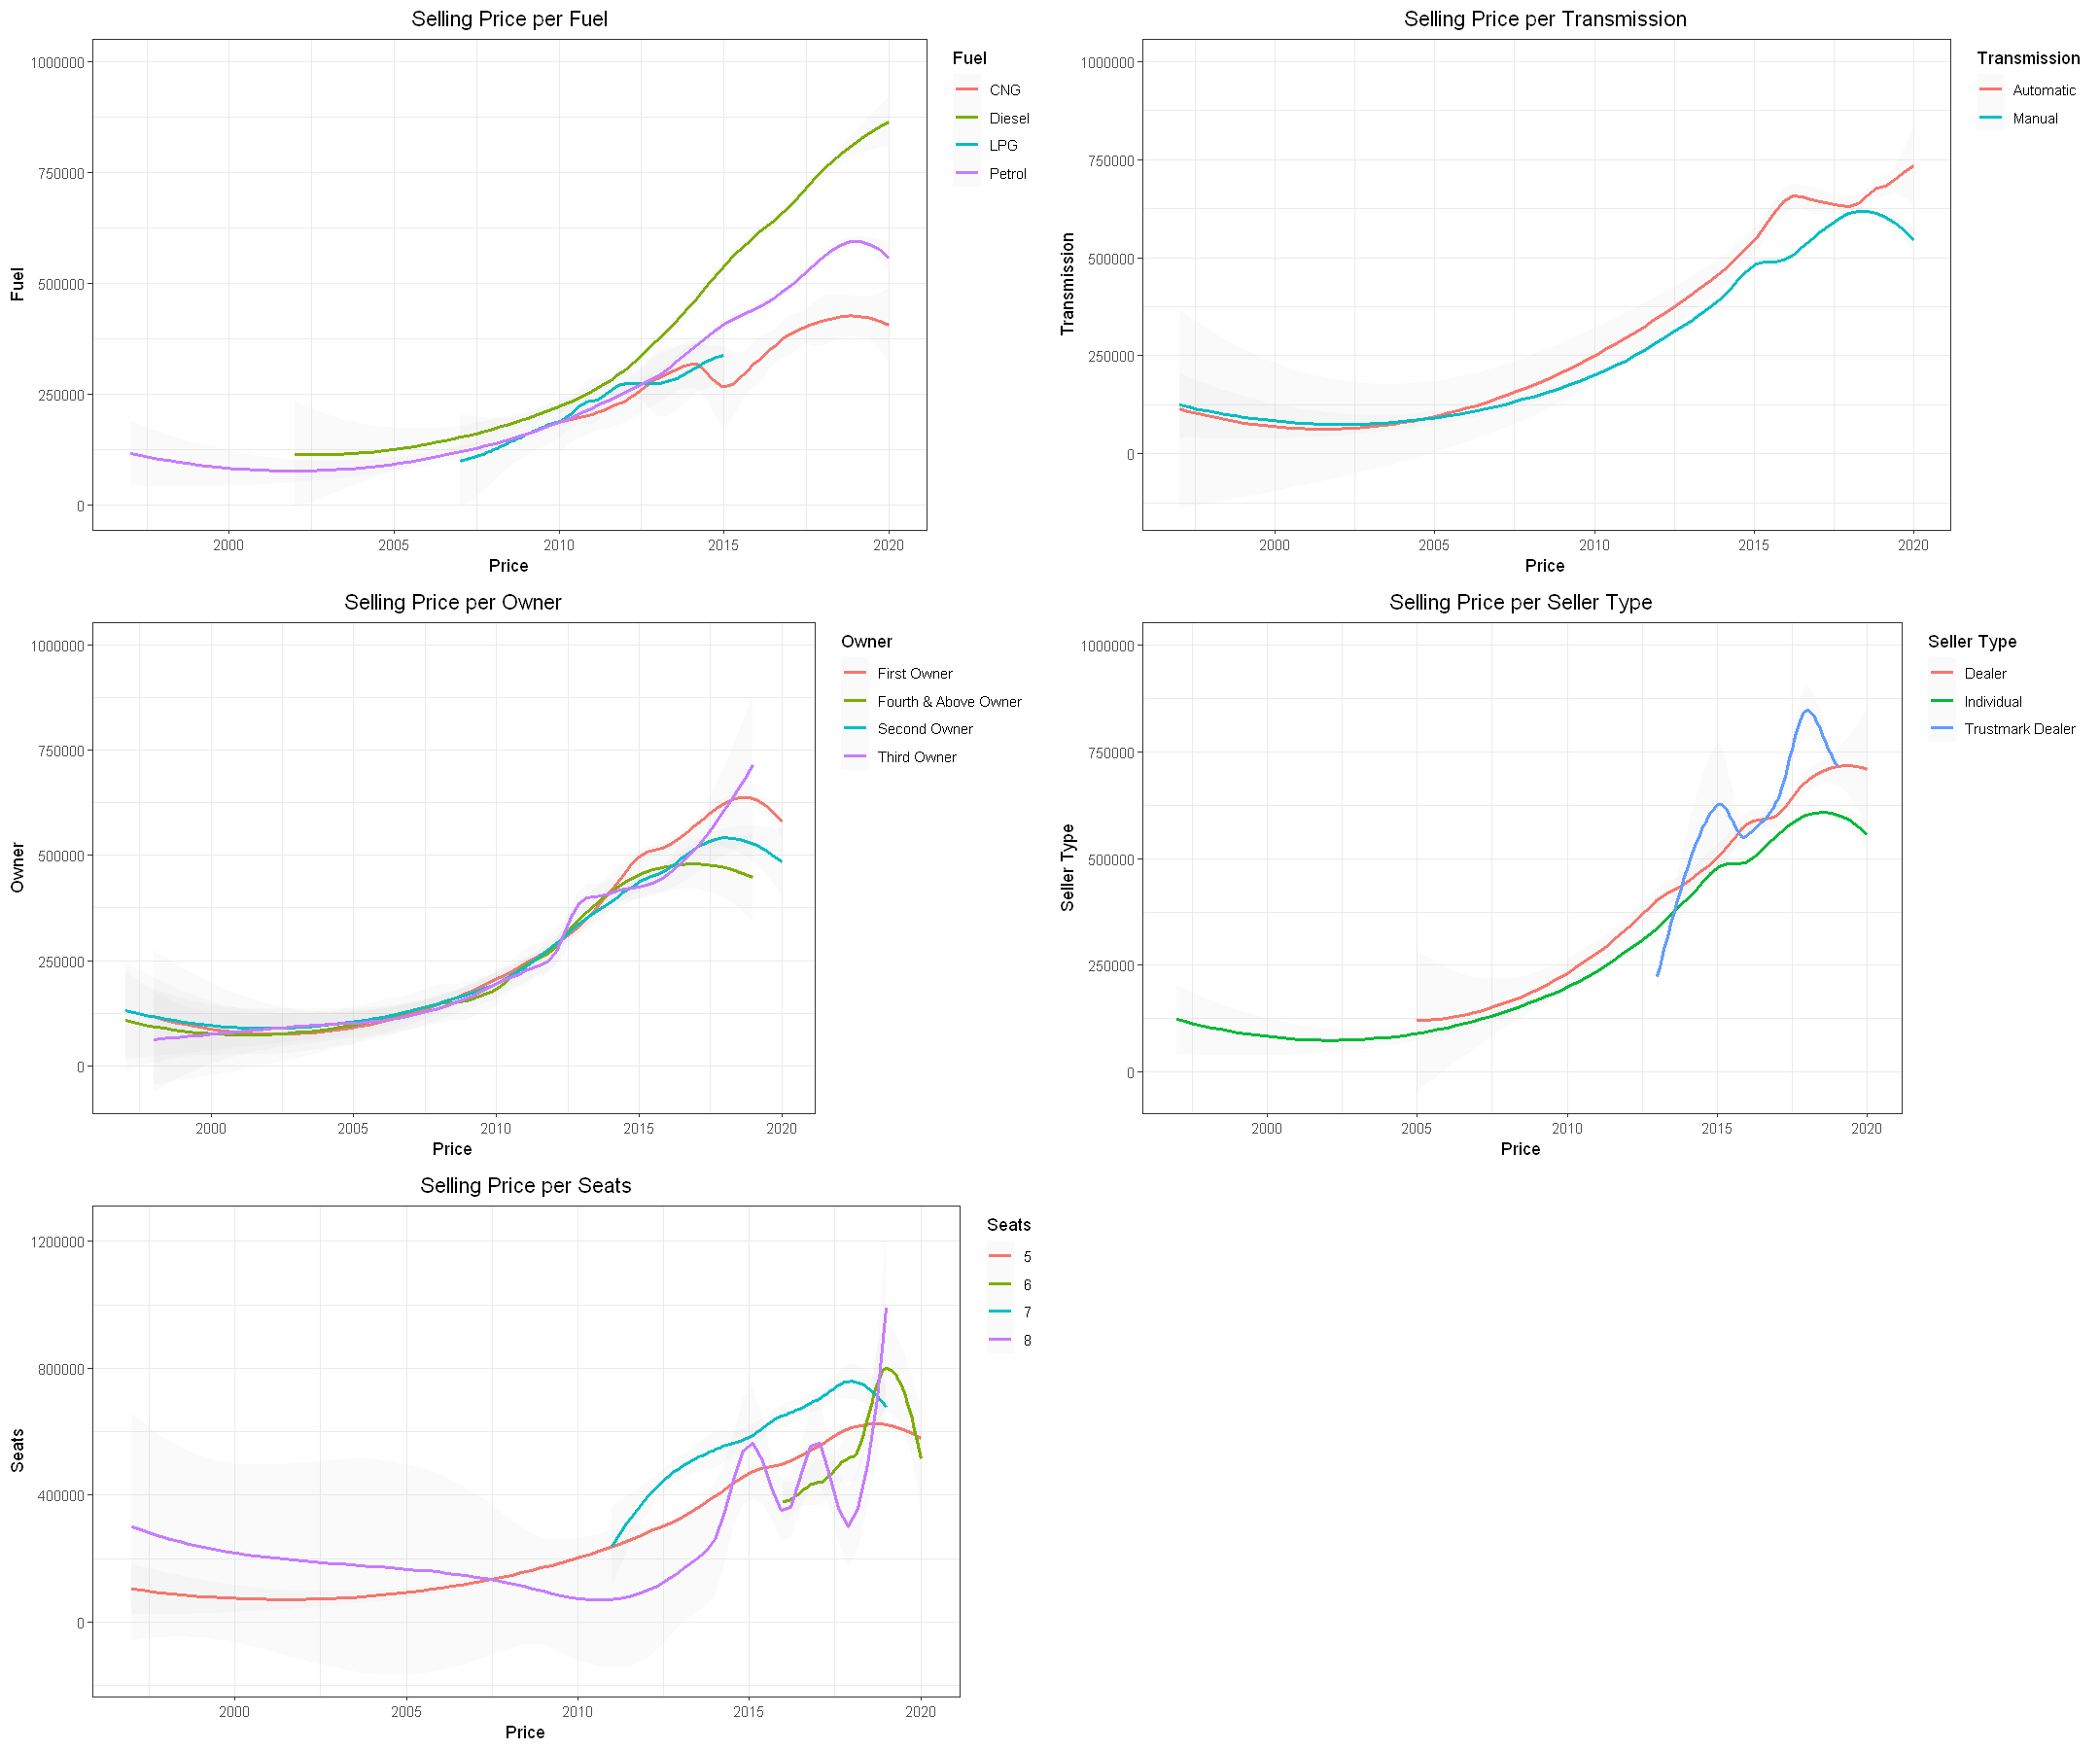

In [37]:
options(repr.plot.width = 18, repr.plot.height = 15)

#Making the linechart for the fuel variable
fig1 <- ggplot(dataset, aes(x=year, y=selling_price, group=fuel, color=fuel)) +
  geom_point(size = 1.1, alpha = 0) +
  stat_smooth(method="loess", span=0.5, size=1, alpha=0.05) +
  theme_bw() + 
  theme(legend.justification = "top", plot.title = element_text(hjust = 0.5)) + 
  labs(x="Price", y = "Fuel") +
  scale_x_date("Price") +
  guides(colour=guide_legend(title="Fuel")) +
  ggtitle("Selling Price per Fuel")

#Making the linechart for the transmission variable
fig2 <- ggplot(dataset, aes(x=year, y=selling_price, group=transmission, color=transmission)) +
  geom_point(size = 0.1, alpha = 0) +
  stat_smooth(method="loess", span=0.5, size=1, alpha=0.05) +
  theme_bw() + 
  theme(legend.justification = "top", plot.title = element_text(hjust = 0.5)) + 
  labs(x="Price", y = "Transmission") +
  scale_x_date("Price") +
  guides(colour=guide_legend(title="Transmission")) +
  ggtitle("Selling Price per Transmission")

#Making the linechart for the owner variable
fig3 <- ggplot(dataset, aes(x=year, y=selling_price, group=owner, color=owner)) +
  geom_point(size = 0.1, alpha = 0) +
  stat_smooth(method="loess", span=0.5, size=1, alpha=0.05) +
  theme_bw() + 
  theme(legend.justification = "top", plot.title = element_text(hjust = 0.5)) + 
  labs(x="Price", y = "Owner") +
  scale_x_date("Price") +
  guides(colour=guide_legend(title="Owner")) +
  ggtitle("Selling Price per Owner")

#Making the linechart for the seller_type variable
fig4 <- ggplot(dataset, aes(x=year, y=selling_price, group=seller_type, color=seller_type)) +
  geom_point(size = 0.1, alpha = 0) +
  stat_smooth(method="loess", span=0.5, size=1, alpha=0.05) +
  theme_bw() + 
  theme(legend.justification = "top", plot.title = element_text(hjust = 0.5)) + 
  labs(x="Price", y = "Seller Type") +
  scale_x_date("Price") +
  guides(colour=guide_legend(title="Seller Type")) +
  ggtitle("Selling Price per Seller Type")

#Making the linechart for the seats variable
fig5 <- ggplot(dataset, aes(x=year, y=selling_price, group=seats, color=seats)) +
  geom_point(size = 0.1, alpha = 0) +
  stat_smooth(method="loess", span=0.5, size=1, alpha=0.05) +
  theme_bw() + 
  theme(legend.justification = "top", plot.title = element_text(hjust = 0.5)) + 
  labs(x="Price", y = "Seats") +
  scale_x_date("Price") +
  guides(colour=guide_legend(title="Seats")) +
  ggtitle("Selling Price per Seats")

grid.arrange(fig1, fig2, fig3, fig4, fig5, ncol=2)

Observation

- Like the continuous variable, we can see that every categorical variable linechart also follows similar trend of rising at around 2010 then is starting to decline
- We can see that not all values is there from the start
- For fuel, we can see that diesel fuel is only being used at around 2003, LPG is around 2008, and CNG around 2010
- For transmission we can see that automatic transmission is just only being sold around 1995
- For seller type we can see that dealer just started at around 2003 while trustmark dealer started around 2014. Trustmark dealer trends shows volatility while both dealer and individual trends, shows steady increase
- For seats we can see that in the start that 8 seater car has a higher price than 5 seater but it steadily goes down then goes up again. 5 seater car has a steady upward trend while 7 seater car has just been sold around 2012 while 6 seater car is sold around 2017
- 6 Seater car sees an upward trend then suddenly drops during 2000 while 8 seater cars shows volatility in its trend 2015 and sees a sharp increase in 2017
- Looking at the trend, generally all the graph follow the same trend of downward trend until 2005 followed with steady increase until 2020. Some graph does show volatility like the 8 seater cars or the trustmark dealer. The graph with volatile tendency is usually the variable that didn't start from before 2000 like trustmark dealer or 6 seater car

Conclusion from EDA

- Originally the dataset has 8128 values per column with 13 collumns
- From the summary it is found that these columns has NaN values mileage = 221, engine = 221, max power = 215, torque = 222, and seats = 221. These rows are dropped
- Name columns are dropped since it is hard to wrangle the name of the cars to differentiate each car therefore it's dropped
- Mileage and Km_Driven column is describing the same thing, km_driven is choosen to be dropped
- From owner, test drive car is seen to only have one value therefore that specific value is dropped
- From the boxplot graph, we can see there's a lot of outlier in the column of continuous variable therefore it is corrected using the IQR method. After correction, the boxplot shows generally uniform range of the quartile and similar whisker
- From the histogram we can see that mileage has a normal distribution, selling price looks to be skewed to the right, engine, max power, and torque doesn't looks to have a distribution
- After checking the skewness and kurtosis of the selling price, it is found it's still within the acceptable range therefore no further correction is done for selling price
- The correlation analysis shows that the correlation between max power and engine is high (>0.7), this could interfere with the prediction. From reference it is found that CC are generally more seen as a predictor to buy a car or not therefore the max power column is deleted
- The categorical EDA, the count found that for most of the column the distribution is mostly pooled towards some of the values
- The boxplot of seats found out that the 2,4,14 seater car has small data pool and it's range is outside the other seater. This can cause interference during the modeling process therefore it's deleted
- From the time series for continuous variable, we can see that all attribute follow the same trend
- The categorical time series also mostly shows that the attributes follow the same trend. But some values didn't start from the beginning and those values shows volatility in the trend


## 3. Methodology

In this section, the methodology for modelling the prediction model is explained and the dataset preparation for the modelling is prepared. The basic theory behind the linear regression and its variation will also be explained here and methods used to evaluate the quality of the models

The purpose of prediction task is to build models that can predict the target variable from the predictor given. In this case the model needed to be able to predict selling_price target variable general enough from the other predictor attribute given to it. This tasks aims to explore the relationship between the predictor variable and target variable. This relationship is fine tuned so that when used with other values of predictor variable from real life, the relationship will be able to predict the target variable with good enough accuracy to be used in real life condition, in this case to predict the usedcar prices. Various machine learning algorithm can be used to do a modelling but for this certain tasks where the target variable is a continuous variable, linear regression is chosen to be the method.

Why linear regression is chosen? 

- A simple and easy to interpret mathematical formula
- It's been used for years so it's already well researched and a robust way to predic continuous variables
- It has low computational cost and work well with small dataset

5 models of linear regression will be made and evaluated to pick the best model which is

- Normal Linear Regression
- Linear Regression with backward stepwise
- Linear Regression with L1, L2, and combination of both regularization

After each models are made, every model will be evaluated to pick the best model then pick the attribute that has the best relationship with the target value. Then a new model will be made for the inference task

## Data Preparation

For preparing the dataset the column will be corrected into correct datatype and the dataset will be splitted into 0.7 train and 0.3 test ratio. The train dataset will be used to train the model then it will be tested on the test dataset to evaluate how well the model perform

In [38]:
#Setting the seed so that the code can be replicated
set.seed(42)

#Making a new dataset for ML purposes
dataset_ml <- dataset

#Converting the year column to factor again and wrangled so it can be used for predictor
dataset_ml$year <- format(dataset_ml$year, "%Y")
dataset_ml <- dataset_ml %>%
    mutate(
        year = as.factor(year)
    )


#Splitting the dataset with 0.7 ratio
train_ratio<- sample(seq_len(nrow(dataset_ml)), size = 0.7 * nrow(dataset_ml))

# Create training and testing sets
train <- dataset_ml[train_ratio, ]
test <- dataset_ml[-train_ratio, ]

### Linear Regression

As mentioned above, Linear Regression is the model that will be used to model the relationship between the selling price target variable and its predictor. The goal is to find a linear relationship between the variables. This relationship is the key in predicting the value of the target variables based on the difference values acquired from real life of the independent variable

The formula for linear regression is

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon$$


In order for linear regression to work, there are assumptions that needs to be met. There are 4 assumptions which is 

- Linearity: The relationship between X and the mean of Y is linear. The core premise of multiple linear regression is the existence of a linear relationship between the dependent (target) variable and the independent variables. This linearity can be visually inspected using scatterplots, which should reveal a straight-line relationship rather than a curvilinear one.
- Homoscedasticity: The variance of residual is the same for any value of X. The variance of error terms (residuals) should be consistent across all levels of the independent variables. A scatterplot of residuals versus predicted values should not display any discernible pattern, such as a cone-shaped distribution, which would indicate heteroscedasticity. Addressing heteroscedasticity might involve data transformation or adding a quadratic term to the model.
- Independence: Observations are independent of each other. It is essential that the independent variables are not too highly correlated with each other, a condition known as multicollinearity. This can be checked using: Correlation matrices, where correlation coefficients should ideally be below 0.80.
- Normality: For any fixed value of X, Y is normally distributed.

To evaluate the model, we'll use 

- R squared = This statistic indicates the proportion of the variance in the dependent variable (the variable you are trying to predict) that is explained by the independent variables (the predictors) in your regression model.

$$ R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}} $$

- Adjusted R squared = A modified version of R-squared that adjusts for the number of predictors in the model. It provides a more accurate measure of the model’s explanatory power, especially when multiple predictors are used.

$$ \bar{R}^2 = 1 - \left(1 - R^2\right) \frac{n - 1}{n - p - 1} $$

- MAE measures the average magnitude of the errors, without considering their direction. It is the average of the differences between the predicted and actual values.

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|$$

- MSE measures the average of the squared differences between the predicted and actual values. It gives more weight to larger errors, making it more sensitive to outliers than MAE.

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2$$


- RMSE is the square root of the MSE. It measures the standard deviation of the prediction errors and gives an idea of how much the predictions deviate from the actual values. Like MSE, it is more sensitive to larger errors.

$$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2} $$

Additionally, we'll also take a look at the residuals to measure homoscedascity. Other than measuring it visually, we'll also use Breush Pagan and NCV test to measure the residuals

- Breusch Pagan test is a statistical test used to detect the presence of heteroskedasticity in a linear regression model. It is based on the idea that if heteroskedasticity is present, the variance of the error term should be related to the predictor variables in the model.



## 4. Model Development <a class="anchor" id="sec_5"></a>

In this section we'll model the linear regression model based on the explanation above

## Vanilla Linear Regression

First we'll do the basic linear regression. Each markdown after the code will summarize the findings. The observation and analysis will be done at the end of the model

In [39]:
#Modelling the Linear Regression
lm_car = lm(selling_price~., data = train) 
#Getting the specifics of the linear regression from summary function
summary(lm_car) #Review the results


Call:
lm(formula = selling_price ~ ., data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-457266  -75814     137   72078  408774 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 -1.402e+05  1.249e+05  -1.123 0.261683    
year1998                    -2.358e+05  1.331e+05  -1.771 0.076570 .  
year1999                    -2.394e+05  1.341e+05  -1.786 0.074227 .  
year2000                    -1.154e+05  1.253e+05  -0.922 0.356782    
year2001                    -2.295e+05  1.623e+05  -1.414 0.157550    
year2002                    -1.401e+05  1.265e+05  -1.107 0.268231    
year2003                    -1.864e+05  1.202e+05  -1.551 0.121099    
year2004                    -1.584e+05  1.209e+05  -1.309 0.190494    
year2005                    -1.609e+05  1.177e+05  -1.367 0.171653    
year2006                    -1.502e+05  1.183e+05  -1.269 0.204374    
year2007                    -1.462e+05  1.171e+05  -1.249

In [40]:
# Use the predict() function to make predictions on the training data then calculate the residuals
predictions = predict(lm_car, test)
residuals = test$selling_price - predictions

# Calculate MAE, MSE, RMSE
mae = mean(abs(residuals))
mse = mean(residuals^2)
rmse = sqrt(mse)
variance = var(test$selling_price)

# Print the results
print(paste("Variance: ", variance))
print(paste("Mean Absolute Error: ", mae))
print(paste("Mean Squared Error: ", mse))
print(paste("Root Mean Squared Error: ", rmse))


[1] "Variance:  45579011008.7448"
[1] "Mean Absolute Error:  89675.5381833331"
[1] "Mean Squared Error:  13204174926.2204"
[1] "Root Mean Squared Error:  114909.420528608"


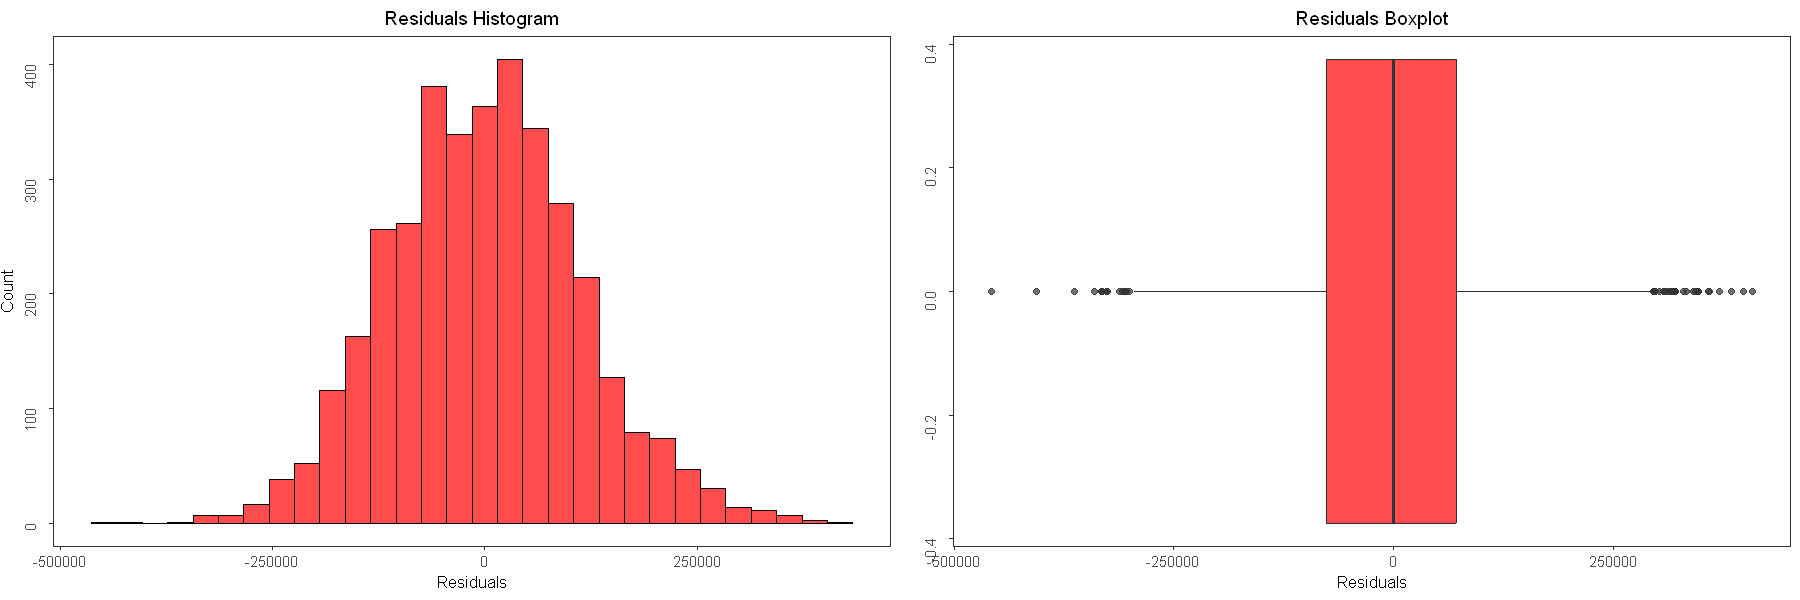

In [41]:
options(repr.plot.width = 15, repr.plot.height = 5)

#Plotting the histogram for the residual
lm_hist <- ggplot(data = train, aes(x = lm_car$residuals)) + 
    geom_histogram(bins=30, alpha=0.7, color="black", fill="red") + 
    labs(x="Residuals", y ="Count") +
    ggtitle("Residuals Histogram") + 
    theme_bw() + 
    theme(axis.title = element_text(size = 10),
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.title.y = element_text(vjust = 4), 
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

#Plotting the boxplot for the residual
lm_box <- ggplot(data= train, aes(lm_car$residuals)) + 
    geom_boxplot(alpha=0.7, fill="red") + ylab("") + xlab("Residuals") +
    theme_bw() + 
    ggtitle("Residuals Boxplot") + 
    theme(axis.title = element_text(size = 10), 
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

grid.arrange(lm_hist, lm_box, ncol=2)



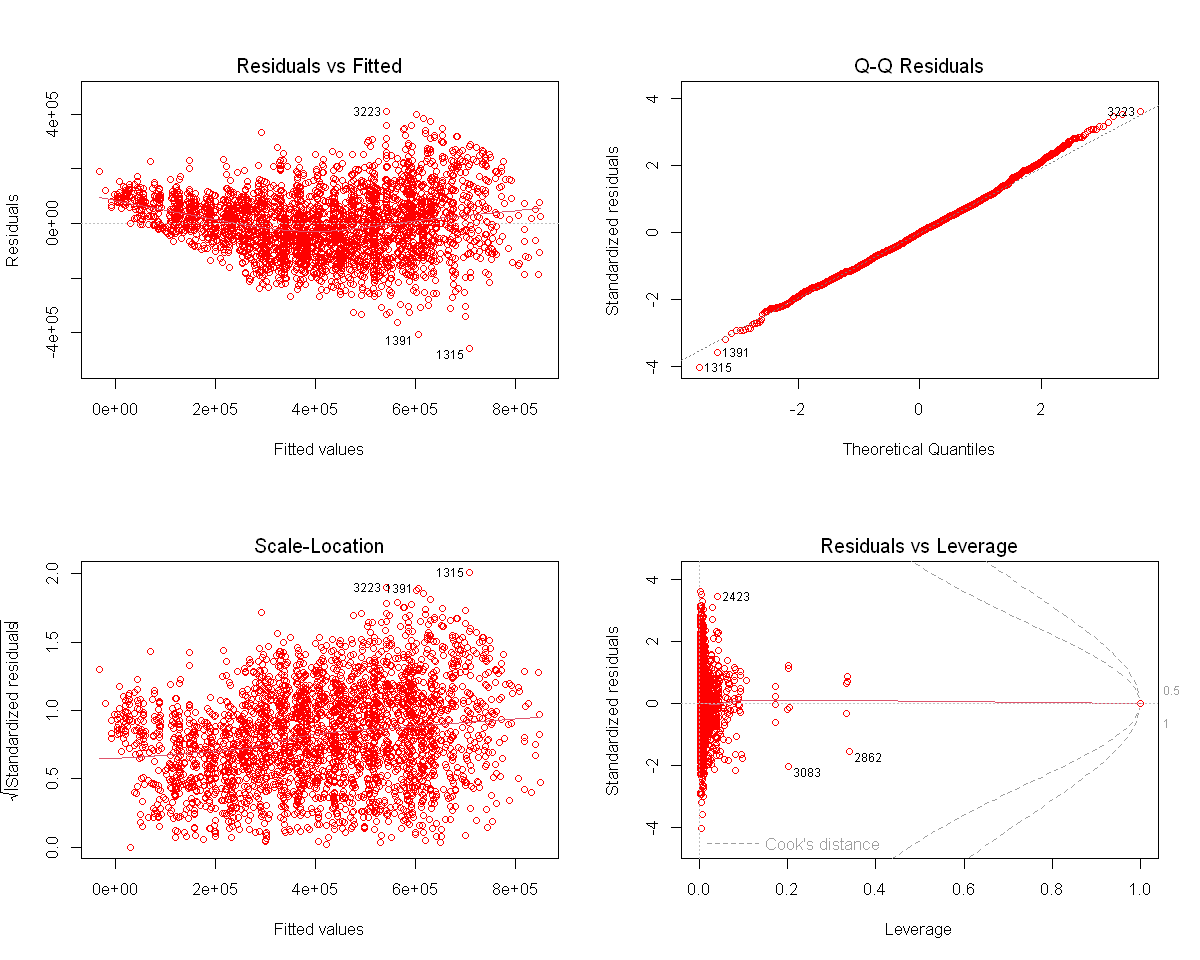

In [42]:
options(repr.plot.width = 10, repr.plot.height = 8)

#Plotting the scatterplot for residuals vs fitted, scale vs location, residual vs leverage. And the qq plot for residuals
par(mfrow=c(2,2))
plot(lm_car, col='red')

In [43]:
#Breush Pagan and NCV test to evaluate the residuals
bptest(lm_car)


	studentized Breusch-Pagan test

data:  lm_car
BP = 367.27, df = 38, p-value < 2.2e-16


Observation for the Vanilla Linear Regression

- Based from the R squared and the Adjusted R squared, we got the value of around 0.72. This means that the model is able to predict 70% of the variation of the target variable. This signify a good model since it doesn't overfit or underfit
- The MAE, MSE, and RMSE shows a high value which signify a big variance in the target value but the it's still marginally lower than the variance which signify the model is still better predicting the target variable than a lazy model
- From the boxplot and histogram of the residuals, we can see that the mean is at 0 which signify they follow the normal distribution
- Visually the scatterplot of the residuals doesn't look like it follows a pattern which signify there's no heteroscadicity present. This further reinforced after ussing the Breusch-Pagan test showing a value below 0.05 meaning that no heteroscadicity is present
- Around 10 model coefficients proved to be significant with p value lower than 0.01
- P-value is 2.2e-16 which signify that we can reject the null hypothesis

### Forward Stepwise Regression

Next up we'll be using the stepwise regression model with using the forwrdd method. This method is used to do automatic feature selection by choosing the most relevant features first then adding the rest.

In [44]:
#Configuring the forward stepwise regression model
lm_forward <- step(lm_car, direction = "forward")
summary(lm_forward)

Start:  AIC=84667.26
selling_price ~ year + fuel + seller_type + transmission + owner + 
    mileage + engine + torque + seats




Call:
lm(formula = selling_price ~ year + fuel + seller_type + transmission + 
    owner + mileage + engine + torque + seats, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-457266  -75814     137   72078  408774 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 -1.402e+05  1.249e+05  -1.123 0.261683    
year1998                    -2.358e+05  1.331e+05  -1.771 0.076570 .  
year1999                    -2.394e+05  1.341e+05  -1.786 0.074227 .  
year2000                    -1.154e+05  1.253e+05  -0.922 0.356782    
year2001                    -2.295e+05  1.623e+05  -1.414 0.157550    
year2002                    -1.401e+05  1.265e+05  -1.107 0.268231    
year2003                    -1.864e+05  1.202e+05  -1.551 0.121099    
year2004                    -1.584e+05  1.209e+05  -1.309 0.190494    
year2005                    -1.609e+05  1.177e+05  -1.367 0.171653    
year2006                    -1.502e+05  

In [45]:
# Use the predict() function to make predictions on the test data
predictions_forward = predict(lm_forward, test)

# Calculate the residuals/errors
residuals_forward = test$selling_price - predictions_forward

# Calculate MAE
mae_forward = mean(abs(residuals))

# Calculate MSE
mse_forward = mean(residuals^2)

# Calculate RMSE
rmse_forward = sqrt(mse_forward)

# Print the metrics
print(paste("Variance: ", var(test$selling_price)))
print(paste("Mean Absolute Error: ", mae_forward))
print(paste("Mean Squared Error: ", mse_forward))
print(paste("Root Mean Squared Error: ", rmse_forward))

[1] "Variance:  45579011008.7448"
[1] "Mean Absolute Error:  89675.5381833331"
[1] "Mean Squared Error:  13204174926.2204"
[1] "Root Mean Squared Error:  114909.420528608"


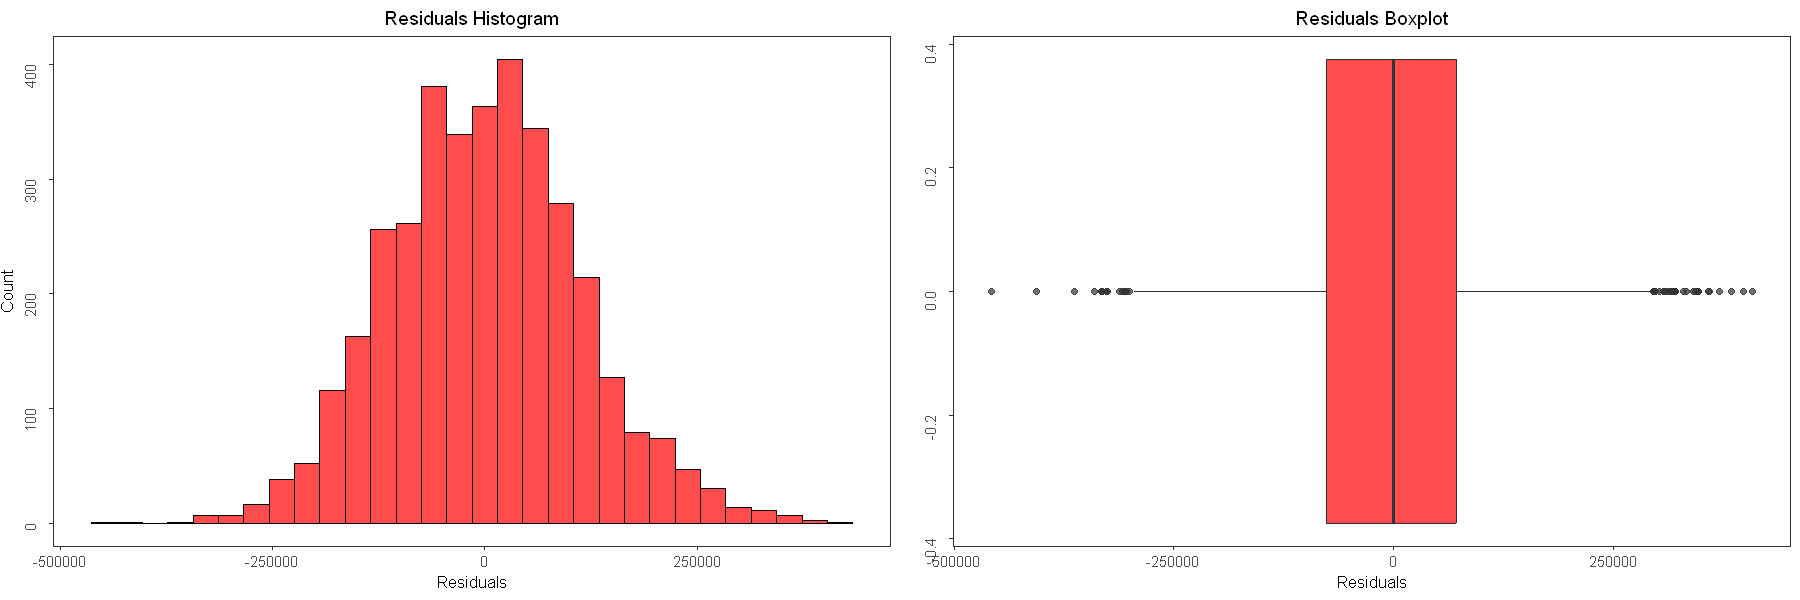

In [46]:
options(repr.plot.width = 15, repr.plot.height = 5)

#Plotting the histogram for the residual
forward_hist <- ggplot(data = train, aes(x = lm_forward$residuals)) + 
    geom_histogram(bins=30, alpha=0.7, color="black", fill="#ff0000") + 
    labs(x="Residuals", y ="Count") +
    ggtitle("Residuals Histogram") + 
    theme_bw() + 
    theme(axis.title = element_text(size = 10),
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.title.y = element_text(vjust = 4), 
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

#Plotting the boxplot for the residual
forward_box <- ggplot(data= train, aes(lm_forward$residuals)) + 
    geom_boxplot(alpha=0.7, fill="#ff0000") + ylab("") + xlab("Residuals") +
    theme_bw() + 
    ggtitle("Residuals Boxplot") + 
    theme(axis.title = element_text(size = 10), 
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

grid.arrange(forward_hist, forward_box, ncol=2)

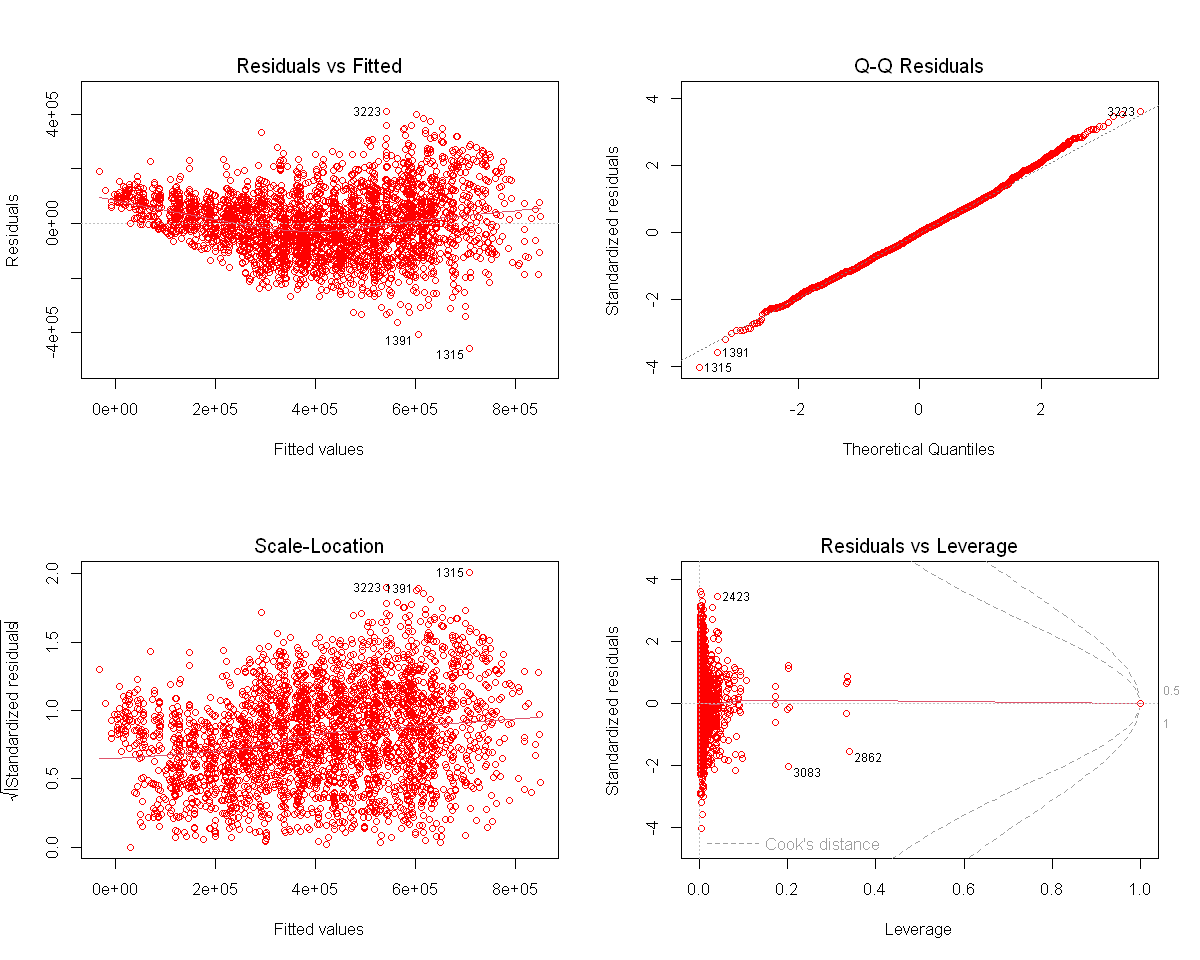

In [47]:
options(repr.plot.width = 10, repr.plot.height = 8)

#Plotting the scatterplot for residuals vs fitted, scale vs location, residual vs leverage. And the qq plot for residuals
par(mfrow=c(2,2))
plot(lm_forward, col='red')

In [48]:
#Breush Pagan and NCV test to evaluate the residuals
bptest(lm_forward)


	studentized Breusch-Pagan test

data:  lm_forward
BP = 367.27, df = 38, p-value < 2.2e-16


### Observations

The result of the forward regression is almost exactly the same with the normal vanilla linear regression. The R squared, p value, MAE, MSE, RMSE, and residuals analysis are exactly the same so even though we added an extra step to do the forward stepwise feature selection. This model is more or less the same model as the vanilla linear regression

### Backward Stepwise Regression

Next up we'll be using the stepwise regression model with using the backward method. This method is used to do automatic feature selection by deleting features that deemed irrelevant for the model using the step() function.

In [49]:
#Configuring the backward stepwise regression then getting the summary
lm_back <- step(lm_car)
summary(lm_back)

Start:  AIC=84667.26
selling_price ~ year + fuel + seller_type + transmission + owner + 
    mileage + engine + torque + seats

               Df  Sum of Sq        RSS   AIC
- torque        1 1.4898e+10 4.6453e+13 84666
<none>                       4.6438e+13 84667
- mileage       1 3.4451e+10 4.6472e+13 84668
- seller_type   2 2.8557e+11 4.6724e+13 84686
- fuel          3 4.8498e+11 4.6923e+13 84699
- transmission  1 5.6889e+11 4.7007e+13 84710
- owner         3 6.4295e+11 4.7081e+13 84711
- seats         3 1.7640e+12 4.8202e+13 84797
- engine        1 8.9601e+12 5.5398e+13 85307
- year         23 4.0880e+13 8.7318e+13 86917

Step:  AIC=84666.43
selling_price ~ year + fuel + seller_type + transmission + owner + 
    mileage + engine + seats

               Df  Sum of Sq        RSS   AIC
<none>                       4.6453e+13 84666
- mileage       1 3.2011e+10 4.6485e+13 84667
- seller_type   2 2.8188e+11 4.6735e+13 84684
- transmission  1 5.5839e+11 4.7011e+13 84708
- owner         3


Call:
lm(formula = selling_price ~ year + fuel + seller_type + transmission + 
    owner + mileage + engine + seats, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-456929  -75217      -3   72567  409172 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 -155689.73  124056.40  -1.255 0.209563    
year1998                    -231375.99  133069.01  -1.739 0.082161 .  
year1999                    -237285.94  134071.94  -1.770 0.076838 .  
year2000                    -110035.77  125154.60  -0.879 0.379352    
year2001                    -227813.28  162329.85  -1.403 0.160585    
year2002                    -135622.02  126480.75  -1.072 0.283669    
year2003                    -181243.44  120137.71  -1.509 0.131481    
year2004                    -151895.88  120797.53  -1.257 0.208675    
year2005                    -154538.35  117517.25  -1.315 0.188585    
year2006                    -143919.50  118149.39

In [50]:
# Use the predict() function to make predictions on the training data
predictions = predict(lm_back, test)

# Calculate the residuals/errors
residuals_back = test$selling_price - predictions

# Calculate MAE
mae_back = mean(abs(residuals_back))

# Calculate MSE
mse_back = mean(residuals_back^2)

# Calculate RMSE
rmse_back = sqrt(mse_back)

# Print the metrics
print(paste("Variance: ", var(test$selling_price)))
print(paste("Mean Absolute Error: ", mae_back))
print(paste("Mean Squared Error: ", mse_back))
print(paste("Root Mean Squared Error: ", rmse_back))

[1] "Variance:  45579011008.7448"
[1] "Mean Absolute Error:  89618.9836912132"
[1] "Mean Squared Error:  13209616600.3544"
[1] "Root Mean Squared Error:  114933.096192326"


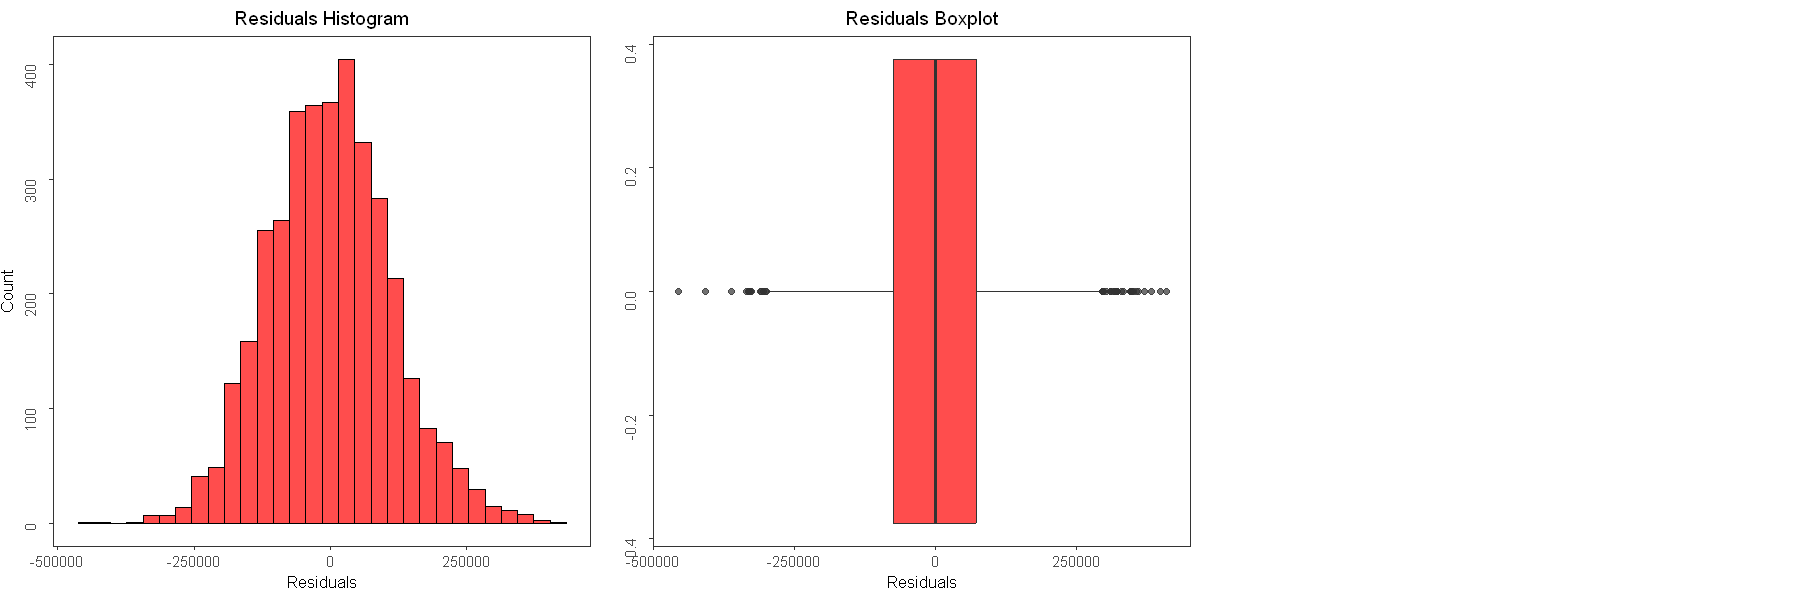

In [51]:
options(repr.plot.width = 15, repr.plot.height = 5)


back_hist <- ggplot(data = train, aes(x = lm_back$residuals)) + 
    geom_histogram(bins=30, alpha=0.7, color="black", fill="red") + 
    labs(x="Residuals", y ="Count") +
    ggtitle("Residuals Histogram") + 
    theme_bw() + 
    theme(axis.title = element_text(size = 10),
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.title.y = element_text(vjust = 4), 
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

back_box <- ggplot(data= train, aes(lm_back$residuals)) + 
    geom_boxplot(alpha=0.7, fill="red") + ylab("") + xlab("Residuals") +
    theme_bw() + 
    ggtitle("Residuals Boxplot") + 
    theme(axis.title = element_text(size = 10), 
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

grid.arrange(back_hist, back_box, ncol=3)


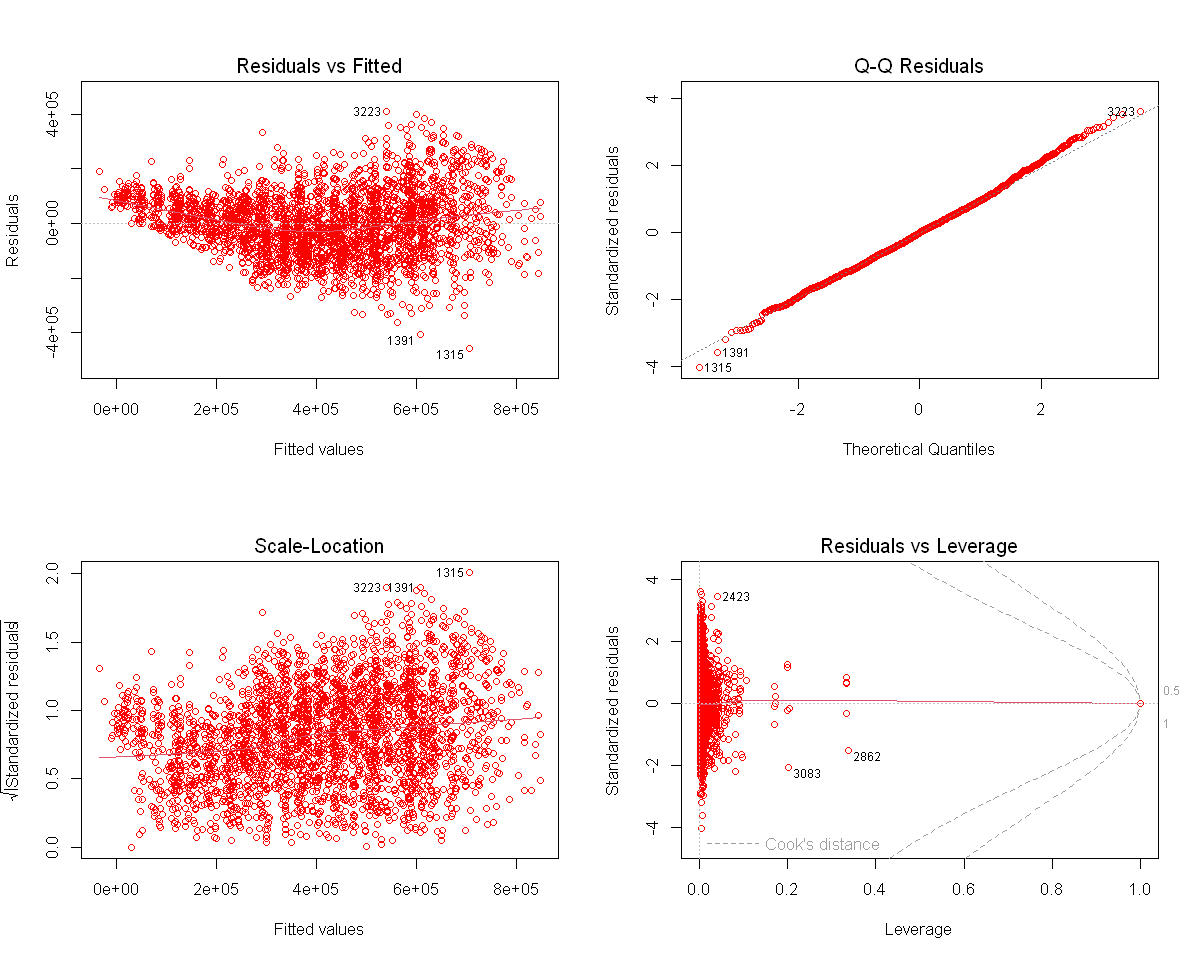

In [52]:
options(repr.plot.width = 10, repr.plot.height = 8)
par(mfrow=c(2,2))
plot(lm_back, col='red')

In [53]:
#Breush Pagan to evaluate the residuals
bptest(lm_back)



	studentized Breusch-Pagan test

data:  lm_back
BP = 362.82, df = 37, p-value < 2.2e-16


Observations

- From the summary alone, we can see that the torque attribute is deleted from the final model
- Although the pvalue and adjusted R squared value remains the same, we can see 0.001 reduction in R squared
- From MAE, MSE, and RMSE. We can see a reduction in the MAE from 89675.53 to 89618.98. But there's an increase in MSE and RMSE, for example the RMSE value from 114909.42 to 114933.09
- The residuals shows a similar visuals and the Breush Pagan test yields similar value

## Regularization

Next up we'll use regularization method to train the model. There are three types of regularization which is Lasso (L1), Ridge (L2), and Elastic Net model which is the hybrid of the two. Simple explanation of each type 

- Lasso (L1) = The model will add a penalty equal to the absolute value of the magnitude of the coefficients

$$\text{L1 Penalty} = \lambda \sum_{j=1}^{p} | \beta_j |$$

- Ridge (L2) = The model will add a penalty equal to the square magnitude of the coefficients

$$\text{L2 Penalty} = \lambda \sum_{j=1}^{p} \beta_j^2$$

- Elastic Net = The way to calculate the penalty is combined from both L1 and L2 method

$\lambda$ here is the regularization strength to determine how strong the correction of the penalty is used towards the model. With a big $\lambda$ then all the attributes will go down to 0 while a low $\lambda$, it's like we didn't do any penalty correction at all.

With regularization, because the penalty is added to the coefficients. It's difficult to count the p-value of the attributes, therefore to evaluate the model we'll focus on the MAE, MSE, RMSE, and the residuals analysis

To be able to model the regularization model, we need to transform the dataset into a matrix form therefore we will first transform both train and test dataset to matrix form

In [54]:
#Transforming the train dataset into matrix form
train_m <- train %>%
  select(-selling_price) %>%
  bind_cols(train %>% select(selling_price))

y <- train_m %>%
    select(selling_price) %>%
    as.matrix() 

X <- model.matrix(~ . - 1, data = train_m %>% select(-selling_price))

#Transforming the test dataset into matrix form
test_m <- test %>%
  select(-selling_price) %>%
  bind_cols(test %>% select(selling_price))

y_test <- test_m %>%
    select(selling_price) %>%
    as.matrix() 

X_test <- model.matrix(~ . - 1, data = test_m %>% select(-selling_price))


### L2 Ridge Model

Now we'll do the regularization model. First we'll do the L2 Ridge model. In this code we'll use auto selection for the lambda and do an automatic cross validation to cross validate the model

In [55]:
# Train the Ridge regression model
ridge_model <- glmnet(X, y, alpha = 0)  # alpha = 0 for Ridge regression

# Selecting the optimal lambda using cross-validation
cv_ridge <- cv.glmnet(X, y, alpha = 0)
best_lambda_ridge <- cv_ridge$lambda.min

# Train the final Ridge regression model with the best lambda
ridge_model_best <- glmnet(X, y, alpha = 0, lambda = best_lambda_ridge)
print(ridge_model_best)


Call:  glmnet(x = X, y = y, alpha = 0, lambda = best_lambda_ridge) 

  Df  %Dev Lambda
1 40 72.43  10160


To evaluate the model because the regularization model didn't automatically give out the residuals, we need to count it manually. First we'll count the residuals for the train dataset then do it to the test dataset. After that, we can use it to count the MAE, MSE, RMSE and plot the residuals plot

In [56]:
#Calculating the residuals towards the test data
predictions_l2 = predict(ridge_model_best, X_test)
residuals_l2 = test$selling_price - predictions_l2

#Calculate MAE, MSE, and RMSE
mae_l2 = mean(abs(residuals_l2))
mse_l2 = mean(residuals_l2^2)
rmse_l2 = sqrt(mse_l2)

#Print MAE, MSE, and RMSE
print(paste("Variance: ", var(test$selling_price)))
print(paste("Mean Absolute Error: ", mae_l2))
print(paste("Mean Squared Error: ", mse_l2))
print(paste("Root Mean Squared Error: ", rmse_l2))

[1] "Variance:  45579011008.7448"
[1] "Mean Absolute Error:  89360.1193905725"
[1] "Mean Squared Error:  13248560472.5764"
[1] "Root Mean Squared Error:  115102.391254815"


In [57]:
#Counting the train residuals
residual_ridge = test$selling_price - predict(ridge_model_best, X_test)
#Counting the test residuals
predict_ridge = predict(ridge_model_best, X_test)

#Combining both residuals into one dataframe
combine_ridge <- cbind(residual_ridge, predict_ridge)
colnames(combine_ridge) <- c('resi', 'pred')
combine_ridge <- as.data.frame(combine_ridge)

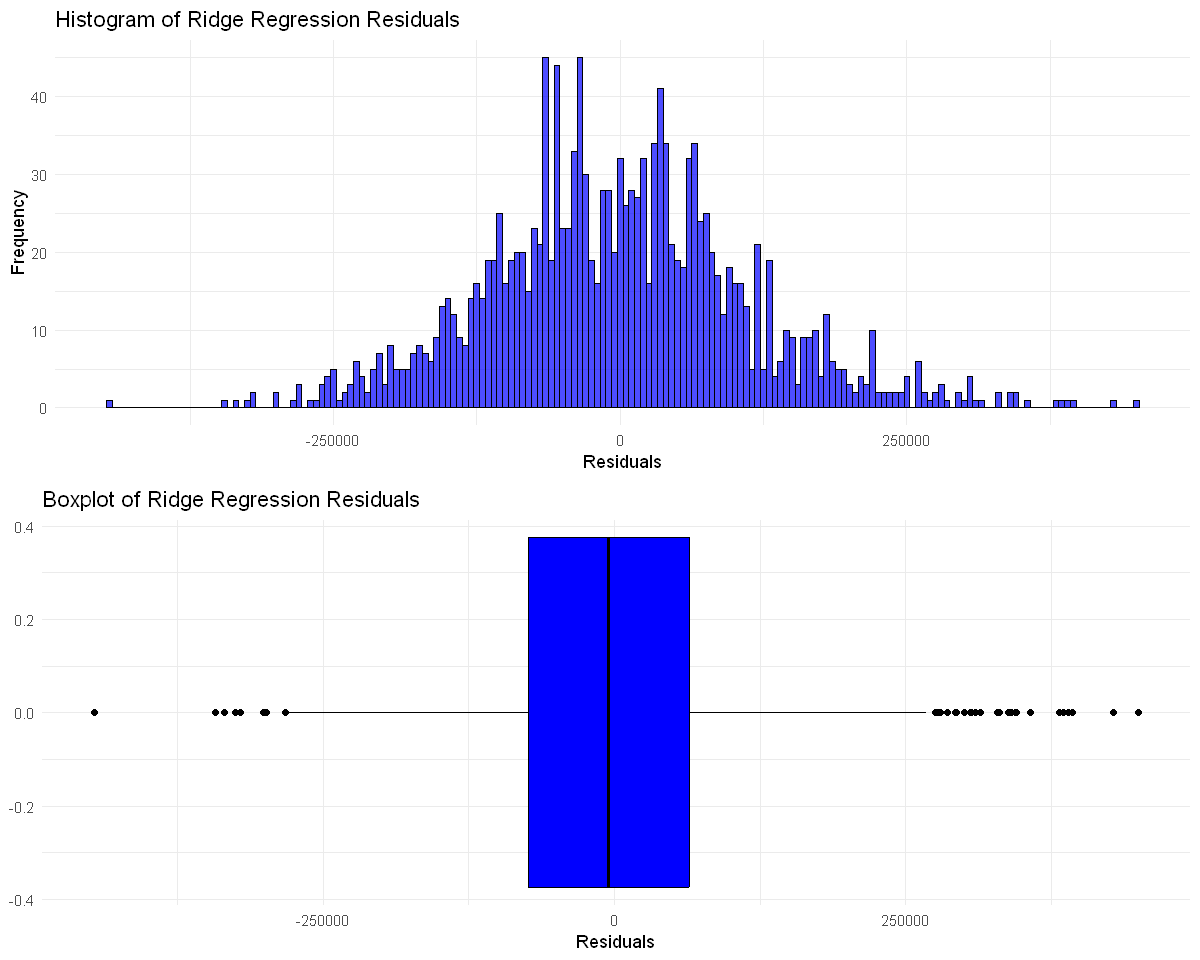

In [58]:
#Plotting the histogram for the Ridge Residuals
ridge_1 <- ggplot(combine_ridge, aes(x = resi)) +
  geom_histogram(binwidth = 5000, fill = "blue", color = "black", alpha = 0.7) +
  labs(title = "Histogram of Ridge Regression Residuals",
       x = "Residuals",
       y = "Frequency") +
  theme_minimal()

#Plotting the boxplot for the Ridge residuals
ridge_2 <- ggplot(combine_ridge, aes(y = resi)) +
  geom_boxplot(fill = "blue", color = "black") +
  labs(title = "Boxplot of Ridge Regression Residuals",
       y = "Residuals") +
  theme_minimal() +
  coord_flip()

grid.arrange(ridge_1, ridge_2)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


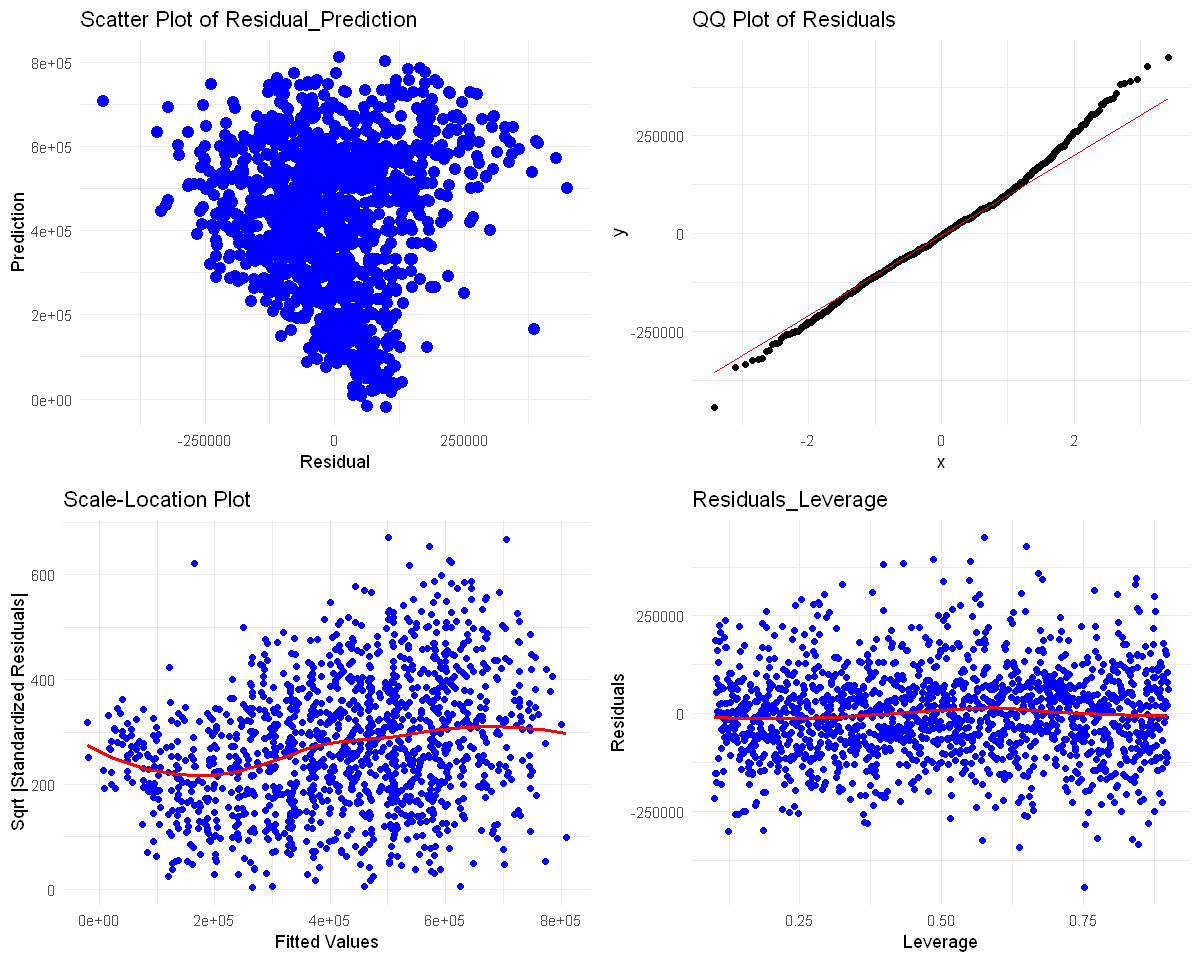

In [59]:
#Plotting the scatter plot of residual vs prediction
point_ridge <- ggplot(data=combine_ridge, aes(x = resi, y = pred)) +
  geom_point(color = "blue", size = 3) +
  labs(title = "Scatter Plot of Residual_Prediction", 
       x = "Residual", 
       y = "Prediction") +
  theme_minimal()

#Plotting the qq plot for the residual
qq_ridge <- ggplot(combine_ridge, aes(sample = resi)) +
  stat_qq() +
  stat_qq_line(col = "red") +
  labs(title = "QQ Plot of Residuals") +
  theme_minimal()

#Plotting the scatter plot for scale location plot
combine_ridge$sqrt_resi <- sqrt(abs(combine_ridge$resi))
scale_ridge <- ggplot(combine_ridge, aes(x = pred, y = sqrt_resi)) +
  geom_point(color = "blue") +
  geom_smooth(method = "loess", se = FALSE, color = "red") +
  labs(title = "Scale-Location Plot", x = "Fitted Values", y = "Sqrt |Standardized Residuals|") +
  theme_minimal()

#Plotting the scatter plot for residual leverage
combine_ridge$leverage <- seq(0.1, 0.9, length.out = nrow(combine_ridge))
leverage_ridge <- ggplot(combine_ridge, aes(x = leverage, y = resi)) +
  geom_point(color = "blue") +
  geom_smooth(method = "loess", se = FALSE, color = "red") +
  labs(title = "Residuals_Leverage", x = "Leverage", y = "Residuals") +
  theme_minimal()

grid.arrange(point_ridge, qq_ridge, scale_ridge, leverage_ridge)

In [60]:
#Breush Pagan to evaluate the residuals
bptest(residuals_l2 ~ X_test)


	studentized Breusch-Pagan test

data:  residuals_l2 ~ X_test
BP = 151.03, df = 38, p-value = 2.081e-15


Observation
- We can see that like backward stepwise regression, the L2 model has a smaller MAE but higher MSE and RMSE. 
- The boxplot and the histogram of the residuals signify that the mean of the residuals is around 0 similar to the normal linear regression
- The scatter plot of the residuals visualize a pattern of the residuals. Also the line for the scale location plot is not as smooth compared to the LR. The upward region of the QQ plot also shows an upward trend
- The Breush Pagan test for Ridge Regression also shows a higher value compared to the linear regression one 

### L1 Lasso Model

Next we'll do the L1 Lasso model. In this code we'll use auto selection for the lambda and do an automatic cross validation to cross validate the model

In [61]:
#Train the Lasso regression model
lasso_model <- glmnet(X, y, alpha = 1)  # alpha = 1 for Lasso regression

#Selecting the the optimal lambda using cross-validation
cv_lasso <- cv.glmnet(X, y, alpha = 1)
best_lambda_lasso <- cv_lasso$lambda.min

#Train the final Lasso regression model with the best lambda
lasso_model_best <- glmnet(X, y, alpha = 1, lambda = best_lambda_lasso)
print(lasso_model_best)


Call:  glmnet(x = X, y = y, alpha = 1, lambda = best_lambda_lasso) 

  Df  %Dev Lambda
1 39 72.66   86.3


In [62]:
#Calculating the residuals towards the test data
predictions_l1 = predict(lasso_model_best, X_test)
residuals_l1 = test$selling_price - predictions_l1

#Calculate MAE, MSE, and RMSE
mae_l1 = mean(abs(residuals_l1))
mse_l1 = mean(residuals_l1^2)
rmse_l1 = sqrt(mse_l1)

#Print MAE, MSE, and RMSE
print(paste("Variance: ", var(test$selling_price)))
print(paste("Mean Absolute Error: ", mae_l1))
print(paste("Mean Squared Error: ", mse_l1))
print(paste("Root Mean Squared Error: ", rmse_l1))

[1] "Variance:  45579011008.7448"
[1] "Mean Absolute Error:  89562.2923406155"
[1] "Mean Squared Error:  13192631247.196"
[1] "Root Mean Squared Error:  114859.180073671"


In [63]:
#Counting the train residuals
residual_lasso = test$selling_price - predict(lasso_model_best, X_test)
#Counting the test residuals
predict_lasso = predict(lasso_model_best, X_test)

#Combining both residuals into one dataframe
combine_lasso <- cbind(residual_lasso, predict_lasso)
colnames(combine_lasso) <- c('resi', 'pred')
combine_lasso <- as.data.frame(combine_lasso)

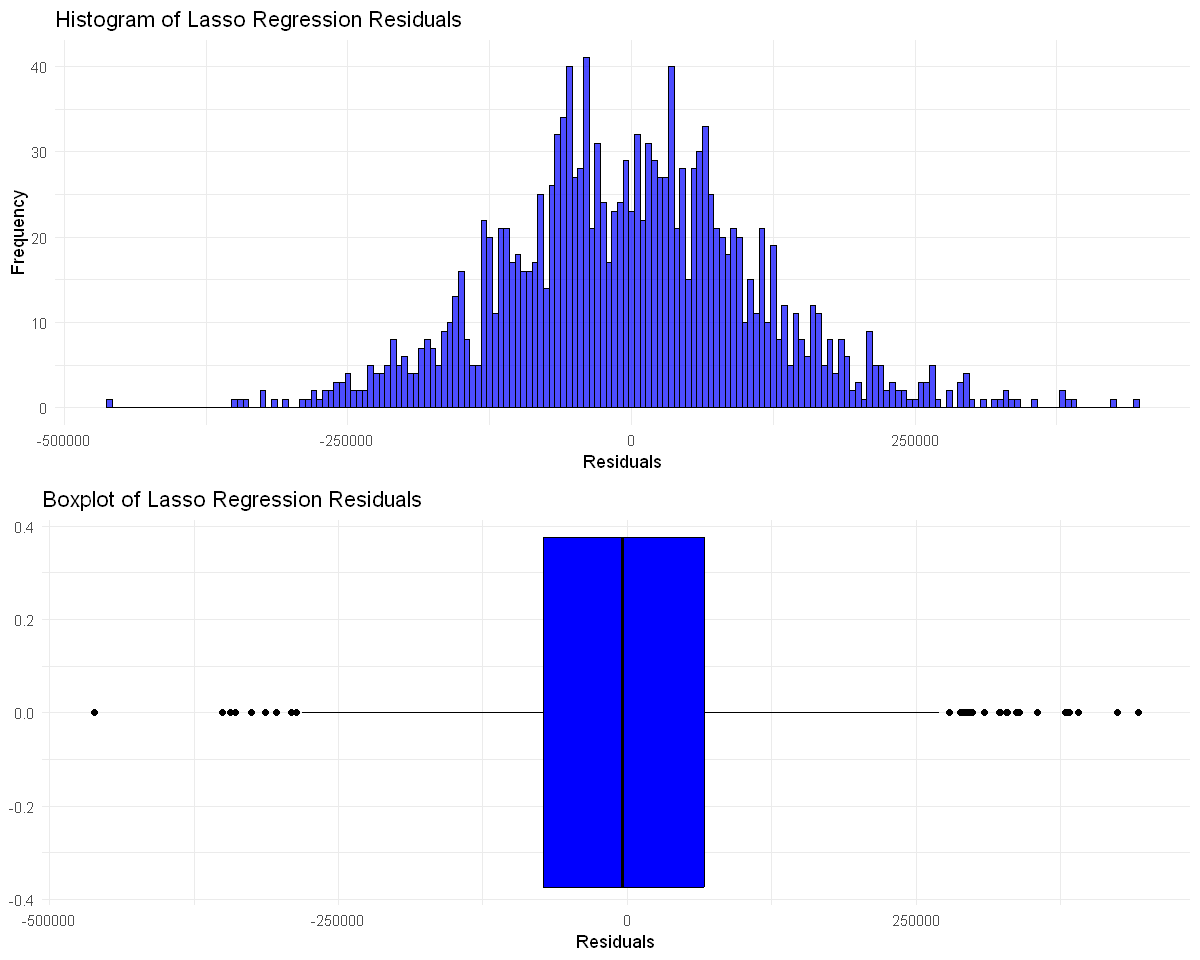

In [64]:
#Plotting the histogram for lasso residuals
lasso_1 <- ggplot(combine_lasso, aes(x = resi)) +
  geom_histogram(binwidth = 5000, fill = "blue", color = "black", alpha = 0.7) +
  labs(title = "Histogram of Lasso Regression Residuals",
       x = "Residuals",
       y = "Frequency") +
  theme_minimal()

#Plotting the boxplot for lasso residuals
lasso_2 <- ggplot(combine_lasso, aes(y = resi)) +
  geom_boxplot(fill = "blue", color = "black") +
  labs(title = "Boxplot of Lasso Regression Residuals",
       y = "Residuals") +
  theme_minimal() +
  coord_flip()

grid.arrange(lasso_1, lasso_2)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


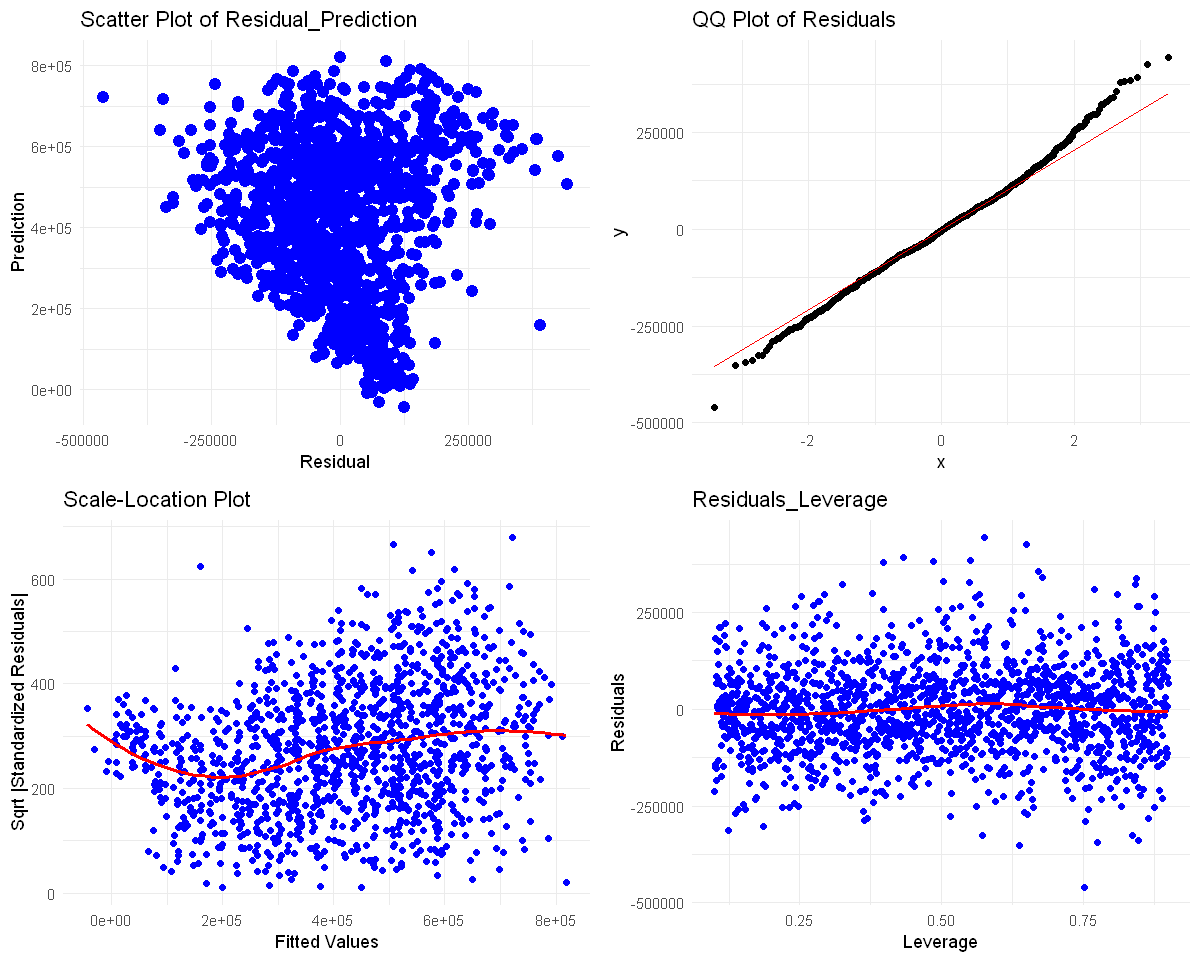

In [65]:
#Plotting the scatter plot for residual_prediction
point_lasso <- ggplot(data=combine_lasso, aes(x = resi, y = pred)) +
  geom_point(color = "blue", size = 3) +
  labs(title = "Scatter Plot of Residual_Prediction", 
       x = "Residual", 
       y = "Prediction") +
  theme_minimal()

#Plotting the qqplot for residual
qq_lasso <- ggplot(combine_lasso, aes(sample = resi)) +
  stat_qq() +
  stat_qq_line(col = "red") +
  labs(title = "QQ Plot of Residuals") +
  theme_minimal()

#Plotting the scatter plot for scale location
combine_lasso$sqrt_resi <- sqrt(abs(combine_lasso$resi))
scale_lasso <- ggplot(combine_lasso, aes(x = pred, y = sqrt_resi)) +
  geom_point(color = "blue") +
  geom_smooth(method = "loess", se = FALSE, color = "red") +
  labs(title = "Scale-Location Plot", x = "Fitted Values", y = "Sqrt |Standardized Residuals|") +
  theme_minimal()

#Plotting the scatter plot for residual_leverage
combine_lasso$leverage <- seq(0.1, 0.9, length.out = nrow(combine_lasso))
leverage_lasso <- ggplot(combine_lasso, aes(x = leverage, y = resi)) +
  geom_point(color = "blue") +
  geom_smooth(method = "loess", se = FALSE, color = "red") +
  labs(title = "Residuals_Leverage", x = "Leverage", y = "Residuals") +
  theme_minimal()

grid.arrange(point_lasso, qq_lasso, scale_lasso, leverage_lasso)

In [66]:
#Breush Pagan to evaluate the residuals
bptest(residual_lasso ~ X_test)


	studentized Breusch-Pagan test

data:  residual_lasso ~ X_test
BP = 151.03, df = 38, p-value = 2.081e-15


Observation
- We can see that like backward stepwise regression, the L1 model has a smaller MAE but higher MSE and RMSE. 
- Compared to the L2 model, L1 model has higher MAE but lower MSE and RMSE
- The boxplot and the histogram of the residuals signify that the mean of the residuals is around 0 similar to the normal linear regression
- The scatter plot of the residuals visualize a pattern of the residuals. Also the line for the scale location plot is not as smooth compared to the LR. The upward region of the QQ plot also shows an upward trend
- The Breush Pagan test for Lasso Regression also shows a higher value compared to the linear regression one 

### Elastic Net Model

Next we'll do the Elastic Net MOdel. In this code we'll use auto selection for the lambda and do an automatic cross validation to cross validate the model

In [67]:
#Train the Elastic Net model
elastic_net_model <- glmnet(X, y, alpha = 0.5)  # alpha = 0.5 for Elastic Net (between Ridge and Lasso)

#Selecting the optimal lambda using cross-validation
cv_elastic_net <- cv.glmnet(X, y, alpha = 0.5)
best_lambda_elastic_net <- cv_elastic_net$lambda.min

#Training the Elastic Net model with the best lambda
elastic_net_model_best <- glmnet(X, y, alpha = 0.5, lambda = best_lambda_elastic_net)
print(elastic_net_model_best)


Call:  glmnet(x = X, y = y, alpha = 0.5, lambda = best_lambda_elastic_net) 

  Df  %Dev Lambda
1 39 72.66  143.3


In [68]:
#Counting the residual toward the train data
predictions_lc = predict(elastic_net_model_best, X_test)
residuals_lc = test$selling_price - predictions_lc

#Calculate MAE, MSE, and RMSE
mae_lc = mean(abs(residuals_lc))
mse_lc = mean(residuals_lc^2)
rmse_lc = sqrt(mse_lc)

#Print the MAE, MSE, and RMSE
print(paste("Variance: ", var(test$selling_price)))
print(paste("Mean Absolute Error: ", mae_lc))
print(paste("Mean Squared Error: ", mse_lc))
print(paste("Root Mean Squared Error: ", rmse_lc))

[1] "Variance:  45579011008.7448"
[1] "Mean Absolute Error:  89566.4516341388"
[1] "Mean Squared Error:  13192731604.4758"
[1] "Root Mean Squared Error:  114859.616943797"


In [69]:
#Counting the train residuals
residual_elastic = test$selling_price - predict(elastic_net_model_best, X_test)
#Counting the test residuals
predict_elastic= predict(elastic_net_model_best, X_test)

#Combining both residuals into one dataframe
combine_elastic <- cbind(residual_elastic, predict_elastic)
colnames(combine_elastic) <- c('resi', 'pred')
combine_elastic <- as.data.frame(combine_elastic)

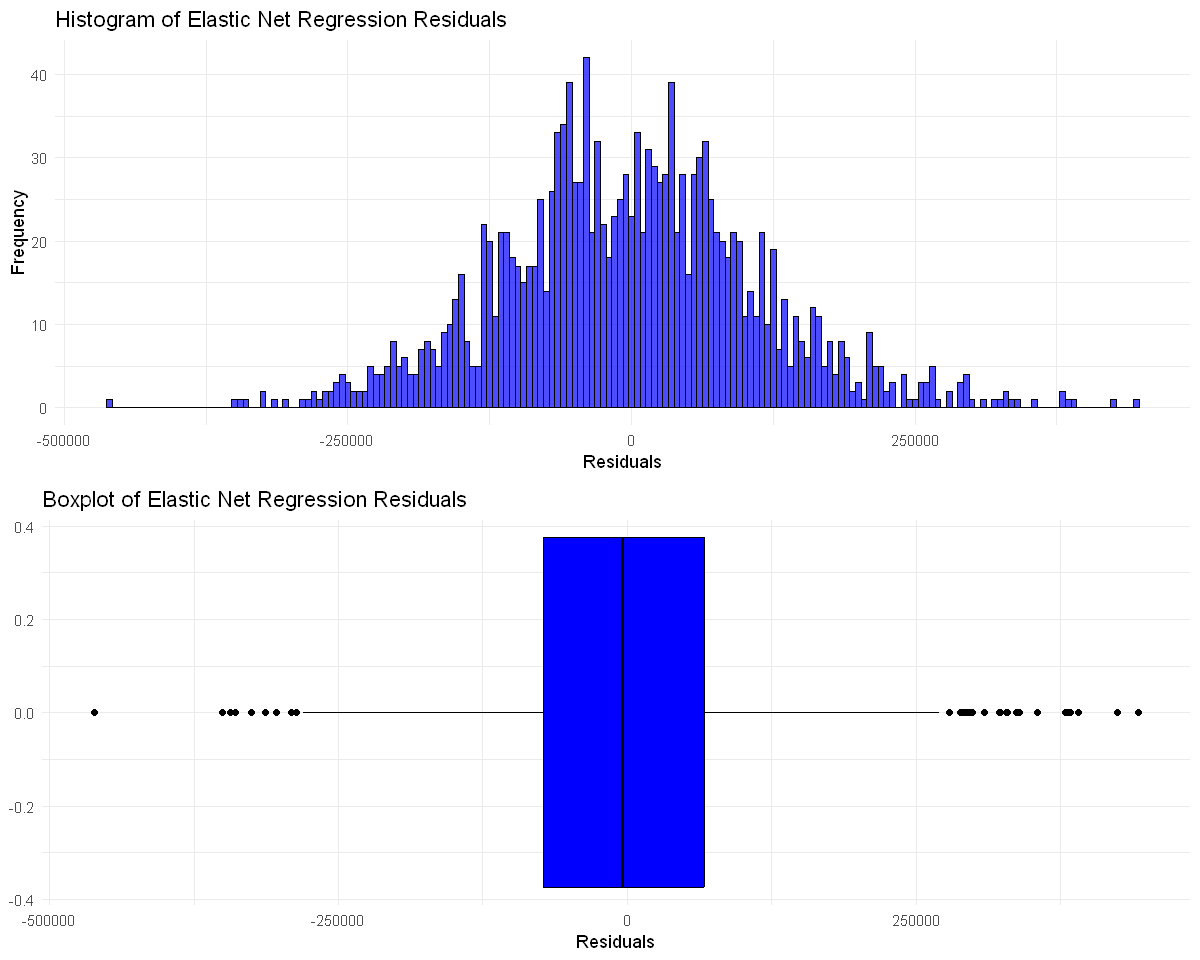

In [70]:
#Plotting the histogram for elastic net residuals
elastic_1 <- ggplot(combine_elastic, aes(x = resi)) +
  geom_histogram(binwidth = 5000, fill = "blue", color = "black", alpha = 0.7) +
  labs(title = "Histogram of Elastic Net Regression Residuals",
       x = "Residuals",
       y = "Frequency") +
  theme_minimal()

#Plotting the boxplot for elastic net residuals
elastic_2 <- ggplot(combine_elastic, aes(y = resi)) +
  geom_boxplot(fill = "blue", color = "black") +
  labs(title = "Boxplot of Elastic Net Regression Residuals",
       y = "Residuals") +
  theme_minimal() +
  coord_flip()

grid.arrange(elastic_1, elastic_2)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


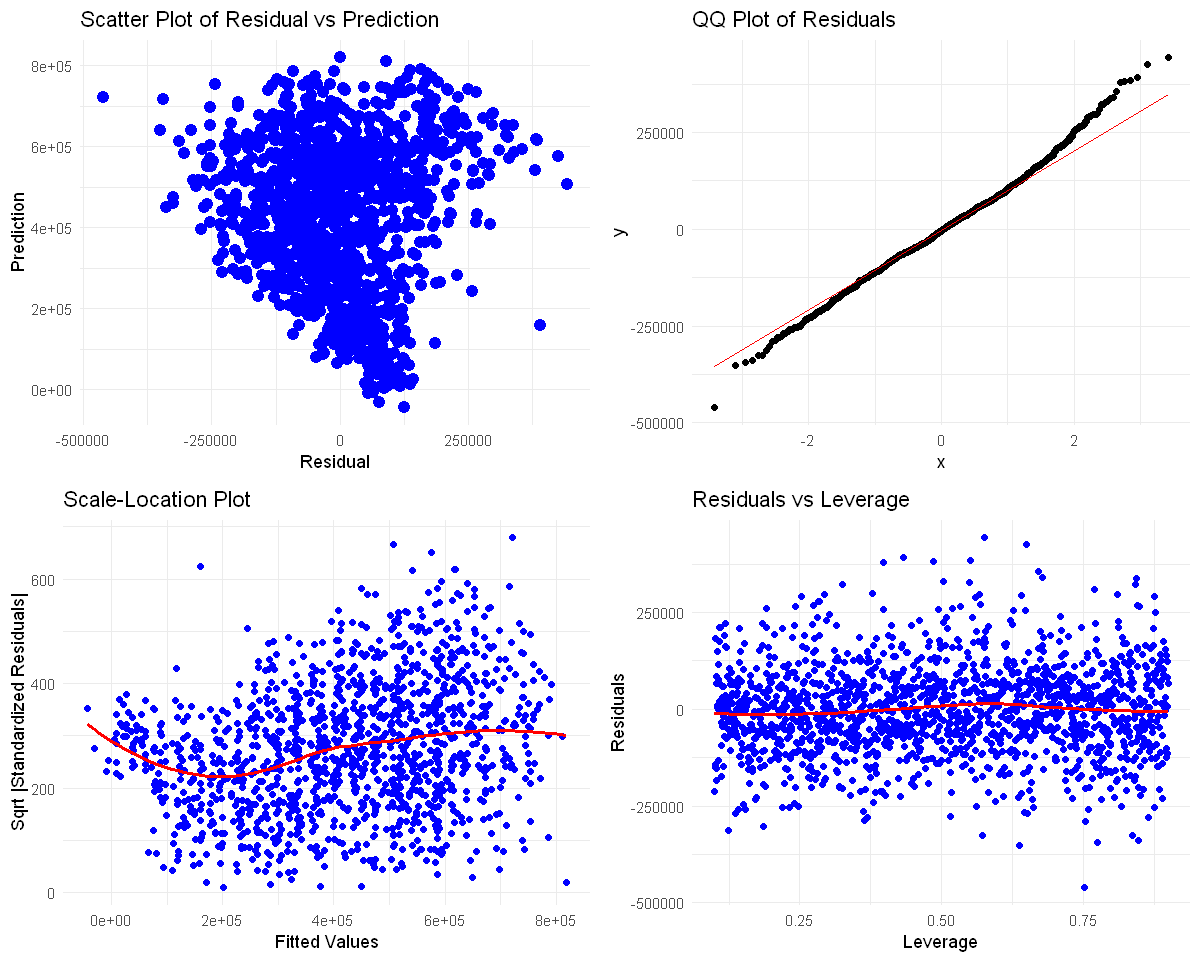

In [71]:
#Plotting the scatter plot for residual_prediction
elastic_point <- ggplot(data=combine_elastic, aes(x = resi, y = pred)) +
  geom_point(color = "blue", size = 3) +
  labs(title = "Scatter Plot of Residual vs Prediction", 
       x = "Residual", 
       y = "Prediction") +
  theme_minimal()

#Plotting the qqplot for residual
elastic_qq <- ggplot(combine_elastic, aes(sample = resi)) +
  stat_qq() +
  stat_qq_line(col = "red") +
  labs(title = "QQ Plot of Residuals") +
  theme_minimal()

#Plotting the scatter plot for scale location
combine_elastic$sqrt_resi <- sqrt(abs(combine_elastic$resi))
elastic_scale <- ggplot(combine_elastic, aes(x = pred, y = sqrt_resi)) +
  geom_point(color = "blue") +
  geom_smooth(method = "loess", se = FALSE, color = "red") +
  labs(title = "Scale-Location Plot", x = "Fitted Values", y = "Sqrt |Standardized Residuals|") +
  theme_minimal()

#Plotting the scatter plot for residual_leverage
combine_elastic$leverage <- seq(0.1, 0.9, length.out = nrow(combine_elastic))
elastic_leverage <- ggplot(combine_elastic, aes(x = leverage, y = resi)) +
  geom_point(color = "blue") +
  geom_smooth(method = "loess", se = FALSE, color = "red") +
  labs(title = "Residuals vs Leverage", x = "Leverage", y = "Residuals") +
  theme_minimal()

grid.arrange(elastic_point, elastic_qq, elastic_scale, elastic_leverage)

In [72]:
#Breush Pagan to evaluate the residuals
bptest(residuals_lc ~ X_test)


	studentized Breusch-Pagan test

data:  residuals_lc ~ X_test
BP = 151.03, df = 38, p-value = 2.081e-15


Observation
- We can see that elastic net model actually has lower MAE than LR but higher than L1 or L2. 
- Elastic has a higher MSE and RMSE compared to L1 but lower than L2 and LR
- The boxplot and the histogram of the residuals signify that the mean of the residuals is around 0 similar to the normal linear regression
- The scatter plot of the residuals visualize a pattern of the residuals. Also the line for the scale location plot is not as smooth compared to the LR. The upward region of the QQ plot also shows an upward trend
- The Breush Pagan test for Elastic Net Regression also shows a higher value compared to the linear regression one 

## Analysis of the model comparison

- The forward stepwise regression didn't actually change the model.
Seeing the summary and the metrics. All of the attributes are the same also it has the same metrics as LR therefore it's basically the same as vanilla linear regression. There's no reason to use the forward stepwise regression

- The backward stepwise regression discarded an attribute and has better metric from the r square
The backward stepwise regression actually did a feature selection in which it discarded the torque variable. Because of that we're able to see a better R square and MAE but the RMSE and MSE is higher. The residuals analysis is also the same as linear regression

- The regularization method didn't make the model better by a lot and actually it perform worse when the residuals is evaluated
All form of regularization only decrease the MAE and make the RMSE or MSE higher. We can also see that the residuals graph is actually having a pattern when compared to the normal linear regression. The Breusch Pagan test also yields a worse value

- The residuals analysis shows somewhat of a pattern in all of the regularization model compared to the normal linear regression model. The Breusch Pagan test also shows a higher value although it's still below 0.05 so it still shows there's no homoscedasticity present in all the model variations

The reason why when compared to vanilla linear regression, all the other model be it backward or all forms of regularization is that 

- MAE as a metric measure the average of the absolute difference between the actual and predicted values in the dataset. This metric is more geared toward the overal error of the model. MAE estimates median and is more robust towards outlier. Therefore a lower MAE value means that the model will be able to predict the typical cases more easily

- MSE/RMSE as a metric will square the error before averaging them therefore gives more importance to the larger errors. Therefore this metrics is more sensitive to the outliers. A lower MSE/RMSE values means that the model will be able to predict outliers more easily.


## 5. Results and discussion <a class="anchor" id="sec_6"></a>

## Model Selection

Based from the analysis, the model selected will be the regular Linear Regression model. The reasoning for this decision is

- Although a lower MAE means that the linear regression model will not perform well toward the typical cases, it still has a higher MSE and RMSE. In used car prices prediction, there will be outlier present to the model and it will be a lot. Even in the EDA we found that there's a lot of outlier in the selling price variable therefore a model that perform well towards outlier is preferable rather than a model that perform well towards typical cases. Not only that the difference of values in MAE, MSE, and RMSE is not that extreme so linear regression will still be able to perform well toward typical cases (Linear Regression has 0.72 R squared value so it will do well toward 70% of the cases)
- Linear regression model is a simple model that won't take a lot of computational power and is well understood so it will be easier to tweak and explain towards other and will be able to easily fix any problems that arise
- The residuals also looks better in linear regression visualization. Although the Brausch Pagan test shows that none of the model has homoscedasticity present, based from visual it's clear that the scale location and residual prediction scatter plot is better in linear regression variation since it didn't show any clustering of the residual or pattern. The QQ plot also shows a linear one compared to the regularization one where the qq plot has an upward tendency

To select the 5 most important attributes that we will use for the final model. We'll use the varImp function to measure the importance of the predictor. VarImp uses the absolute value of the t statistics to rank the predictor

In [73]:
#Applying the varImp function to linear regression model
var = arrange(varImp(lm_car))
#Arranging the predictor in descending order
var <- var %>% 
    arrange(desc(Overall))
#Showing the top 10 result
head(var, 10)

,Overall
,<dbl>
engine,26.340878
seats7,10.458610
ownerSecond Owner,6.753315
transmissionManual,6.637240
fuelDiesel,5.844714
fuelPetrol,4.558701
seats6,4.262296
fuelLPG,3.925741
ownerThird Owner,3.694450


As we can see from the varImp result, top 10 predictor is engine, 7 seat, 2nd owner, manual transmission, diesel fuel, petrol fuel, 6 seat, lpg fuel, third owner, and individual seller. In addition to the P value from the summary of lm_car 5 attributes will be selected which is

Engine, Fuel, Seller Type, Transmission, Owner, and Seats. The reasoning for this is that these 7 attribute that are selected because all of these attributes has a p value of lower than 0.01 even going to > e-10 range. The varImp function also yields similar results. The categorical variable although not all value has a high enough importance 

# Final Model

In this section we'll build the final model which is the linear regression model with 5 attributes which is Engine, Fuel, Seller Type, Transmission, Owner then we'll evaluate the model again based on the metrics previously explained.

In [84]:
#Modelling the Linear Regression
lm_final = lm(selling_price~ engine + fuel + seller_type + transmission + owner +  seats, data = train) 
#Getting the specifics of the linear regression from summary function
summary(lm_final) #Review the results


Call:
lm(formula = selling_price ~ engine + fuel + seller_type + transmission + 
    owner + seats, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-524907 -107464   -5154  105996  610624 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  120503.69   38980.49   3.091  0.00201 ** 
engine                          382.95      15.96  24.000  < 2e-16 ***
fuelDiesel                    55776.57   30870.59   1.807  0.07088 .  
fuelLPG                      -60024.29   50010.71  -1.200  0.23013    
fuelPetrol                    28577.26   30645.84   0.933  0.35114    
seller_typeIndividual        -21105.70    8916.39  -2.367  0.01798 *  
seller_typeTrustmark Dealer   54615.63   18143.76   3.010  0.00263 ** 
transmissionManual          -145025.88   11069.42 -13.101  < 2e-16 ***
ownerFourth & Above Owner   -231407.95   20837.53 -11.105  < 2e-16 ***
ownerSecond Owner           -148688.82    6546.27 -22.714  < 2e-16

We got the model and the evaluation of the model. The value of P-value is the same as our original linear regresssion and the R-squared is reduced significantly. This means that the model is able to reject the null hypothesis but doesn't generalize well to unseen data. 

Next we'll evaluate the MAE MSE and RMSE

In [85]:
# Use the predict() function to make predictions on the training data then calculate the residuals
predictions_final = predict(lm_final, test)
residuals_final = test$selling_price - predictions_final

# Calculate MAE, MSE, RMSE
mae_final = mean(abs(residuals_final))
mse_final = mean(residuals_final^2)
rmse_final = sqrt(mse_final)
variance = var(test$selling_price)

# Print the results
print(paste("Variance: ", variance))
print(paste("Mean Absolute Error: ", mae_final))
print(paste("Mean Squared Error: ", mse_final))
print(paste("Root Mean Squared Error: ", rmse_final))

[1] "Variance:  45579011008.7448"
[1] "Mean Absolute Error:  131305.702288771"
[1] "Mean Squared Error:  27818841959.0143"
[1] "Root Mean Squared Error:  166789.81371479"


We see here that the MAE MSE and RMSE is worse than the other models meaning that the model doesn't perform well after feature extraction.

Next we'll do a residual analysis

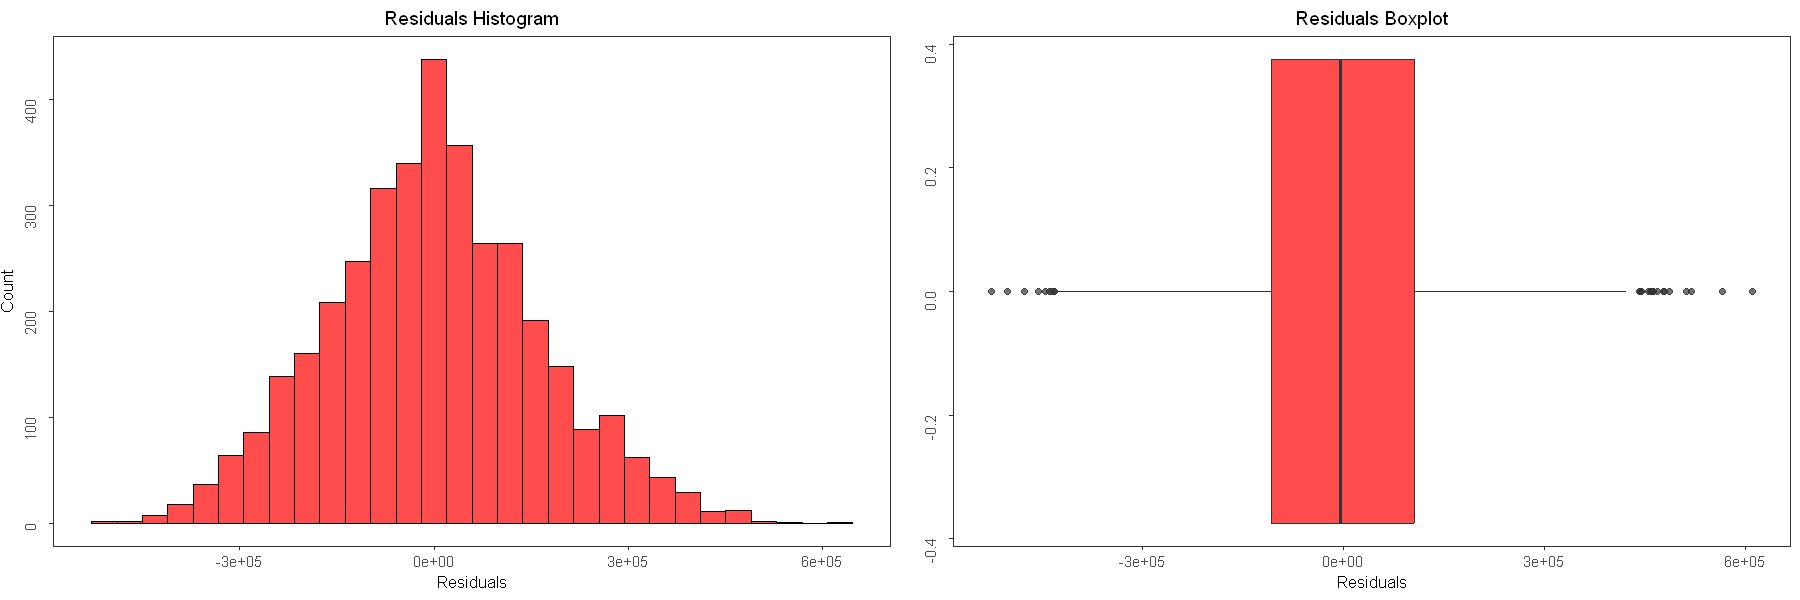

In [86]:
options(repr.plot.width = 15, repr.plot.height = 5)

#Plotting the histogram for the residual
lm_hist <- ggplot(data = train, aes(x = lm_final$residuals)) + 
    geom_histogram(bins=30, alpha=0.7, color="black", fill="red") + 
    labs(x="Residuals", y ="Count") +
    ggtitle("Residuals Histogram") + 
    theme_bw() + 
    theme(axis.title = element_text(size = 10),
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.title.y = element_text(vjust = 4), 
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

#Plotting the boxplot for the residual
lm_box <- ggplot(data= train, aes(lm_final$residuals)) + 
    geom_boxplot(alpha=0.7, fill="red") + ylab("") + xlab("Residuals") +
    theme_bw() + 
    ggtitle("Residuals Boxplot") + 
    theme(axis.title = element_text(size = 10), 
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

grid.arrange(lm_hist, lm_box, ncol=2)

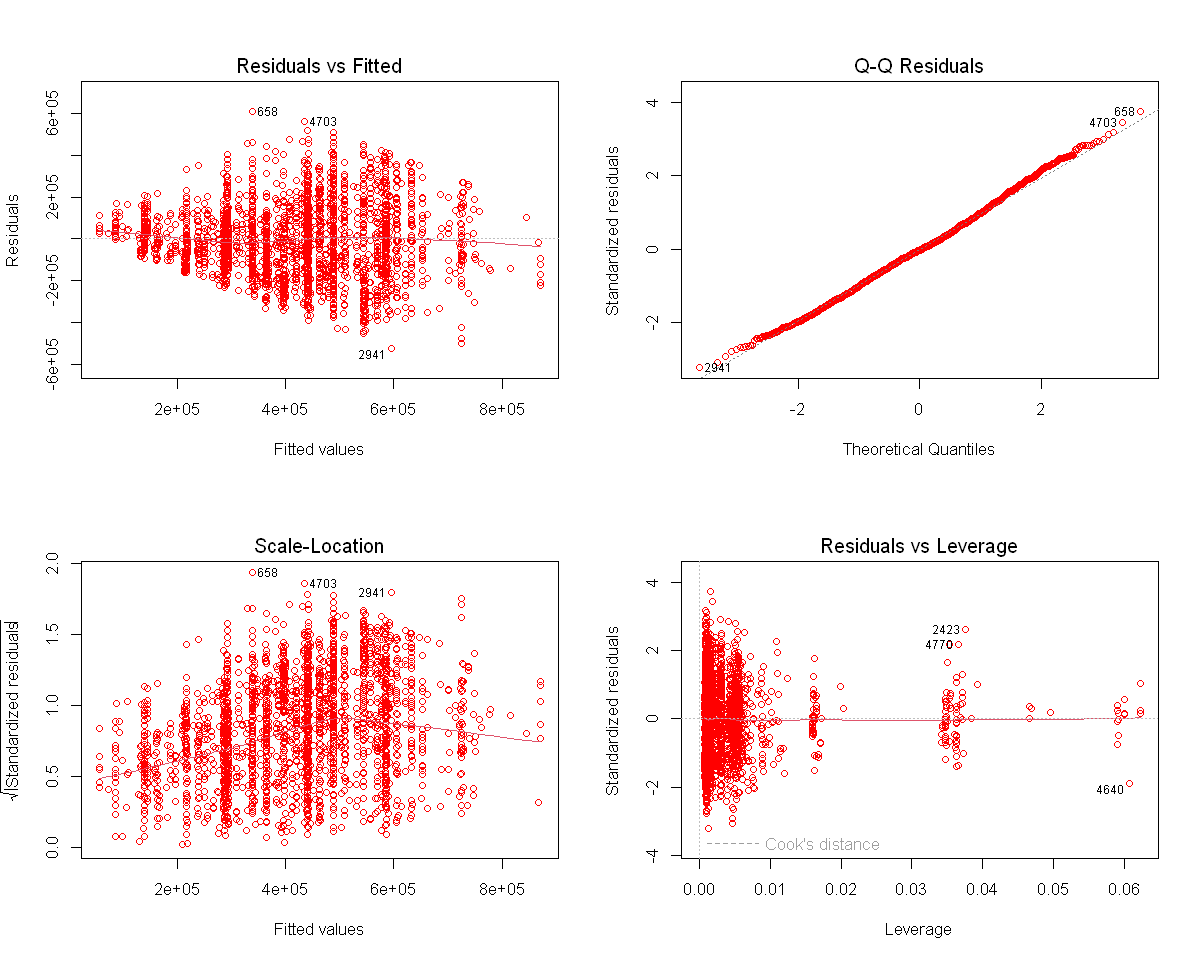

In [87]:
options(repr.plot.width = 10, repr.plot.height = 8)

#Plotting the scatterplot for residuals vs fitted, scale vs location, residual vs leverage. And the qq plot for residuals
par(mfrow=c(2,2))
plot(lm_final, col='red')

In [88]:
#Breush Pagan to evaluate the residuals
bptest(residuals_final ~ X_test)


	studentized Breusch-Pagan test

data:  residuals_final ~ X_test
BP = 151.03, df = 38, p-value = 2.081e-15


From the visuals of the residuals, the plot of the residuals looks different than the normal linear regression and it looks like there's cluster present, suggesting homoscedacity is present. This is countered by the Breush Pagan test that yields a result lower than 0.05 therefore proving that there are no homoscedacity present.

This result prove that the best model the feature selected is not enough for the model to perform well. Next up let's try adding the year features. From the coefficient analysis, the year feature has some better performing category but it's p value is not low enough. Although since the model have a lot of variance in it's target variable adding another predictor could help the model generalize better which will increase the R squared.


In [89]:
#Modelling the Linear Regression
lm_final2 = lm(selling_price~ engine + fuel + seller_type + transmission + owner + seats + year, data = train) 
#Getting the specifics of the linear regression from summary function
summary(lm_final2) #Review the results


Call:
lm(formula = selling_price ~ engine + fuel + seller_type + transmission + 
    owner + seats + year, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-453835  -75556     -69   72212  409831 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 -103340.0   119541.8  -0.864 0.387389    
engine                          350.0       11.2  31.262  < 2e-16 ***
fuelDiesel                   138616.3    21548.6   6.433 1.42e-10 ***
fuelLPG                      129270.5    34950.7   3.699 0.000220 ***
fuelPetrol                    91033.5    21361.8   4.262 2.08e-05 ***
seller_typeIndividual        -19175.6     6219.2  -3.083 0.002063 ** 
seller_typeTrustmark Dealer   26651.8    12825.9   2.078 0.037783 *  
transmissionManual           -51765.4     7905.6  -6.548 6.66e-11 ***
ownerFourth & Above Owner    -29783.8    15548.7  -1.916 0.055506 .  
ownerSecond Owner            -33561.3     4933.7  -6.803 1.20e-11 ***

In [94]:
# Use the predict() function to make predictions on the training data then calculate the residuals
predictions_final2 = predict(lm_final2, test)
residuals_final2 = test$selling_price - predictions_final2

# Calculate MAE, MSE, RMSE
mae_final2 = mean(abs(residuals_final2))
mse_final2 = mean(residuals_final2^2)
rmse_final2 = sqrt(mse_final2)
variance = var(test$selling_price)

# Print the results
print(paste("Variance: ", variance))
print(paste("Mean Absolute Error: ", mae_final2))
print(paste("Mean Squared Error: ", mse_final2))
print(paste("Root Mean Squared Error: ", rmse_final2))

[1] "Variance:  45579011008.7448"
[1] "Mean Absolute Error:  89635.8071500386"
[1] "Mean Squared Error:  13231587995.6321"
[1] "Root Mean Squared Error:  115028.639892994"


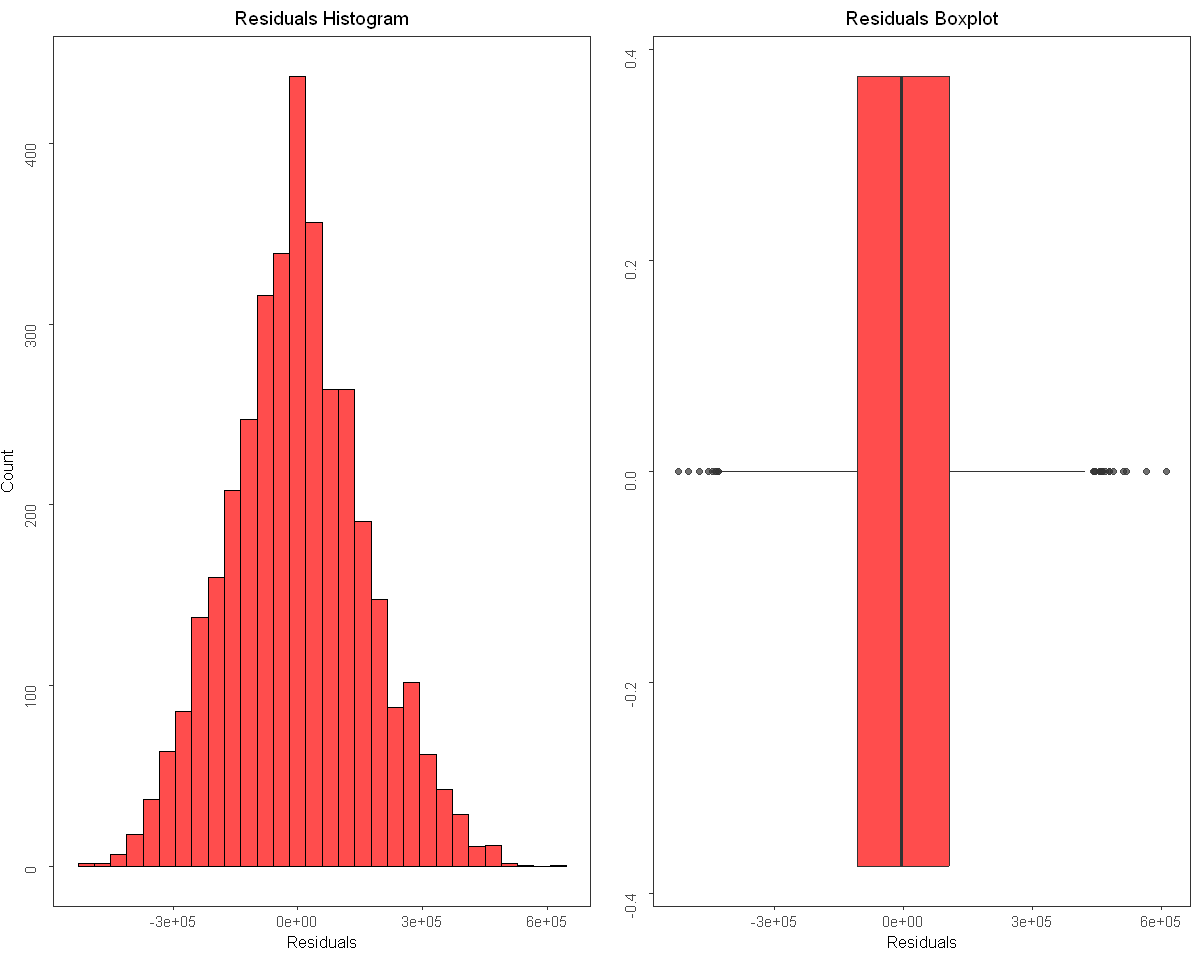

In [91]:
#Plotting the histogram for the residual
lm_hist2 <- ggplot(data = train, aes(x = lm_final2$residuals)) + 
    geom_histogram(bins=30, alpha=0.7, color="black", fill="red") + 
    labs(x="Residuals", y ="Count") +
    ggtitle("Residuals Histogram") + 
    theme_bw() + 
    theme(axis.title = element_text(size = 10),
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.title.y = element_text(vjust = 4), 
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

#Plotting the boxplot for the residual
lm_box2 <- ggplot(data= train, aes(lm_final2$residuals)) + 
    geom_boxplot(alpha=0.7, fill="red") + ylab("") + xlab("Residuals") +
    theme_bw() + 
    ggtitle("Residuals Boxplot") + 
    theme(axis.title = element_text(size = 10), 
          plot.title = element_text(hjust = 0.5, size = 11.5),
          axis.text.y = element_text(angle = 90, vjust = 3),
          panel.grid = element_blank()
         )

grid.arrange(lm_hist, lm_box, ncol=2)

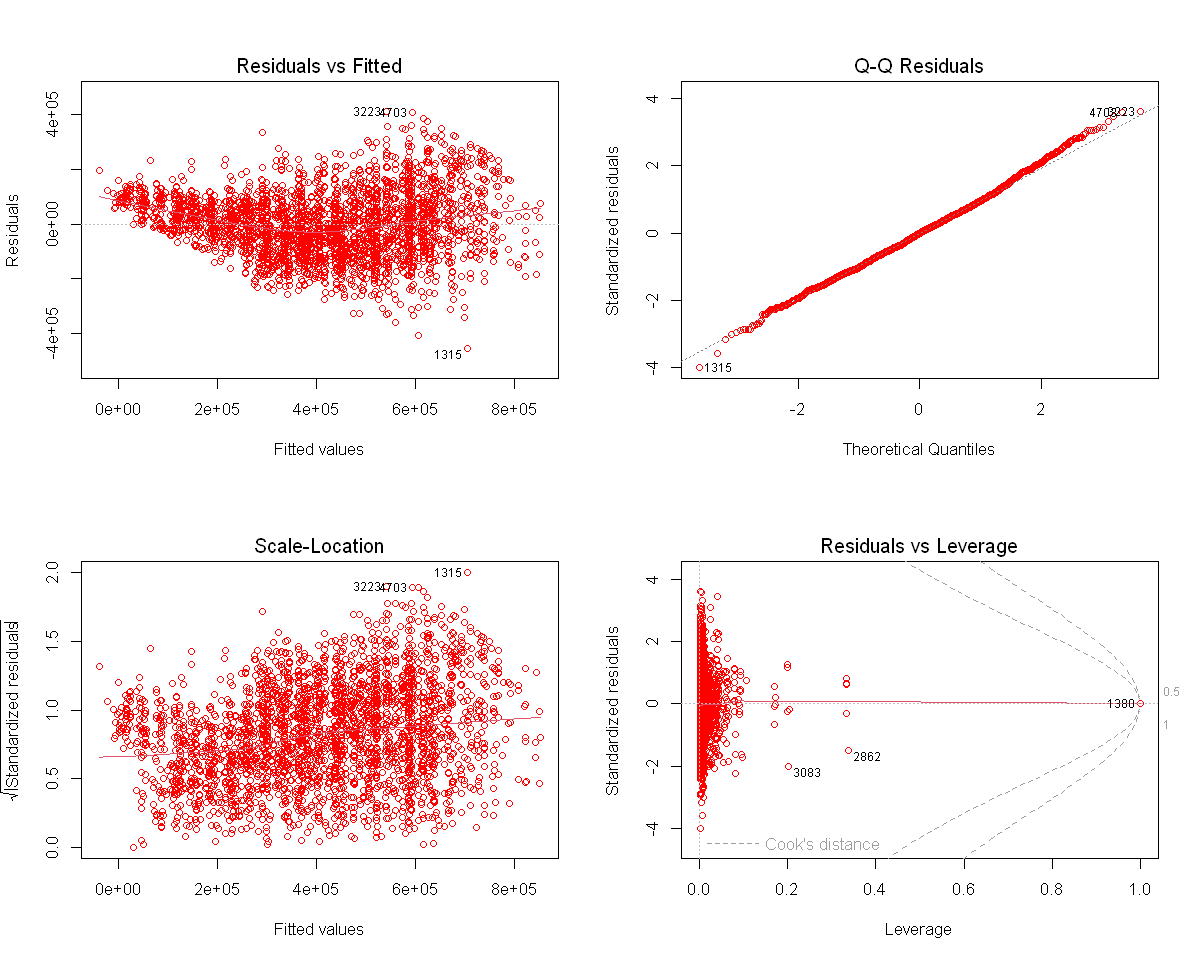

In [92]:
options(repr.plot.width = 10, repr.plot.height = 8)

#Plotting the scatterplot for residuals vs fitted, scale vs location, residual vs leverage. And the qq plot for residuals
par(mfrow=c(2,2))
plot(lm_final2, col='red')

In [93]:
#Breush Pagan to evaluate the residuals
bptest(residuals_final2 ~ X_test)


	studentized Breusch-Pagan test

data:  residuals_final2 ~ X_test
BP = 151.03, df = 38, p-value = 2.081e-15


Now we see after adding the year feature, the R squared and adjusted R squared value is now the same with the original model. The MAE MSE RMSE value also perform better and is closer to the original model value. The visual for the residuals is also looks better. So we can conclude that by adding year feature the model performs better.

## INFERENCE

In this section we'll discuss the model itself and why the selected predictor is important to the model

The basic formula for Linear Regression is 

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon$$


With the coefficient we got from the model, the actual formula for the model became

selling_price = -103340.0 + 350 $\cdot$ engine + 138616.3 $\cdot$ fuel_diesel + 129270.5 $\cdot$ fuel_lpg + 91033.5 $\cdot$ fuel_petrol - 19175.6 $\cdot$ seller type_individual + 26651.8 $\cdot$ seller type_Trustmark Dealer - 51765.4 $\cdot$ transmission_Manual - 29783.8 $\cdot$ owner_Fourth & above - 33561.3 $\cdot$ owner_second - 237428.8 $\cdot$ year_1998 - 242360.0 $\cdot$ year_1999 ...

According to the model statistics and the coeffecient we can conclude that

Residuals = The residual are well centred around 0. There are nearly equal value of 1st and 3rd quartile according to the boxplot indicating an even distribution fo the residuals. The Brausch Pagan test also give out a score lower than 0.05 which indicates a good score.

$R^2$ = The value for the $R^2$ is 0.4 before we added the year feature and then it became 0.7 after we added the year feature. $R^2$ is a metric that evaluates the proportion of the variance in the dependent variable that is predictable from the independent variables, this means that $R^2$ evaluates how well the model can represent the target variable. The reason why the model has a low $R^2$ can be surmised because based from the EDA we can see that the before we deleted the outlier for the target variable, the range of the target variable is really wide. Even after the outliers are deleted. The range for the target variable is still large from 300k$ to 1million$. The model itself already has proven that it could predict well because of the lower p-value but because it has a low variance, the model will not generalize well to a lot of cases. This is why adding another significant but not powerful features like year can be beneficial to raise the R squared and make the model generalize well to a lot more cases.

P-value = The p-value indicates if the model is able to reject the null hypothesis. The low value of this p-value means that the model is able to reject the null hypothesis. Our model has a very small p-value of 2.2e-16 which means that the model can definitely reject the null hypothesis

F-statistics = F-statistics compares the model with no predictor and the model with the predictor that we added. This metric evaluates how relevant the predictor is to the quality of the model. We see that our model have a high score of F-statistics with 265 which means that the predictor given to the model is important so that the model can better predict the target variable. We can see that before the year feature is added, the F-statistics is only 209. 209 is by no means a bad value but we see that after adding the year variable the F statistics of the model became better indicating that the year attribute is also an important predictor for the model

Coefficients : Based from the summary we can see that all the original predictor (Engine, Fuel, Seller Type, Transmission, Owner, and Seats) have good coefficients (lower than 0.01). The varimp also was able to list that the 10 important predictor is from these features. We'll discuss why each features are important below

- Engine = The engine size or capacity (often measured in CCs or horsepower) directly impacts a car's performance, fuel efficiency, and overall desirability.
- Fuel = The type of fuel a car uses (e.g., petrol, diesel, LPG, electric) affects running costs, environmental impact, and market demand.
- Seller Type = The seller type (e.g., individual, dealer, trustmark dealer) can influence buyer trust and perceived value.
- Transmission = The type of transmission (manual or automatic) affects driving experience, fuel efficiency, and maintenance costs.
- Owner = The number of previous owners provides insights into the car's history and potential wear and tear.
- Seats = The number of seats (e.g., 4, 5, 7-seaters) determines a car’s utility for different buyers.

Now for the enigmatic feature addition which we added the last which is year that increases the R-squared and F-statistics, also reducing MAE, MSE, and RMSE but its actually not one of the top performing features based from the coefficient. The model of used car prices as mentioned above have a high variance with its target variable (selling price). This means that the model needs a predictor that is able to encompass the large variance the prices could be. The year features, although a lot of its coefficients didn't go below 0.05 is varied enough that the model could use what year the car is produced to help it capture the large variance the prices have. We can see that the p value didn't drop although we added the year variable because the model itself is already good enough to reject the null hypothesis. The first final model is only lacking to predict the huge variance the target variable. By adding the year features that is wide enough, the model is now suited to predict the large variance the target value has.


## 6. Conclusion

In this section we'll summarize everything that we've done and the important findings

### Exploratory Data Analysis

- Originally the dataset has 8128 values per column with 13 collumns
- From the summary it is found that these columns has NaN values mileage = 221, engine = 221, max power = 215, torque = 222, and seats = 221. These rows are dropped
- After correction of anomalies and outliers the value has a normal distributio nand perform well towards the model which shows the importance of anomalies correction
- The boxplot plotting was able to show outliers value from the categorical variable and continuous variable and help to decide which value are not important
- The correlation analysis helped to see if engine and max power are correlated or not. In the end max power is deleted since it has a large correlation value
- From the time series for continuous variable, we can see that all attribute follow the same trend
- The categorical time series also mostly shows that the attributes follow the same trend. But some values didn't start from the beginning and those values shows volatility in the trend

### Prediction Model

- Based from the model comparison we've found that the best model is Linear Regression compared to the regularization and stepwise regression. This is concluded because from all the model the difference is not that extreme and linear regression is a more simplified model so it will be much more easily decipherable and computationaly not taxing
- The features selected at first are (Engine, Fuel, Seller Type, Transmission, Owner, and Seats) we found that with only these features the model perform worse than expected therefore we added another features which is year. After adding the year feature the model performs better.
- The year variable helps the model to capture the large variance the target variable has


### Inference

- From the inference we see that by combining the varImp function and summary we were able to decide which features are important to the model
- Although the important features were able to be collected, doesn't mean that the features will enable the model to work smoothly
- In this case, it's because the high variance of the target variable. The important features were able to grasp the relationship between the predictor and target value but weren't able to generalize well enough to the high variance
- To recitify this, another attribute was added which is the year attribute. It's the next most powerful attribute although it's member doesn't have a p-value of below 0.01. It has member that has p-value of below 0.05 so it's deemed powerful enough
- With adding the the year variable, we can see the model now perform well enough to the large variance data and able to rectify the r square and f statistics without degrading the pvalue. Proving that the year variable is also an important features for the model.

Formula for the linear regression model, written again

Basic linear regression formula

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon$$

selling_price = -103340.0 + 350 $\cdot$ engine + 138616.3 $\cdot$ fuel_diesel + 129270.5 $\cdot$ fuel_lpg + 91033.5 $\cdot$ fuel_petrol - 19175.6 $\cdot$ seller type_individual + 26651.8 $\cdot$ seller type_Trustmark Dealer - 51765.4 $\cdot$ transmission_Manual - 29783.8 $\cdot$ owner_Fourth & above - 33561.3 $\cdot$ owner_second - 237428.8 $\cdot$ year_1998 - 242360.0 $\cdot$ year_1999 ...



## 7. References <a class="anchor" id="sec_8"></a>

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). An introduction to statistical learning: With applications in R. Springer.

Katadata. (2023, March 15). Ini Pertumbuhan Jumlah Mobil di Indonesia 10 Tahun Terakhir. Databoks. https://databoks.katadata.co.id/datapublish/2023/03/15/ini-pertumbuhan-jumlah-mobil-di-indonesia-10-tahun-terakhir

Gerena, E. A. (2020). A study on the factors influencing the acceptance of mobile payments: A case study on the introduction of a mobile payment application for use at a large event space (Master’s thesis, Rochester Institute of Technology). RIT Scholar Works. https://repository.rit.edu/cgi/viewcontent.cgi?article=12220&context=theses

Penn State Eberly College of Science. (n.d.). 3.2.5 - Outliers. STAT 200: Elementary Statistics. https://online.stat.psu.edu/stat200/lesson/3/3.2#:~:text=We%20can%20use%20the%20IQR,add%20this%20value%20to%20Q3.

User utreera. (2014, March 10). How to interpret a QQ plot? Cross Validated. https://stats.stackexchange.com/questions/101274/how-to-interpret-a-qq-plot

R-Bloggers. (2016, January 18). How to Detect Heteroscedasticity and Rectify It. https://www.r-bloggers.com/2016/01/how-to-detect-heteroscedasticity-and-rectify-it/

Fractalbass. (2020, April 5). Building a Model with Stepwise Regression. RPubs. https://rpubs.com/fractalbass/591144

CAR FROM JAPAN. (2021, August 3). CC and Horsepower in Automobile Engine. https://carfromjapan.com/article/industry-knowledge/cc-and-horsepower-in-automobile-engine/#:~:text=In%20most%20cases%2C%20the%20general,mixture%20to%20burn%20and%20compress.

sgCarMart. (2023, April 10). Car Engines 101: What is the Right Engine for You? https://www.sgcarmart.com/articles/advice/car-engines-101-what-is-the-right-engine-for-you-30916

IBM. (n.d.). What is Linear Regression? https://www.ibm.com/topics/linear-regression

Prep Nuggets. (2020, September 24). Breusch-Pagan Test. https://prepnuggets.com/glossary/breusch-pagan-test/

Boston University School of Public Health. (n.d.). R5 Correlation Regression. https://sphweb.bumc.bu.edu/otlt/MPH-Modules/BS/R/R5_Correlation-Regression/R5_Correlation-Regression4.html

Statistics Solutions. (n.d.). Assumptions of Linear Regression. https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/assumptions-of-linear-regression/

Medium. (2020, July 14). MAE, MSE, RMSE, Coefficient of Determination, Adjusted R-Squared – Which Metric is Better? https://medium.com/analytics-vidhya/mae-mse-rmse-coefficient-of-determination-adjusted-r-squared-which-metric-is-better-cd0326a5697e

Cross Validated. (2017, October 11). MAE has gotten worse but RMSE is better, how should I interpret it? https://stats.stackexchange.com/questions/297425/mae-has-gotten-worse-but-rmse-is-better-how-should-i-interpret-it#:~:text=RMSE%20leads%20to%20estimating%20mean,solution%20may%20be%20less%20robust